# IR Negative Controls

### Comparison of IR density between real and simulated genomes
### Genomes have been simulated using ushuffle, by approximately preserving dinucleotide frequencies

In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import polars as pl

In [2]:
pattern = "IR"
DATE = "12-12-2025"
level = 2


COLS = ["#assembly_accession", 
        "species_taxid", "partition", "genome_size", "organism_name", "domain", "kingdom", "phylum", "gc_percent", "total_bp", f"density_{pattern}"]

shuffled = Path(f"extractions_shuffled_level_12-12-2025_2_IR/merged/IR")
normal_path = Path("extractions_12-11-2025_IR/merged/IR/extractions_IR_density_merged.tsv.gz")
# normal_path = Path("../datasets/IR_datasets/normal/extractions_IR_density_merged.tsv.gz")
density_df = pd.read_table(normal_path, usecols=COLS)
density_df_controls = pd.read_table(f"{shuffled}/extractions_{pattern}_density_merged.tsv.gz", 
                                    usecols=COLS)
density_df

,#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR
0,GCF_000006905.1,11377,.,155892,Caulobacter vibrioides CB15,4016947,67.0,Bacteria,Pseudomonadota,Pseudomonadati,2.832
1,GCF_000006905.1,618,0,155892,Caulobacter vibrioides CB15,4016947,67.0,Bacteria,Pseudomonadota,Pseudomonadati,0.154
2,GCF_000006905.1,737,1,155892,Caulobacter vibrioides CB15,4016947,67.0,Bacteria,Pseudomonadota,Pseudomonadati,0.183
3,GCF_000006905.1,1290,2,155892,Caulobacter vibrioides CB15,4016947,67.0,Bacteria,Pseudomonadota,Pseudomonadati,0.321
4,GCF_000006905.1,1189,3,155892,Caulobacter vibrioides CB15,4016947,67.0,Bacteria,Pseudomonadota,Pseudomonadati,0.296
...,...,...,...,...,...,...,...,...,...,...,...
1180185,GCA_963777305.1,5899,4,450367,Peribacillus frigoritolerans,6151520,40.5,Bacteria,Bacillota,Bacillati,0.959
1180186,GCA_963777305.1,4076,5,450367,Peribacillus frigoritolerans,6151520,40.5,Bacteria,Bacillota,Bacillati,0.663
1180187,GCA_963777305.1,4156,6,450367,Peribacillus frigoritolerans,6151520,40.5,Bacteria,Bacillota,Bacillati,0.676
1180188,GCA_963777305.1,2602,7,450367,Peribacillus frigoritolerans,6151520,40.5,Bacteria,Bacillota,Bacillati,0.423


In [103]:
!ls | grep assembly

assembly_summary_with_tree.csv.gz


In [3]:
if isinstance(density_df, pd.DataFrame):
    density_df = pl.from_pandas(density_df)
if isinstance(density_df_controls, pd.DataFrame):
    density_df_controls = pl.from_pandas(density_df_controls)

In [4]:
# COLS = ["#assembly_accession", "species_taxid", "partition", "genome_size", "organism_name", "domain", "kingdom", "phylum", "gc_percent", "total_bp", "density_STR"]
# density_STR_df = pd.read_table(f"STR/normal/extractions_STR_density_merged.tsv.gz", usecols=COLS)
# density_STR_df_controls = pd.read_table(f"STR/shuffled/extractions_STR_density_merged.tsv.gz", usecols=COLS)
# density_STR_df 

In [5]:
density_df["#assembly_accession"].n_unique(), density_df_controls["#assembly_accession"].n_unique()

(118019, 118096)

In [6]:
extract_id = lambda x: "_".join(Path(x).name.split("_")[:2])
validated_normal = set(extract_id(line.strip()) for line in open("processed_succesfully_IR_normal.txt"))
validated_shuffled = set(extract_id(line.strip()) for line in open("processed_succesfully_IR_shuffled.txt"))

mutual_assemblies = validated_normal.intersection(validated_shuffled)
len(mutual_assemblies)

118018

In [7]:
density_df = density_df.filter(pl.col("#assembly_accession").is_in(mutual_assemblies))
density_df_controls = density_df_controls.filter(pl.col("#assembly_accession").is_in(mutual_assemblies))

density_df["#assembly_accession"].n_unique(), density_df_controls["#assembly_accession"].n_unique()

(118018, 118018)

In [8]:
density_df.filter(pl.col("partition") == ".", pl.col(f"density_{pattern}") == 0)["#assembly_accession"].n_unique()

32861

In [9]:
density_df_controls.filter(pl.col("partition") == ".", pl.col(f"density_{pattern}") == 0)["#assembly_accession"].n_unique()

46224

In [10]:
pattern = "IR" 
normal_path = Path("extractions_12-11-2025_IR/merged/IR/extractions_IR_empty.tsv.gz")
empty_val = set(pl.read_csv(normal_path,
                           has_header=False,
                           new_columns=["#assembly_accession"]
                           )["#assembly_accession"].to_list())
len(empty_val)

32862

In [11]:
# empty_STR_val = set(pl.read_csv(f"STR/transfer/extractions_STR_empty.tsv.gz", 
#                             has_header=False, 
#                             new_columns=["#assembly_accession"]
#                             )["#assembly_accession"].to_list())
# len(empty_STR_val)

In [12]:
if isinstance(density_df, pd.DataFrame):
    density_df = pl.from_pandas(density_df)
if isinstance(density_df_controls, pd.DataFrame):
    density_df_controls = pl.from_pandas(density_df_controls)
# if isinstance(density_STR_df, pd.DataFrame):
#     density_STR_df = pl.from_pandas(density_STR_df)
# if isinstance(density_STR_df_controls, pd.DataFrame):
#     density_STR_df_controls = pl.from_pandas(density_STR_df_controls)

In [ ]:
valid_accessions = set(
                  density_STR_df.filter(pl.col("partition") == ".")\
                                .filter((
                                    (pl.col("#assembly_accession").is_in(empty_STR_val)) \
                                  & (pl.col("density_STR") == 0)) \
                                  | (pl.col("density_STR") > 0)
                                )["#assembly_accession"].to_list()
                    )
density_STR_df = density_STR_df.filter(pl.col("#assembly_accession").is_in(valid_accessions))
density_STR_df.shape

(1179000, 11)

In [14]:
density_df.filter(pl.col("partition") == ".", 
                  pl.col(f"density_{pattern}") == 0).shape

(32861, 11)

In [15]:

density_df.filter(pl.col("partition") == ".", 
                  pl.col(f"density_{pattern}") == 0)["domain"].value_counts()

domain,count
str,u32
"""Viruses""",32860
"""Bacteria""",1


## IR Enrichment vs. Dinucleotide Controls

In [17]:
from scipy.stats import fisher_exact, chi2_contingency, ttest_ind, norm
import numpy as np

def evaluate_significance(pvalue: float) -> str:
    if pvalue < 0.0001:
        return "*" * 4 
    if pvalue < 0.001:
        return "*" * 3
    if pvalue < 0.01:
        return "*" * 2
    if pvalue < 0.05:
        return "*"
    return "ns"

def evaluate_reduced_significance(pvalue: float) -> str:
    return "*" if pvalue < 0.05 else "ns"

def assess_significance(row):
    if row["total_bp"] == row["total_bp_control"] == 0:
        return (1.0, 1.0)
    table = np.array([
                        [row["total_bp"], row["genome_size"] - row["total_bp"]],
                        [row["total_bp_control"], row["genome_size"] - row["total_bp_control"]]
        ], 
        dtype=np.int64)
    # test = fisher_exact(table)
    test = chi2_contingency(table)
    return (test.statistic, test.pvalue)

comparison_df = (
                density_df
                   .join( 
                       density_df_controls.select(["#assembly_accession", "partition", "genome_size", "total_bp", f"density_{pattern}"]),
                       on=["#assembly_accession", "partition"],
                       suffix="_control",
                       how="inner"
                   )
                   .with_columns(
                       fold_enrichment=(pl.col(f"density_{pattern}") - pl.col(f"density_{pattern}_control")) / (pl.col(f"density_{pattern}") + pl.col(f"density_{pattern}_control"))
                   )
                   .with_columns(
                       fold_enrichment=pl.col("fold_enrichment").fill_nan(0.0),
                    )
        )
a = comparison_df["total_bp"].to_list()
b = (comparison_df["genome_size"] - comparison_df["total_bp"]).to_list()
c = comparison_df["total_bp_control"].to_list()
d = (comparison_df["genome_size"] - comparison_df["total_bp_control"]).to_list()

def assess_significance(table):
    if np.sum(table) == 0:
        return (np.nan, 1.0)
    result = fisher_exact(table, alternative='two-sided')
    return (result.statistic, result.pvalue)

test_results = [assess_significance(np.array([[ai, bi], [ci, di]], dtype=np.float64)) for ai, bi, ci, di in zip(a,b,c,d)]
pvalues = [test_results[i][1] for i in range(len(test_results))]
odds = [test_results[i][0] for i in range(len(test_results))]
result_df = pl.DataFrame({"odds": odds, 
                          "pvalue": pvalues})
comparison_df = pl.concat([comparison_df, result_df], how="horizontal")
print("DONE!")

comparison_df = ( 
                comparison_df
                 .with_columns(
                    significance=pl.col("pvalue").map_elements(evaluate_significance, return_dtype=str),
                    reduced_significance=pl.col("pvalue").map_elements(evaluate_reduced_significance, return_dtype=str),
                )
)

DONE!


In [404]:
# comparison_df = (
#                 density_df
#                    .join( 
#                        density_df_controls.select(["#assembly_accession", "partition", "genome_size", "total_bp", f"density_{pattern}"]),
#                        on=["#assembly_accession", "partition"],
#                        suffix="_control",
#                        how="inner"
#                    )
#                    .with_columns(
#                        fold_enrichment=(pl.col(f"density_{pattern}") - pl.col(f"density_{pattern}_control")) / (pl.col(f"density_{pattern}") + pl.col(f"density_{pattern}_control"))
#                    )
#                    .with_columns(
#                        fold_enrichment=pl.col("fold_enrichment").fill_nan(0.0),
#                     )
#         )
# comparison_df

In [ ]:
from statsmodels.stats.multitest import multipletests

alpha = 0.05
comparison_df_general = comparison_df.filter(pl.col("partition") == ".")
comparison_df_general                                    

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment,odds,pvalue,significance,reduced_significance
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64,f64,f64,str,str
"""GCA_002637055.1""",24,""".""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",1.376,17439,0,0.0,1.0,inf,1.1827e-7,"""****""","""*"""
"""GCA_031311805.1""",0,""".""",2928988,"""Wenzhou Rattus losea jeilongvi…",18077,39.5,"""Viruses""","""Negarnaviricota""","""Orthornavirae""",0.0,18077,0,0.0,0.0,NaN,1.0,"""ns""","""ns"""
"""GCF_000441655.1""",2768,""".""",813,"""Chlamydia trachomatis RC-J/943""",1038797,41.5,"""Bacteria""","""Chlamydiota""","""Pseudomonadati""",2.665,1038797,258,0.248,0.829729,10.754675,0.0,"""****""","""*"""
"""GCA_029720955.1""",12690,""".""",562,"""Escherichia coli""",4847823,50.5,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",2.618,4847823,952,0.196,0.860697,13.362192,0.0,"""****""","""*"""
"""GCA_003129245.1""",0,""".""",12305,"""Cucumber mosaic virus""",8511,46.5,"""Viruses""","""Kitrinoviricota""","""Orthornavirae""",0.0,8511,0,0.0,0.0,NaN,1.0,"""ns""","""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_003008555.2""",6675,""".""",2605946,"""Pukyongiella litopenaei""",4262966,65.5,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",1.566,4262966,2741,0.643,0.417836,2.437493,0.0,"""****""","""*"""
"""GCF_016128055.1""",4706,""".""",1254,"""Pediococcus acidilactici""",2009583,42.0,"""Bacteria""","""Bacillota""","""Bacillati""",2.342,2009583,468,0.233,0.819029,10.076811,0.0,"""****""","""*"""
"""GCA_902990965.1""",0,""".""",2100421,"""uncultured Caudovirales phage""",15402,49.0,"""Viruses""","""Uroviricota""","""Heunggongvirae""",0.0,15402,49,3.181,-1.0,0.0,3.4194e-15,"""****""","""*"""


In [111]:
data = pd.read_table("assembly_summary_with_tree.csv.gz", usecols=["species_taxid", "genus", "family", "order"])
data = pl.from_pandas(data)
data

species_taxid,order,family,genus
i64,str,str,str
2162,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobacterium"""
2162,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobacterium"""
2173,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobrevibacter"""
2173,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobrevibacter"""
2173,"""Methanobacteriales""","""Methanobacteriaceae""","""Methanobrevibacter"""
…,…,…,…
3127874,null,null,"""Efquatrovirus"""
3127946,null,"""Salasmaviridae""","""Beecentumtrevirus"""
3127947,null,"""Salasmaviridae""","""Beecentumtrevirus"""


In [117]:

comparison_df_tmp = comparison_df_general.filter(pl.col("partition") == ".")\
                                            .group_by("species_taxid")\
                                            .agg(
                                                pl.col("density_IR_control").mean().alias("mean_density_IR_control"),
                                                pl.col("density_IR").mean().alias("mean_density_IR"),
                                                pl.col("genome_size").first().alias("genome_size"),
                                                pl.col("organism_name").first().alias("organism_name"),
                                                pl.col("domain").first().alias("domain"),
                                                pl.col("kingdom").first().alias("kingdom"),
                                                pl.col("phylum").first().alias("phylum"),
                                            )\
                                            .with_columns(
                                                difference=pl.col("mean_density_IR") - pl.col("mean_density_IR_control")
                                            )\
                                            .join(
                                                data,
                                                on="species_taxid",
                                                how="left"
                                            )

comparison_df_var = comparison_df_tmp.group_by("phylum").agg(
    pl.col("difference").std().alias("variance_difference"),
    pl.col("mean_density_IR").std().alias("var_mean_density_IR"),
    pl.col("species_taxid").n_unique().alias("num_species"),
    pl.col("genus").n_unique().alias("num_genera"),
    pl.col("family").n_unique().alias("num_families"),
    pl.col("order").n_unique().alias("num_orders"),
    pl.col("domain").first().alias("domain"),
)
                                                    
comparison_df_var

phylum,variance_difference,var_mean_density_IR,num_species,num_genera,num_families,num_orders,domain
str,f64,f64,u32,u32,u32,u32,str
"""Planctomycetota""",0.877028,0.95258,81,51,14,11,"""Bacteria"""
"""Deferribacterota""",0.759556,0.955939,7,7,6,1,"""Bacteria"""
"""Atribacterota""",0.0,0.0,1,1,1,1,"""Bacteria"""
"""Candidatus Bipolaricaulota""",0.251725,0.271355,2,1,1,1,"""Bacteria"""
"""Candidatus Sumerlaeota""",null,null,1,1,1,1,"""Bacteria"""
…,…,…,…,…,…,…,…
"""Candidatus Omnitrophota""",0.989578,0.988424,2,2,1,1,"""Bacteria"""
"""Candidatus Hydrogenedentota""",0.0,0.0,1,1,1,1,"""Bacteria"""
"""Synergistota""",1.068371,1.12183,15,10,8,2,"""Bacteria"""


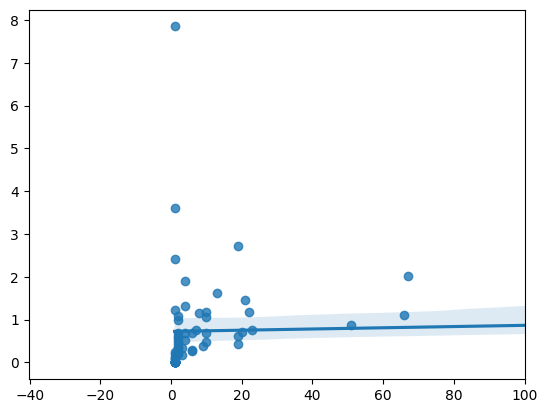

(-7.85, 500.0)

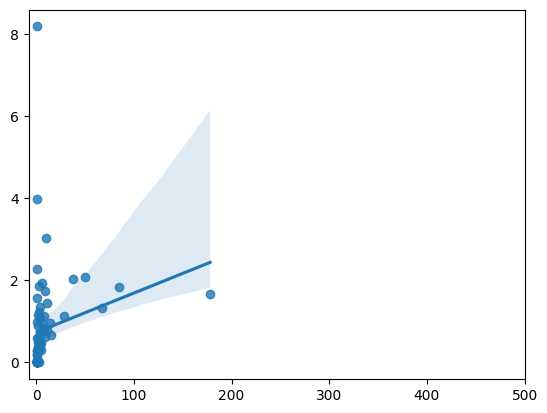

In [128]:
domain = "Bacteria"
temp_df = comparison_df_var.filter(pl.col("domain") == domain)
sns.regplot(data=temp_df,
            x="num_genera",
            y="variance_difference",
           )

ax = plt.gca()
ax.set_xlim(xmax=100)
plt.show()
sns.regplot(data=temp_df,
            x="num_families",
            y="var_mean_density_IR",
           )
ax = plt.gca()
ax.set_xlim(xmax=500)

In [102]:
total_accessions = comparison_df_general.group_by("domain").agg(total_accessions=pl.count())
total_accessions

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_16976/757593516.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  total_accessions = comparison_df_general.group_by("domain").agg(total_accessions=pl.count())


domain,total_accessions
str,u32
"""Eukaryota""",487
"""Viruses""",67654
"""Archaea""",687
"""Bacteria""",49190


In [ ]:
# from scipy.stats import combine_pvalues
# from collections import defaultdict 
# from statsmodels.stats.multitest import multipletests

# epsilon = 1e-300
# species_taxids = comparison_df_general["species_taxid"].unique()
# combined_pvalues = defaultdict(list)
# species_to_domain = dict(zip(comparison_df_general["species_taxid"].to_list(), 
#                              comparison_df_general["domain"].to_list()))
# for species_taxid in tqdm(species_taxids):
#     pvalues_list = comparison_df_general.filter(pl.col("species_taxid") == species_taxid)["pvalue"].to_list()
#     pvalues_list = [pval + epsilon for pval in pvalues_list]
#     if len(pvalues_list) > 1:
#         stat, p_combined = combine_pvalues(pvalues_list, method='fisher')
#     else:
#         stat, p_combined = 0, pvalues_list[0]
#     domain = species_to_domain[species_taxid]
#     combined_pvalues["species_taxid"].append(species_taxid)
#     combined_pvalues["domain"].append(domain)
#     combined_pvalues["stat"].append(stat)
#     combined_pvalues["combined_pvalue"].append(p_combined)
    
# combined_pvalues = pl.from_pandas(pd.DataFrame(combined_pvalues))
# pvalues = combined_pvalues["combined_pvalue"].to_list()
# _, pvals_corrected, _, _ = multipletests(pvalues, 
#                                          alpha=0.05, 
#                                          method='fdr_bh')
# # Add corrected p-values to the DataFrame
# combined_pvalues = combined_pvalues.with_columns(
#     pl.Series("adj_combined_pvalue", pvals_corrected)
# )

# def calculate_enrichment(o: int, e: int) -> float:
#     if o == e:
#         return 0
#     return (o-e)/(o+e)

# combined_pvalues = combined_pvalues.with_columns(
#     combined_significant=pl.col("adj_combined_pvalue").map_elements(evaluate_significance, return_dtype=str),
#     combined_reduced_significant=pl.col("adj_combined_pvalue").map_elements(evaluate_reduced_significance, return_dtype=str)
#         )\
#             .join(
#                 comparison_df_general.group_by("species_taxid", maintain_order=True)
#                                         .agg(
#                                             pl.col("fold_enrichment").mean(),
#                                             pl.col("total_bp").sum(),
#                                             pl.col("total_bp_control").sum(),
#                                             pl.col("genome_size").mean(),
#                                             pl.col("phylum").first(),
#                                             pl.col("organism_name").first(),
#                                             pl.col("kingdom").first(),
#                                             pl.col("domain").first()
#                                         ),
#                                         on="species_taxid",
#                                         how="left"
#             )\
#         .with_columns(
#             fe=pl.struct(["total_bp", "total_bp_control"])
#             .map_elements(lambda row: calculate_enrichment(row["total_bp"], row["total_bp_control"]), return_dtype=pl.Float32)
#         )
# print(combined_pvalues["domain"].unique())
# print(combined_pvalues["species_taxid"].n_unique())
# combined_pvalues

In [21]:
comparison_df_general.filter(pl.col("partition") == ".", 
                      pl.col("domain") == "Bacteria").select(["#assembly_accession", 
                                                            "species_taxid", 
                                                            "pvalue", 
                                                            "genome_size",
                                                            "total_bp",
                                                            "total_bp_control",
                                                            "organism_name",
                                                            "fold_enrichment",
                                                            "domain",
                                                            "odds"])\
                        .sort(["fold_enrichment"],
                              descending=True).to_pandas().head(20)

,#assembly_accession,species_taxid,pvalue,genome_size,total_bp,total_bp_control,organism_name,fold_enrichment,domain,odds
0,GCA_033095925.1,511900,1.904777e-22,12443,73,0,Acidovorax sp. SUPP2522,1.0,Bacteria,inf
1,GCA_000831425.1,573658,7.229187e-173,140570,572,0,Candidatus Hodgkinia cicadicola,1.0,Bacteria,inf
2,GCA_037127495.1,32046,1.449295e-30,29200,100,0,Synechococcus elongatus PCC 11802,1.0,Bacteria,inf
3,GCA_002846115.1,573658,2.690315e-143,133249,474,0,Candidatus Hodgkinia cicadicola,1.0,Bacteria,inf
4,GCA_002776675.1,573658,5.457620e-67,145143,221,0,Candidatus Hodgkinia cicadicola,1.0,Bacteria,inf
5,GCA_023066315.1,588,3.185218e-157,111974,520,0,Providencia stuartii,1.0,Bacteria,inf
6,GCA_900164315.1,1639,2.182320e-16,39808,53,0,Listeria monocytogenes,1.0,Bacteria,inf
7,GCA_900143735.1,562,1.190208e-07,87241,24,0,Escherichia coli,1.0,Bacteria,inf
8,GCA_900095035.1,1744,4.811778e-26,24909,85,0,Propionibacterium freudenreichii,1.0,Bacteria,inf
9,GCA_900164035.1,1639,2.298519e-24,4268,79,0,Listeria monocytogenes,1.0,Bacteria,inf


In [129]:
from scipy.stats import mannwhitneyu, ttest_ind

fe_enrichment = (
                comparison_df
                    .filter(pl.col('partition') == '.')
                    .group_by("species_taxid").agg(
                        density=pl.col(f"density_{pattern}").mean(),
                        density_control=pl.col(f"density_{pattern}_control").mean(),
                        domain=pl.col("domain").first(),
                    )
                .with_columns(fe_enrichment=pl.col("density") / pl.col("density_control"))
)

print("Two-tailed t-test results for density comparison between normal and control per domain:")
domains = ["Eukaryota", "Viruses", "Bacteria", "Archaea"] 
for domain in domains:
    fe_enrichment_controls = fe_enrichment.filter(pl.col("domain") == domain)["density_control"]
    fe_enrichment_domain = fe_enrichment.filter(pl.col("domain") == domain)["density"]
    print(domain, ttest_ind(fe_enrichment_domain, fe_enrichment_controls, alternative='two-sided'))

print()
print("Two-tailed Mann-Whitney U test results for density comparison between normal and control per domain:")
for domain in domains:
    fe_enrichment_controls = fe_enrichment.filter(pl.col("domain") == domain)["density_control"]
    fe_enrichment_domain = fe_enrichment.filter(pl.col("domain") == domain)["density"]
    print(domain, mannwhitneyu(fe_enrichment_domain, fe_enrichment_controls, alternative='two-sided'))

Two-tailed t-test results for density comparison between normal and control per domain:
Eukaryota TtestResult(statistic=np.float64(6.0631453062078045), pvalue=np.float64(2.411288204334615e-09), df=np.float64(578.0))
Viruses TtestResult(statistic=np.float64(58.852781565503584), pvalue=np.float64(0.0), df=np.float64(64210.0))
Bacteria TtestResult(statistic=np.float64(137.48308558958158), pvalue=np.float64(0.0), df=np.float64(22234.0))
Archaea TtestResult(statistic=np.float64(13.561345089821062), pvalue=np.float64(9.81700733013458e-39), df=np.float64(1054.0))

Two-tailed Mann-Whitney U test results for density comparison between normal and control per domain:
Eukaryota MannwhitneyuResult(statistic=np.float64(67304.0), pvalue=np.float64(6.189008444235306e-36))
Viruses MannwhitneyuResult(statistic=np.float64(690444677.0), pvalue=np.float64(0.0))
Bacteria MannwhitneyuResult(statistic=np.float64(121486595.0), pvalue=np.float64(0.0))
Archaea MannwhitneyuResult(statistic=np.float64(217684.0), p

In [23]:
pattern = "IR" 
comparison_df_avg = (
    comparison_df_general
            .group_by(["species_taxid", "partition"], maintain_order=True)
            .agg(
                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col("organism_name").first().alias("organism_name"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("genome_size").mean().alias("genome_size"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col("total_bp").sum().alias("total_bp"),
                                    pl.col("total_bp_control").sum().alias("total_bp_control"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )
    ).with_columns(
        difference=pl.col(f"density_{pattern}") - pl.col(f"density_{pattern}_control")
    )
comparison_df_avg.head()

species_taxid,partition,fold_enrichment,domain,organism_name,kingdom,genome_size,phylum,total_bp,total_bp_control,density_IR,density_IR_control,difference
i64,str,f64,str,str,str,f64,str,i64,i64,f64,f64,f64
28875,""".""",0.389097,"""Viruses""","""Human rotavirus A""","""Orthornavirae""",17040.162228,"""Duplornaviricota""",56295,21682,1.275281,0.507538,0.767743
2928988,""".""",0.0,"""Viruses""","""Wenzhou Rattus losea jeilongvi…","""Orthornavirae""",18077.0,"""Negarnaviricota""",0,0,0.0,0.0,0.0
813,""".""",0.818375,"""Bacteria""","""Chlamydia trachomatis RC-J/943""","""Pseudomonadati""",1.0567e6,"""Chlamydiota""",681709,68617,2.601637,0.261895,2.339742
562,""".""",0.848726,"""Bacteria""","""Escherichia coli""","""Pseudomonadati""",5.1426e6,"""Pseudomonadota""",60525539,4944952,2.712266,0.221512,2.490755
12305,""".""",-0.016064,"""Viruses""","""Cucumber mosaic virus""","""Orthornavirae""",5974.208835,"""Kitrinoviricota""",139,243,0.064839,0.195124,-0.130285


In [24]:
from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource
from bokeh.io import export_svg
from scipy.stats import gaussian_kde
import numpy as np
from pathlib import Path
from selenium import webdriver
from selenium.webdriver.firefox.service import Service
from selenium.webdriver.firefox.options import Options

# Create options for headless
options = Options()
options.add_argument("--headless")

# Point to the Firefox binary in your environment if needed
service = Service("/Users/nikolchantzi/.local/share/mamba/envs/biolab/bin/geckodriver")

# Create the driver
driver = webdriver.Firefox(service=service, options=options)

In [ ]:
from bokeh.models import ColumnDataSource, Whisker, LabelSet
from bokeh.plotting import figure, show
from bokeh.transform import jitter, dodge
import pandas as pd
from bokeh.io import export_svg
import numpy as np
from scipy.stats import mannwhitneyu
from pathlib import Path

# ## # ##
domains = ["Bacteria", "Archaea", "Eukaryota", "Viruses"]
expected_color = "#e84d60"
observed_color = "#3c4cba"

hedges_g_list = dict()
mw_test = dict()
cles_dict = dict()

def map_stars(pval):
    if pval < 0.0001:
        return "*" * 4
    elif pval < 0.001:
        return "*" * 3
    elif pval < 0.01:
        return "*" * 2
    elif pval < 0.05:
        return "*"
    return ""

for domain in domains:
    obs = comparison_df_avg.filter(
        (pl.col("partition") == ".") & (pl.col("domain") == domain)
    )[f"density_{pattern}"].to_pandas()

    ctrl = comparison_df_avg.filter(
        (pl.col("partition") == ".") & (pl.col("domain") == domain)
    )[f"density_{pattern}_control"].to_pandas()

    n1, n2 = len(obs), len(ctrl)

    mw = mannwhitneyu(obs, ctrl, alternative="two-sided")
    mw_test[domain] = (mw.statistic, mw.pvalue)

    cles = mw.statistic / (n1 * n2) if n1 > 0 and n2 > 0 else np.nan
    cles_dict[domain] = 2 * cles - 1

    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)
    pooled_denom = (n1 - 1) + (n2 - 1)

    if pooled_denom > 0:
        s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / pooled_denom)
    else:
        s_pooled = np.nan

    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled if s_pooled and not np.isnan(s_pooled) else np.nan
    df = n1 + n2 - 2
    J = 1.0 - (3.0 / (4.0 * df - 1.0)) if df > 0 else 1.0
    g = d * J if not np.isnan(d) else np.nan

    hedges_g_list[domain] = g


# ------------------ Plot ------------------
p = figure(
    height=500,
    width=800,
    x_range=domains,
    title="",
    output_backend="svg",
    toolbar_location=None
)
p.xgrid.grid_line_color = None

alpha = 0.025
quantiles_df = comparison_df_avg.filter(pl.col("partition") == ".") \
    .group_by("domain").agg(
        pl.col(f"density_{pattern}").quantile(alpha/2).alias("lower_ci"),
        pl.col(f"density_{pattern}").quantile(1-alpha/2).alias("upper_ci"),
        pl.col(f"density_{pattern}_control").quantile(alpha/2).alias("lower_ci_control"),
        pl.col(f"density_{pattern}_control").quantile(1-alpha/2).alias("upper_ci_control")
    )

source_scatter = ColumnDataSource(comparison_df_avg.filter(pl.col("partition") == "."))
source_whisker = ColumnDataSource(quantiles_df)

opacity = 0.06

p.scatter(
    jitter("domain", width=0.2, range=p.x_range, mean=-0.15),
    f"density_{pattern}",
    source=source_scatter,
    alpha=opacity,
    size=13,
    line_color="white",
    color=observed_color
)

p.scatter(
    jitter("domain", width=0.2, range=p.x_range, mean=0.15),
    f"density_{pattern}_control",
    source=source_scatter,
    alpha=opacity,
    size=13,
    line_color="white",
    color=expected_color
)

# Whiskers
error_obs = Whisker(
    base=dodge("domain", -0.15, range=p.x_range),
    upper="upper_ci",
    lower="lower_ci",
    source=source_whisker,
    level="annotation",
    line_width=3
)
error_obs.upper_head.size = 30
error_obs.lower_head.size = 30
p.add_layout(error_obs)

error_exp = Whisker(
    base=dodge("domain", 0.15, range=p.x_range),
    upper="upper_ci_control",
    lower="lower_ci_control",
    source=source_whisker,
    level="annotation",
    line_width=3
)
error_exp.upper_head.size = 30
error_exp.lower_head.size = 30
p.add_layout(error_exp)

p.y_range.end = 55
upper_ci = quantiles_df.to_pandas().set_index("domain")["upper_ci"].to_dict()
annot_df = pd.DataFrame({
    "domain": domains,
    "text": [
        f"g = {hedges_g_list[d]:.2f}\nδ = {cles_dict[d]:.2f}"
        for d in domains
    ],
    "y": [upper_ci[d] * l for d, l in zip(domains, [1.8, 2.0, 1.6, 1.4])]
})

labels = LabelSet(
    x="domain",
    y="y",
    text="text",
    source=ColumnDataSource(annot_df),
    text_font_size="22pt",
    background_fill_color="white",
    background_fill_alpha=0.2,
    text_align="center",
    x_offset=10
)
p.add_layout(labels)
star_df = pd.DataFrame({
    "domain": domains,
    "text": [map_stars(mw_test[d][1]) for d in domains],
    "y": [upper_ci[d] * 1.05 for d in domains]
})

p.add_layout(LabelSet(
    x="domain",
    y="y",
    text="text",
    source=ColumnDataSource(star_df),
    text_font_size="22pt",
    background_fill_color="white",
    background_fill_alpha=0.2,
    text_align="center",
    x_offset=4
))

p.title.text_font_size = "2pt"
p.title.text_font_style = "normal"
p.title.align = "center"

p.yaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_size = "24pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_size = "26pt"
p.yaxis.axis_label_text_font_style = "normal"

p.xaxis.major_label_text_font_size = "26pt"
p.xaxis.major_label_text_font_style = "normal"
p.yaxis.major_label_text_font_size = "24pt"
p.yaxis.major_label_text_font_style = "normal"

# Export
target = Path(f"{pattern}_figures/simulation").resolve()
export_svg(p, filename=target / f"{pattern}_density_vs_control_comparison_g_CL_MW.svg", webdriver=driver)
show(p)

In [28]:
domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                 'Archaea': '#b2b2ff',
                     'Bacteria': '#0fbf2d',
                }
kingdom_color_palette = {
                     'Viruses':'#229ad6',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Metazoa': '#9bba2d',
                     'Protista': '#c78f5b',
                     'Thermoproteati': '#380e8c',
                      'Promethearchaeati': '#672fd6',
                      'Nanobdellati': '#8154eb',
                      'Methanobacteriati': '#1fc46a',
                      'Fusobacteriati': '#94cc2d',
                      'Pseudomonadati': '#b2d8b2',
                      'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'
                     }

In [ ]:
plots = []
domains = ["Archaea", "Eukaryota", "Bacteria", "Viruses"]
for i, sk in enumerate(domains):
    data = (
            comparison_df_avg
                .filter(pl.col("partition") == ".")\
                .filter(pl.col('domain') == sk)['fold_enrichment'].to_numpy()
    )
    # KDE
    kde = gaussian_kde(data)
    x_kde = np.linspace(min(data), max(data), 500)
    dx = x_kde[1] - x_kde[0]
    y_kde = kde(x_kde) #  * 1e2 * dx * len(x_kde)

    # Histogram as frequencies
    hist, edges = np.histogram(data, bins=35, density=True)
    # hist = hist / hist.sum() * 100  # Convert to percentage
    bin_width = edges[1] - edges[0]
    # y_kde_percent = y_kde * 100 * bin_width 

    p = figure(
        width=600, 
        height=420, 
        title=sk,
        border_fill_color=None,
        toolbar_location=None,
        output_backend="svg",
    )
    p.quad(
        top=hist, 
        bottom=0, 
        left=edges[:-1], 
        right=edges[1:],
        fill_color=domain_colors.get(sk, "gray"), 
        line_color="black", 
        alpha=0.6
    )

    p.line(x_kde, 
           y_kde, 
           line_color=domain_colors.get(sk, "gray"), 
           line_width=3, 
           alpha=1.0,
    )

    p.line(x=[0.0, 0.0], 
           y=[0, max(max(hist), max(y_kde))],
           line_color="black", line_dash="dashed", line_width=5)

    if i == 0 or i == 2:
        p.yaxis.axis_label="Probability Density"
    else:
        p.yaxis.axis_label = ' ' 
    
    if i == 2 or i == 3:
        p.xaxis.axis_label = r"$$\text{IR Enrichment} \left(\frac{{O-E}}{{O+E}}\right)$$"

    else:
        p.xaxis.axis_label = ' '
    
    p.title.text_font_size = "28pt"
    p.title.align = "center"
    p.xaxis.axis_label_text_font_size = "19pt"
    p.yaxis.axis_label_text_font_size = "25pt"
    p.xaxis.major_label_text_font_size = "24pt"
    p.yaxis.major_label_text_font_size = "24pt"
    p.outline_line_color = "black"
    p.y_range.start = 0
    p.outline_line_width = 2
    p.x_range.start = -1 
    p.x_range.end = 1
    p.title.text_font_style = "normal"
    p.xaxis.axis_label_text_font_style = "normal"
    p.yaxis.axis_label_text_font_style = "normal"
    plots.append(p)

# # # #
grid = gridplot([plots[:2], plots[2:]], toolbar_location=None)
show(grid)
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
from bokeh.io import export_svg
export_svg(grid, 
           filename=target / f"histplot_enrichment_{pattern}_shuffled.svg", 
           webdriver=driver)

['/Users/nikolchantzi/biolab/tree_of_life_IR/notebooks/IR_figures/simulation/histplot_enrichment_IR_shuffled.svg']

## Kingdom Level Comparison

In [29]:
from scipy import stats 
import numpy as np 
from seaborn.algorithms import bootstrap
from seaborn.utils import ci
import pandas as pd 
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from scipy.stats import ttest_ind, t, chi2_contingency
from statsmodels.stats.multitest import multipletests
import polars as pl

In [30]:
#
# def ci95(series):
#     n = len(series)
#     mean = series.mean()
#     std = series.std(ddof=1)
#     t = stats.t.ppf(0.975, n - 1)
#     return t * (std / np.sqrt(n))

def seaborn_ci(series) -> pd.Series:
    boot_means = bootstrap(series, 
                           func=np.mean, 
                           n_boot=1000, 
                           seed=42)
    ci_bounds = ci(boot_means, 95)
    lower_ci, upper_ci = ci_bounds
    return pd.Series({"lower_ci": lower_ci,
                       "upper_ci": upper_ci})

def calculate_average_density(df, on, value):
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()
    grouped = df.groupby(on)[value]
    mean = grouped.mean().reset_index(name='mean')
    ci_intervals = grouped.apply(seaborn_ci).reset_index()
    avg_value = pd.merge(mean, 
                     ci_intervals.query("level_1=='upper_ci'"), 
                     on=on, 
                     how='left')\
                    .merge(ci_intervals.query("level_1=='lower_ci'"), 
                           on=on,
                           how='left')\
                    .rename(columns={
                                     f'{value}_x': 'upper_ci', 
                                     f'{value}_y': 'lower_ci'
                                     })\
                    .drop(columns=["level_1_x", "level_1_y"])\
                    .sort_values('mean', ascending=False)
    return avg_value

comparison_df_all = (
                    comparison_df_avg
                            .filter(pl.col("partition") == ".")\
                            .group_by("species_taxid")
                            .agg(
                                pl.col("domain").first().alias("domain"),
                                pl.col("kingdom").first().alias("kingdom"),
                                pl.col("phylum").first().alias("phylum"),
                                pl.col("total_bp").sum().alias("total_bp"),
                                pl.col("total_bp_control").sum().alias("total_bp_control"),
                                pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                        )
                )
avg_value = calculate_average_density(comparison_df_all, on="domain", value=f"density_{pattern}")
avg_value_control = calculate_average_density(comparison_df_all, on="domain", value=f"density_{pattern}_control")
avg_value = avg_value.merge(
    avg_value_control,
    how="left",
    on="domain",
    suffixes=("", "_control")
)
avg_value

,domain,mean,upper_ci,lower_ci,mean_control,upper_ci_control,lower_ci_control
0,Bacteria,3.142677,3.179355,3.107139,0.546031,0.557130,0.535406
1,Viruses,1.932170,1.989109,1.877714,0.297297,0.306095,0.289145
2,Eukaryota,1.912058,2.370026,1.525490,0.555385,0.659223,0.474976
3,Archaea,1.230677,1.333825,1.140767,0.536466,0.566354,0.508994


## Phylum Level Comparison

In [31]:
mean_density_phyla = (
                    comparison_df.group_by("species_taxid")\
                        .agg(
                            pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                            pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                            pl.col("domain").first().alias("domain"),
                            pl.col("kingdom").first().alias("kingdom"),
                            pl.col("phylum").first().alias("phylum"),
                        ).filter(~pl.col("phylum").is_null())
                        .group_by("phylum", maintain_order=False)
                        .agg(
                            mean_coverage=pl.col(f"density_{pattern}").mean(),
                            domain=pl.col("domain").first(),
                            total_species=pl.col("domain").count(),
                            kingdom=pl.col("kingdom").first(),
                        )
                    .sort(by=["mean_coverage"], descending=True)
)

target = Path(f"{pattern}_figures/simulation").resolve()
mean_density_phyla = mean_density_phyla.to_pandas()
mean_density_phyla.to_csv(f"{target}/{pattern}_mean_coverage_vs_controls_phylum_level.csv")

top_phyla = set(mean_density_phyla.iloc[:mean_density_phyla.shape[0]//2]['phylum'])
bottom_phyla = set(mean_density_phyla.iloc[mean_density_phyla.shape[0]//2:]['phylum'])
len(top_phyla), len(bottom_phyla), mean_density_phyla.shape[0]
mean_density_phyla.head(40)

,phylum,mean_coverage,domain,total_species,kingdom
0,Candidatus Campbelliibacteriota,2.399050,Bacteria,2,None
1,Candidatus Kaiseribacteriota,1.952350,Bacteria,1,None
2,Candidatus Wolfeibacteriota,1.735200,Bacteria,1,None
3,Arthropoda,1.632143,Eukaryota,7,Metazoa
4,Candidatus Altimarinota,1.510067,Bacteria,3,None
5,Apicomplexa,1.387138,Eukaryota,10,Protista
6,Mycoplasmatota,1.325605,Bacteria,198,Bacillati
7,Candidatus Uhriibacteriota,1.156600,Bacteria,1,None
8,Nucleocytoviricota,1.152685,Viruses,193,Bamfordvirae
9,Streptophyta,1.078874,Eukaryota,26,Plantae


In [32]:
effect_size_list = dict()
t_test_phyla = dict()
phylum_stat_assessed = defaultdict(list)
phyla = list(comparison_df_all.filter(~pl.col("phylum").is_null())["phylum"].unique())
phylum_to_domain = dict(zip(comparison_df_all["phylum"], comparison_df_all["domain"]))

# # # #
from scipy.stats import mannwhitneyu

def cles_from_mwu(obs, ctrl):
    U, _ = mannwhitneyu(obs, ctrl, alternative="two-sided")
    return U / (len(obs) * len(ctrl))


def bootstrap_cles_mwu(obs, ctrl, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    obs = np.asarray(obs)
    ctrl = np.asarray(ctrl)

    boot = np.empty(n_boot)
    cles = cles_from_mwu(obs, ctrl)
    for i in range(n_boot):
        obs_b = rng.choice(obs, size=len(obs), replace=True)
        ctrl_b = rng.choice(ctrl, size=len(ctrl), replace=True)
        U, _ = mannwhitneyu(obs_b, ctrl_b, alternative="two-sided")
        boot[i] = U / (len(obs_b) * len(ctrl_b))

    return (
        cles,
        np.percentile(boot, 2.5),
        np.percentile(boot, 97.5),
    )


for phylum in phyla:
    obs = comparison_df_all.filter(pl.col("phylum") == phylum)
    ctrl = comparison_df_all.filter(pl.col("phylum") == phylum)
    assert len(obs) == len(ctrl)
    if len(obs) < 5:
        print(f"Skipping {phylum} with n={len(obs)}.")
        continue
    
    # Per Species within Phylum Comparison
    obs = obs[f"density_{pattern}"].to_pandas()
    ctrl = ctrl[f"density_{pattern}_control"].to_pandas()
    
    t_res = mannwhitneyu(obs, ctrl, alternative="two-sided")
    t_stat, p_val = t_res.statistic, t_res.pvalue
    t_test_phyla[phylum] = (t_stat, p_val)
    # Hedges' g calculation
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    g = (np.mean(obs) - np.mean(ctrl)) / s_pooled
    correction = 1 - (3 / (4*(n1+n2)-9))
    g_corrected = g * correction
    effect_size_list[phylum] = g_corrected
    


    # df_num = (s1**2/n1 + s2**2/n2)**2
    # df_denom = ((s1**2/n1)**2)/(n1-1) + ((s2**2/n2)**2)/(n2-1)
    # df = df_num / df_denom
    # se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
    # ci_low = (np.mean(obs) - np.mean(ctrl)) - t.ppf(0.975, df) * se_diff
    # ci_high = (np.mean(obs) - np.mean(ctrl)) + t.ppf(0.975, df) * se_diff

    # Common Language Effect Size with Bootstrap CI
    cles, ci_low, ci_high = bootstrap_cles_mwu(obs, ctrl, n_boot=1000)
    phylum_stat_assessed["phylum"].append(phylum)
    phylum_stat_assessed["n_obs"].append(n1)
    phylum_stat_assessed["n_ctrl"].append(n2)
    phylum_stat_assessed["mean_obs"].append(np.mean(obs))
    phylum_stat_assessed["mean_ctrl"].append(np.mean(ctrl))
    phylum_stat_assessed["std_obs"].append(s1)
    phylum_stat_assessed["std_ctrl"].append(s2)
    phylum_stat_assessed["hedges_g"].append(g_corrected)
    phylum_stat_assessed["t_statistic"].append(t_stat)
    phylum_stat_assessed["pvalue"].append(p_val)
    phylum_stat_assessed["cles"].append(cles)
    phylum_stat_assessed["ci_lower"].append(ci_low)
    phylum_stat_assessed["ci_higher"].append(ci_high)


# Adjustment for multiple hypothesis Testing using Benjamini-Hochberg procedure
pvals = np.array(phylum_stat_assessed["pvalue"])
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
phylum_stat_assessed["pvalue_adj"] = pvals_fdr
phylum_stat_assessed["significant"] = reject

phylum_stat_assessed = pd.DataFrame(phylum_stat_assessed).merge(
    mean_density_phyla[["phylum", "domain", "kingdom", "total_species"]],
    how="left",
    on="phylum"
).sort_values(by=["hedges_g", "cles"], ascending=False)
phylum_stat_assessed.to_csv(f"{target}/{pattern}_phylum_statistical_assessment.csv", index=False, mode="w")
print(len(effect_size_list))
phylum_stat_assessed.dropna(subset=["phylum"], inplace=True)
phylum_stat_assessed.head(40)

Skipping Chrysiogenota with n=1.
Skipping Candidatus Delongiibacteriota with n=1.
Skipping Candidatus Binatota with n=2.
Skipping Candidatus Beckwithiibacteriota with n=1.
Skipping Candidatus Zixiibacteriota with n=1.
Skipping Candidatus Kaiseribacteriota with n=1.
Skipping Candidatus Falkowiibacteriota with n=1.
Skipping Candidatus Berkelbacteria with n=1.
Skipping Candidatus Auribacterota with n=1.
Skipping Coprothermobacterota with n=1.
Skipping Abditibacteriota with n=1.
Skipping Thermosulfidibacterota with n=1.
Skipping Candidatus Tectimicrobiota with n=1.
Skipping Fibrobacterota with n=2.
Skipping Dictyoglomota with n=2.
Skipping Candidatus Cloacimonadota with n=4.
Skipping Candidatus Kapaibacteriota with n=1.
Skipping Heterolobosea with n=1.
Skipping Thermodesulfobiota with n=2.
Skipping Microsporidia with n=3.
Skipping Candidatus Melainabacteria with n=2.
Skipping Candidatus Altimarinota with n=3.
Skipping Candidatus Poribacteria with n=2.
Skipping Candidatus Micrarchaeota with

,phylum,n_obs,n_ctrl,mean_obs,mean_ctrl,std_obs,std_ctrl,hedges_g,t_statistic,pvalue,cles,ci_lower,ci_higher,pvalue_adj,significant,domain,kingdom,total_species
28,Chlorobiota,17,17,1.893176,0.296059,0.352588,0.204392,5.411186,289.0,7.026615e-07,1.000000,1.000000,1.000000,1.099035e-06,True,Bacteria,Pseudomonadati,17
22,Nitrospirota,20,20,1.305408,0.290538,0.284673,0.094970,4.687591,400.0,6.795615e-08,1.000000,1.000000,1.000000,1.184379e-07,True,Bacteria,Pseudomonadati,20
30,Chlamydiota,28,28,1.985666,0.333034,0.499522,0.090871,4.539040,784.0,1.404101e-10,1.000000,1.000000,1.000000,2.676568e-10,True,Bacteria,Pseudomonadati,28
31,Ignavibacteriota,7,7,1.970485,0.536000,0.402999,0.265260,3.936420,49.0,5.827506e-04,1.000000,1.000000,1.000000,7.563359e-04,True,Bacteria,Pseudomonadati,7
4,Synergistota,15,15,3.618267,0.332633,1.180655,0.108091,3.813286,225.0,3.383339e-06,1.000000,1.000000,1.000000,5.031264e-06,True,Bacteria,Thermotogati,15
1,Chloroflexota,42,42,2.550343,0.379771,0.899369,0.259896,3.248872,1756.0,5.521489e-15,0.995465,0.984680,1.000000,1.347243e-14,True,Bacteria,Bacillati,42
34,Bdellovibrionota,21,21,2.545592,0.408153,0.891170,0.306345,3.147184,435.0,7.312096e-08,0.986395,0.945578,1.000000,1.238994e-07,True,Bacteria,Pseudomonadati,21
17,Lentisphaerota,7,7,1.824886,0.385514,0.614144,0.215390,2.928074,49.0,2.140710e-03,1.000000,1.000000,1.000000,2.664965e-03,True,Bacteria,Pseudomonadati,7
10,Candidatus Saccharimonadota,21,21,2.146389,0.253437,0.895391,0.184306,2.873152,441.0,3.125400e-08,1.000000,1.000000,1.000000,5.607335e-08,True,Bacteria,None,21
43,Bacillota,1636,1636,3.896310,0.369371,1.756523,0.183800,2.823546,2675921.5,0.000000e+00,0.999785,0.999552,0.999943,0.000000e+00,True,Bacteria,Bacillati,1636


In [33]:
if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

phylum_stat_assessed = (
                phylum_stat_assessed
                    .filter(~pl.col("phylum").is_null())
                    .with_columns(kingdom_n=pl.struct(["kingdom", "domain"])
                    .map_elements(lambda x: "Viruses" if x["domain"] == "Viruses" else (x["kingdom"] if (x["kingdom"] and x["domain"] == "Eukaryota") else x["domain"]), return_dtype=pl.Utf8)
                )
)
phylum_to_kingdom_color = dict(zip(phylum_stat_assessed["phylum"], phylum_stat_assessed["kingdom_n"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
phylum_stat_assessed = phylum_stat_assessed.with_columns(
                            pl.col("kingdom_n").replace_strict(kingdom_color_palette).alias("kingdom_color")
                        )

In [34]:
phylum_stat_assessed_to_list = list(phylum_stat_assessed.sort(["hedges_g"], descending=True)["phylum"])
phylum_stat_assessed_to_list

['Chlorobiota',
 'Nitrospirota',
 'Chlamydiota',
 'Ignavibacteriota',
 'Synergistota',
 'Chloroflexota',
 'Bdellovibrionota',
 'Lentisphaerota',
 'Candidatus Saccharimonadota',
 'Bacillota',
 'Acidobacteriota',
 'Thermodesulfobacteriota',
 'Euglenozoa',
 'Streptophyta',
 'Actinomycetota',
 'Fusobacteriota',
 'Spirochaetota',
 'Deinococcota',
 'Planctomycetota',
 'Mycoplasmatota',
 'Deferribacterota',
 'Bacteroidota',
 'Campylobacterota',
 'Thermoplasmatota',
 'Rhodothermota',
 'Pseudomonadota',
 'Thermotogota',
 'Elusimicrobiota',
 'Chordata',
 'Armatimonadota',
 'Thermoproteota',
 'Chlorophyta',
 'Nucleocytoviricota',
 'Myxococcota',
 'Verrucomicrobiota',
 'Produgelaviricota',
 'Gemmatimonadota',
 'Phixviricota',
 'Cyanobacteriota',
 'Ascomycota',
 'Peploviricota',
 'Methanobacteriota',
 'Uroviricota',
 'Saleviricota',
 'Hofneiviricota',
 'Nitrososphaerota',
 'Lenarviricota',
 'Aquificota',
 'Cressdnaviricota',
 'Preplasmiviricota',
 'Basidiomycota',
 'Arthropoda',
 'Apicomplexa',
 'A

In [35]:
from bokeh.models import Whisker, LabelSet, Span

if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

phylum_stat_assessed = (
            phylum_stat_assessed
                    .with_columns(
                        # pl.struct(["ci_lower", "ci_higher"]).map_elements(lambda x: f"[{x['ci_lower']}, {x['ci_higher']}]", return_dtype=str).alias("representation")
                        pl.col("pvalue_adj").map_elements(map_stars, return_dtype=str).alias("representation")
                    )
                    .sort(["hedges_g"])
)

phylum_stat_assessed = phylum_stat_assessed.with_columns(
                                pl.when(pl.col("hedges_g") < 0.5)
                                .then(20)   # below the bar if hedges_g < 1
                                .otherwise(5)  # above the bar if hedges_g >= 1
                                .alias("label_y_offset")
                            )

phylum_stat_assessed = phylum_stat_assessed.with_columns(
                                    pl.when(pl.col("hedges_g") < 0.5)
                                    .then(0.5)                   # place at 1 if bar < 1
                                    .otherwise(pl.col("hedges_g"))  # otherwise at bar end
                                    .alias("label_x_pos")
                                )
source = ColumnDataSource(phylum_stat_assessed)
bar_fig = figure(
    y_range=list(phylum_stat_assessed['phylum']),
    height=2000,
    width=1200,
    output_backend="svg",
    toolbar_location=None,
    tools=""
)
bar_fig.border_fill_color = None
bar_fig.x_range.end = phylum_stat_assessed["hedges_g"].max() * 1.1

span = Span(location=0.5, 
            line_width=5, 
            line_dash='dashed', 
            line_color='black', 
            dimension='height')
bar_fig.add_layout(span)

bar_fig.hbar(
    y='phylum',
    right='hedges_g',
    height=0.7,
    line_color='black',
    line_width=1.8,
    color='kingdom_color',
    source=source
)

sig_labels = LabelSet(
    x='label_x_pos',
    y='phylum',
    text='representation',
    source=source,
    # x_offset='label_y_offset',
    x_offset=5,
    y_offset=-27,
    text_font_size="26pt",
    text_color="black",
    text_align="left",
)
bar_fig.add_layout(sig_labels)
bar_fig.ygrid.grid_line_color = None
bar_fig.xaxis.axis_label = "Effect Size (g)"
bar_fig.ygrid.grid_line_color = None
bar_fig.x_range.start = 0
bar_fig.yaxis.axis_label = ""
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "32pt"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.major_label_text_font_size = "26pt"
bar_fig.yaxis.major_label_text_font_size = "22pt"
bar_fig.title.text_font_size = '16pt'
bar_fig.title.align = 'center'

target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
export_svg(bar_fig, 
            filename=f"{target}/phylum_{pattern}_hedges_g_with_CI.svg", 
            webdriver=driver)
show(bar_fig)

In [36]:
comparison_df_all_phylum = comparison_df_all.filter(~pl.col("phylum").is_null())

In [37]:
valid_phylums = set(
                comparison_df_all_phylum
                    .group_by("phylum", maintain_order=True)
                    .agg(
                        total_species=pl.col('species_taxid').count()
                    )
                    .filter(pl.col("total_species") >= 20)
                    ["phylum"]
    )
len(valid_phylums)

45

In [38]:
comparison_df_all_phylum_valid = (
        comparison_df_all_phylum
                .filter(pl.col("phylum").is_in(valid_phylums))
)

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_49180/2917243217.py:8: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  temp_df = comparison_df_all_phylum_valid.filter(pl.col("phylum") == phylum).melt(id_vars=["phylum", "species_taxid"],
/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_49180/2917243217.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(prop={"size": 16})
/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_49180/2917243217.py:8: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  temp_df = comparison_df_all_phylum_valid.filter(pl.col("phylum") == phylum).melt(id_vars=["phylum", "species_taxid"],
/var/fol

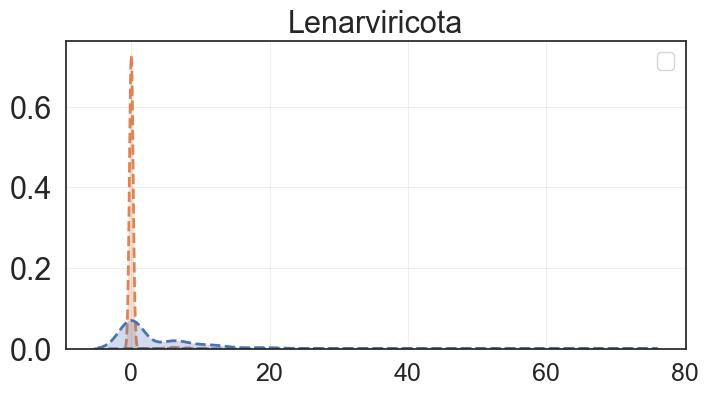

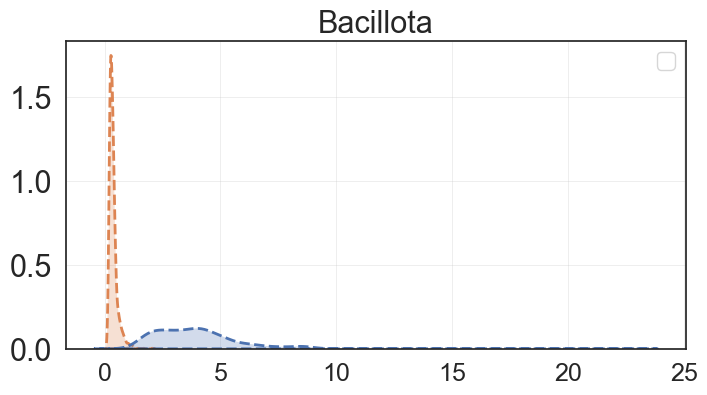

In [569]:
top = 100
valid_phylums_list = list(valid_phylums)
valid_phylums_list = ["Lenarviricota", "Bacillota"]

for phylum in valid_phylums_list[:top]:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))

    temp_df = comparison_df_all_phylum_valid.filter(pl.col("phylum") == phylum).melt(id_vars=["phylum", "species_taxid"],
                                                                                     value_vars=[f"density_{pattern}",
                                                                                                 f"density_{pattern}_control"],
                                                                                    value_name=f"density_{pattern}",
                                                                                    variable_name="group"
                                                                                                 )
    # print(temp_df.head())

    sns.kdeplot(data=temp_df, 
                x=f"density_{pattern}", 
                hue="group", 
                common_norm=True, 
                bw_adjust=1.0,
                fill=True, 
                lw=2.0, 
                linestyle='--')
    ax.grid(lw=0.4, alpha=0.6,)
    ax.tick_params(axis="y", labelsize=22)
    ax.tick_params(axis="x", labelsize=18)
    ax.set_title(phylum, fontsize=22)
    ax.legend(prop={"size": 16})
    ax.set_ylabel("")
    ax.set_xlabel("")

In [39]:
import colorcet as cc
from numpy import linspace
from scipy.stats import gaussian_kde
from bokeh.models import ColumnDataSource, FixedTicker, PrintfTickFormatter
from bokeh.plotting import figure, show
# from bokeh.sampledata.perceptions import probly

In [40]:
phylum_data = comparison_df_all_phylum_valid.filter(pl.col("phylum") == "Streptophyta")
phylum_data

species_taxid,domain,kingdom,phylum,total_bp,total_bp_control,density_IR,density_IR_control
i64,str,str,str,i64,i64,f64,f64
3847,"""Eukaryota""","""Plantae""","""Streptophyta""",12481464,1455474,6.168,0.7195
13708,"""Eukaryota""","""Plantae""","""Streptophyta""",209441,21678,0.337,0.035
3752,"""Eukaryota""","""Plantae""","""Streptophyta""",4822815,479971,3.924,0.3905
85571,"""Eukaryota""","""Plantae""","""Streptophyta""",1210916,207023,3.994,0.683
106567,"""Eukaryota""","""Plantae""","""Streptophyta""",4816454,500385,3.805,0.3955
…,…,…,…,…,…,…,…
4641,"""Eukaryota""","""Plantae""","""Streptophyta""",9209453,2099272,9.797,2.233
4558,"""Eukaryota""","""Plantae""","""Streptophyta""",4914089,420918,3.386,0.29
91218,"""Eukaryota""","""Plantae""","""Streptophyta""",3142092,282436,5.949,0.535


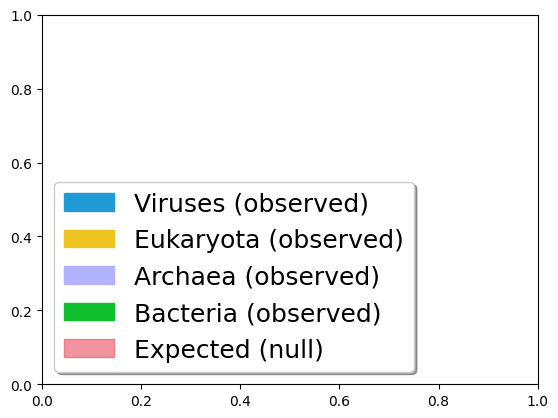

In [41]:
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches 


colors = {f"{c} (observed)": l for c, l in domain_colors.items()} | {"Expected (null)": "#E84D6099"}
f = lambda m,c: plt.plot([],[],marker=m, color=c, ls="none")[0]
handles = [mpatches.Patch(color=colors[c], label=c) for c in colors]
legend = plt.legend(handles=handles, loc=3, framealpha=1, frameon=True, shadow=True, fancybox=True, prop={"size": 18})

def export_legend(legend, filename="IR_figures/legend_domains_and_expected_ridge.pdf"):
    fig  = legend.figure
    fig.canvas.draw()
    bbox  = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(filename, dpi="figure", transparent=True, bbox_inches=bbox)

export_legend(legend)
plt.show()


In [42]:
import colorcet as cc
from numpy import linspace
from scipy.stats import gaussian_kde
from bokeh.models import ColumnDataSource, FixedTicker, PrintfTickFormatter
from bokeh.plotting import figure, show
from bokeh.sampledata.perceptions import probly

def ridge(category, data, scale=1.0):
    return list(zip([category]*len(data), scale*data))

cats = list(reversed(probly.keys()))

palette = [cc.rainbow[i*15] for i in range(17)]

x = linspace(-6, 18, 300)
source = ColumnDataSource(data=dict(x=x))
domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',                
            }

# phylums = [phylum for phylum in set(comparison_df_all_phylum_valid["phylum"]) if phylum in valid_phylums]
phylums = [phylum for phylum in list(phylum_stat_assessed_to_list)[::-1] if phylum in valid_phylums]
p = figure(y_range=phylums, width=1200, height=2100, x_range=(-0.99, 6.5), toolbar_location=None)

specific_phyla = {'Streptophyta', 'Nucleocytoviricota', 'Peploviricota', 'Cressdnaviricota', 'Lenarviricota'}

for i, cat in enumerate(phylums):
    phylum_data = comparison_df_all_phylum_valid.filter(pl.col("phylum") == cat)
    densities = phylum_data[f"density_{pattern}"].to_list()
    pdf = gaussian_kde(densities)

    if cat in specific_phyla:
        scale = 1.4
    else:
        scale = 0.8
    y = ridge(cat, pdf(x), scale=scale)
    # source.add(y, cat)
    source = ColumnDataSource(data=dict(x=x, y=y))
    p.patch('x', 'y', color=domain_colors[phylum_to_domain[cat]], alpha=0.6, line_color="black", source=source)

    # 
    densities_control = phylum_data[f"density_{pattern}_control"].to_list()
    pdf = gaussian_kde(densities_control)
    y = ridge(cat, pdf(x), scale=0.6)
    # source.add(y, cat)
    source = ColumnDataSource(data=dict(x=x, y=y))
    p.patch('x', 'y', color=expected_color, alpha=0.55, line_color="black", source=source)

p.outline_line_color = None
p.background_fill_color = "#ffffff"

# p.xaxis.ticker = FixedTicker(ticks=list(range(0, 101, 10)))
# p.xaxis.formatter = PrintfTickFormatter(format="%d%%")

p.ygrid.grid_line_color = None
p.xgrid.ticker = p.xaxis.ticker

p.axis.minor_tick_line_color = None
p.axis.major_tick_line_color = None
p.axis.axis_line_color = None
p.xgrid.ticker = p.xaxis.ticker
p.axis.minor_tick_line_color = None
p.axis.major_tick_line_color = None
p.axis.axis_line_color = None
p.yaxis.major_label_text_font_size = "26pt"
p.xaxis.major_label_text_font_size = "26pt"
p.xaxis.axis_label = f"{pattern} Density per kB"
p.xaxis.axis_label_text_font_size = "32pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"

# # # #
# p.ygrid.grid_line_color = None
# p.xgrid.grid_line_color = "#dddddd"
# p.xgrid.ticker = p.xaxis.ticker

# p.axis.minor_tick_line_color = None
# p.axis.major_tick_line_color = None
# p.axis.axis_line_color = None
# p.background_fill_color = "white"        
# p.outline_line_color = None             
# p.xgrid.grid_line_color = "#dddddd"     
p.ygrid.grid_line_color = None     

p.y_range.range_padding = 0.10
export_svg(p, filename=f"{target}/phylum_{pattern}_ridgeplot_density.svg", webdriver=driver)
show(p)

# Viral Host Analysis

In [43]:
import pandas as pd
viruses_df = pd.read_table("../../data/viruses.txt")
host_eukaryota = {'plants', 
                   'eukaryotic algae',
                   'invertebrates',
                   'fungi',
                  'land plants',
                  'human',
                  'protozoa',
                  'vertebrates'}

viruses = viruses_df.query("Host != '-'").copy()
viruses.loc[:, "hostRe"] = viruses["Host"].apply(lambda y: 'Eukaryota' if all(i.strip() in host_eukaryota for i in y.split(',')) else y.capitalize())
viruses = viruses[viruses['hostRe'].isin({'Bacteria', 'Archaea', 'Eukaryota'})]\
                .drop_duplicates(subset=["#Organism/Name"])\
                .reset_index(drop=True)

df_viral_accessions = (
    comparison_df
                            .filter(pl.col("domain") == "Viruses",pl.col("partition") == ".")
                            .group_by(["species_taxid"])
                            .join(
                                pl.from_pandas(viruses).select(["#Organism/Name", "hostRe"]).unique(["#Organism/Name", "hostRe"]),
                                left_on="organism_name", 
                                right_on="#Organism/Name", 
                                how="inner"
                            ).filter(~pl.col("hostRe").is_null())
)
df_viral_accessions

FileNotFoundError: [Errno 2] No such file or directory: '../../data/viruses.txt'

In [49]:
df_viral_accessions.group_by("hostRe").agg(pl.col("density_STR").mean()).sort("density_STR", descending=True)

NameError: name 'df_viral_accessions' is not defined

In [119]:
domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                 'Archaea': '#b2b2ff',
                 'Bacteria': '#8eb812'
                }

### Statistical Evaluation of STR enrichment in viral hosts

In [53]:
import itertools 
hosts = ["Eukaryota", "Bacteria", "Archaea"]
hosts_paired = [c for c in itertools.product(hosts, repeat=2)]

df_viral_species = df_viral_accessions.group_by("species_taxid").agg(pl.col("hostRe").first(), pl.col(f"density_{pattern}").mean())
for pair in hosts_paired:
    if pair[0] != pair[1]:
        STR_density_controls = df_viral_species.filter(pl.col("hostRe") == pair[0])[f"density_{pattern}"]
        STR_density_domain = df_viral_species.filter(pl.col("hostRe") == pair[1])[f"density_{pattern}"]
        print(pair, mannwhitneyu(STR_density_domain, STR_density_controls, alternative='two-sided'))

NameError: name 'df_viral_accessions' is not defined

In [ ]:
import pandas as pd
from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource
from bokeh.io import reset_output, output_notebook
from bokeh.resources import INLINE

reset_output()
# output_notebook(resources=INLINE)
############################################
from bokeh.io import export_svgs
from bokeh.models import ColumnDataSource, Whisker
from bokeh.plotting import figure, show
from bokeh.models import Legend, LegendItem

domain_colors = {
                 'Viruses': '#229ad6',
                 'Eukaryota': '#edc41f',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',                
            }

df = df_viral_accessions.group_by("species_taxid").agg(
    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
    pl.col("domain").first().alias("domain"),
    pl.col("hostRe").first().alias("hostRe"),
    pl.col("kingdom").first().alias("kingdom"),
    pl.col("phylum").first().alias("phylum"),
).to_pandas().copy()
group_col = "hostRe"
value_col = "fold_enrichment"
hosts = set(df["hostRe"])
cmap = {host: domain_colors[host] for host in hosts}
df.loc[:, "domain_color"] = df["hostRe"].map(cmap)

groups = sorted(df[group_col].dropna().unique())
qs = df.groupby(group_col)[value_col].quantile([0.25, 0.5, 0.75]).unstack().reset_index()
qs.columns = [group_col, "q1", "q2", "q3"]
df = df.merge(qs, on=group_col, how="left")

# Compute IQR whisker bounds
df["iqr"] = df["q3"] - df["q1"]
df["upper"] = df["q3"] + 1.5 * df["iqr"]
df["lower"] = df["q1"] - 1.5 * df["iqr"]

# Source for whiskers and boxes (aggregated)
box_stats = df[[group_col, "q1", "q2", "q3", "upper", "lower", "domain_color"]].drop_duplicates()
source = ColumnDataSource(box_stats)

# Outliers
outliers = df[~df[value_col].between(df["lower"], df["upper"])]
out_source = ColumnDataSource(outliers)

p = figure(x_range=["Eukaryota", "Archaea", "Bacteria"], 
           height=600, 
           width=900,
           title="",
           border_fill_color=None,
           output_backend="svg",
           y_axis_label="STR Enrichment")
whisker = Whisker(base=group_col, upper="upper", lower="lower", source=source)
whisker.upper_head.size = whisker.lower_head.size = 25
p.add_layout(whisker)

top_box = p.vbar(x=group_col, width=0.4, top="q3", bottom="q2", source=source, color="domain_color", line_color="black")
p.vbar(x=group_col, width=0.4, top="q2", bottom="q1", source=source, color="domain_color", line_color="black")

from bokeh.models import Span
hline = Span(location=0, dimension='width', line_color='black', line_width=2, line_dash='dashed')
p.add_layout(hline)

# legend = Legend(items=[
#   LegendItem(label=domain, renderers=[top_box], color=domain_colors[domain]) for domain in hosts
#])
# p.add_layout(legend, "right")

# Outlier dots
# p.scatter(x=group_col, y=value_col, source=out_source, size=6, color="black", alpha=0.3)
p.xgrid.grid_line_color = None
p.axis.major_label_text_font_size = "18pt"
p.axis.axis_label_text_font_size = "18pt"
p.title.text_font_size = "26pt"
p.title.align = "center"

p.y_range.end = 1.0
p.y_range.start = -1.0

p.xaxis.axis_label_text_font_size = "28pt"
p.yaxis.axis_label_text_font_size = "34pt"
p.xaxis.major_label_text_font_size = "32pt"
p.yaxis.major_label_text_font_size = "28pt"
p.title.text_font_style = "normal"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"

# Save SVGs
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True, parents=True)
show(p)
# export_svgs(p, filename=target / f"viral_host_enrichment_{pattern}.svg")


NameError: name 'df_viral_accessions' is not defined

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patches as mpatches
from statannotations.Annotator import Annotator
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['ps.fonttype'] = 42  

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 8))
df = df_viral_accessions.group_by("species_taxid").agg(
    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
    pl.col("domain").first().alias("domain"),
    pl.col("hostRe").first().alias("hostRe"),
    pl.col("kingdom").first().alias("kingdom"),
    pl.col("phylum").first().alias("phylum"),
).to_pandas().copy()
group_col = "hostRe"
value_col = "fold_enrichment"

hosts = set(df["hostRe"])
cmap = {host: domain_colors[host] for host in hosts}
df.loc[:, "domain_color"] = df["hostRe"].map(cmap)
order = ["Eukaryota", "Archaea", "Bacteria"]

sns.boxplot(data=df,
            x=group_col,
            y=value_col,
            palette=cmap,
            width=0.6,
            linewidth=1.5,
            # edgecolor="black",
            order=order,
            ax=ax,
            # saturation=0.8,
            # capsize=0.4,
            boxprops=dict(linewidth=2, edgecolor='black'),
            medianprops=dict(color='crimson', linewidth=3), 
            whiskerprops=dict(linewidth=2, color='gray'),
            capprops=dict(linewidth=2, color='black'),
            flierprops=dict(marker='o', color='orange', markersize=5)
           )
ax.grid(lw=1.0, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0, pad=2)
ax.set_xlabel('')
ax.set_ylabel("Enrichment")
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", labelsize=24)
ax.tick_params(axis="x", 
               labelsize=24, 
               zorder=0)
ax.legend(handles=[], frameon=False)
pairs=[("Eukaryota", "Archaea"), ("Archaea", "Bacteria"), ("Eukaryota", "Bacteria")]
annotator = Annotator(ax, 
                      pairs, 
                      data=df,
                      x=group_col,
                      y=value_col,
                      order=order
                     )
annotator.configure(test='t-test_ind',  
                    comparisons_correction="fdr_bh",
                    text_format='star',
                    fontsize=18,
                    text_offset=-0.05,
                    loc='inside')
annotator.apply_and_annotate()
ax.axhline(0, color='black', zorder=5, linestyle='--', linewidth=2)
target = Path(f"{pattern}_figures/simulation").resolve()
plt.tight_layout()
fig.savefig(f"{target}/fold_enrichment_{pattern}_viral_hosts.pdf", transparent=True, bbox_inches="tight")

ModuleNotFoundError: No module named 'statannotations'

### STR Contribution in IR Enrichment

In [131]:
valid_STR_accessions = set()
with open("STR_valid_accessions.txt") as f: 
    for line in f:
        valid_STR_accessions.add(extract_id(line))

valid_STR_accessions_shuffled = set()
with open("STR_valid_accessions_shuffled.txt") as f: 
    for line in f:
        valid_STR_accessions_shuffled.add(extract_id(line))

mutual_STR_accessions = valid_STR_accessions_shuffled.intersection(valid_STR_accessions)
len(mutual_STR_accessions)

117900

In [132]:

partition_col = "spacer_length"
effect_df = pl.read_csv("STR_effects/STR_effect_results/STR_effects_on_IR_normal.tsv",
                        has_header=False,
                        separator="\t",
                        new_columns=["#assembly_accession", "partition", f"total_bp_{pattern}", "total_STR_bp", "overlap_ratio"]
                        ) 
shuffled_effect_df = pl.read_csv("STR_effects/STR_effect_results_shuffled/STR_effects_on_IR_shuffled.tsv",
                        has_header=False,
                        separator="\t",
                        new_columns=["#assembly_accession", "partition", f"total_bp_{pattern}_control", "total_STR_bp_control", "overlap_ratio_control"]
)

effect_df = (
    effect_df
    .join(
        shuffled_effect_df,
        on=["#assembly_accession", "partition"],
        how="left"
    )
    .filter(
        pl.col("#assembly_accession").is_in(mutual_assemblies.intersection(mutual_STR_accessions))
    )
)   
effect_df

#assembly_accession,partition,total_bp_IR,total_STR_bp,overlap_ratio,total_bp_IR_control,total_STR_bp_control,overlap_ratio_control
str,str,i64,i64,f64,i64,i64,f64
"""GCF_000009305.1""","""0""",154,0,0.0,60,0,0.0
"""GCF_000009305.1""","""1""",198,0,0.0,132,0,0.0
"""GCF_000009305.1""","""2""",204,0,0.0,28,0,0.0
"""GCF_000009305.1""","""3""",308,0,0.0,92,0,0.0
"""GCF_000009305.1""","""4""",152,0,0.0,100,0,0.0
…,…,…,…,…,…,…,…
"""GCA_963681965.1""","""5""",1043,0,0.0,104,0,0.0
"""GCA_963681965.1""","""6""",1026,4,0.39,52,0,0.0
"""GCA_963681965.1""","""7""",571,0,0.0,191,0,0.0


In [133]:
effect_df.filter(pl.col("total_bp_IR") == 0, 
                 pl.col("partition") == "."
                 )["#assembly_accession"].shape

(32731,)

In [148]:
def calculate_enrichment(row):
    o, e = None, None
    for key, value in row.items():
        if "control" in key:
            e = value
        else:
            o = value
    if o == e:
        return 0.0
    return (o-e)/(o+e)

comparison_df_general = (
            comparison_df.filter(pl.col("partition") == ".")
                .select([
                        "#assembly_accession", 
                        "species_taxid", 
                        "partition",
                        "organism_name", 
                        "domain", 
                        "phylum",
                        "kingdom",
                        "genome_size",
                        f"density_{pattern}", 
                        f"density_{pattern}_control", 
                        "total_bp",
                        "total_bp_control",
                        "fold_enrichment", 
                        "pvalue", 
                        "significance"
                    ])
                .join(
                    effect_df
                        .filter(pl.col("partition") == ".")
                        .drop(["partition"]),
                    on="#assembly_accession",
                    how="left"
                )
                .with_columns(
                    (pl.col(f"total_bp_{pattern}") - pl.col("total_STR_bp")).alias(f"total_bp_{pattern}_nonSTR"),
                    (pl.col(f"total_bp_{pattern}_control") - pl.col("total_STR_bp_control")).alias(f"total_bp_{pattern}_control_nonSTR"),
                )
                .with_columns(
                    density_corrected=pl.col(f"total_bp_{pattern}_nonSTR") * 1e3 / pl.col("genome_size"),
                    density_control_corrected=pl.col(f"total_bp_{pattern}_control_nonSTR") * 1e3 / pl.col("genome_size"),
                )
                .with_columns(
                    enrichment=pl.struct([f"total_bp_{pattern}", f"total_bp_{pattern}_control"]).map_elements(calculate_enrichment, return_dtype=float),
                    enrichment_corrected=pl.struct([f"total_bp_{pattern}_nonSTR", f"total_bp_{pattern}_control_nonSTR"]).map_elements(calculate_enrichment, 
                                                                                                                                      return_dtype=float),
                )
)


a = comparison_df_general[f"total_bp_{pattern}_nonSTR"].to_list()
b = (comparison_df_general["genome_size"] - comparison_df_general[f"total_bp_{pattern}_nonSTR"]).to_list()
c = comparison_df_general[f"total_bp_{pattern}_control_nonSTR"].to_list()
d = (comparison_df_general["genome_size"] - comparison_df_general[f"total_bp_{pattern}_control_nonSTR"]).to_list()

def assess_significance(table):
    if np.sum(table) == 0:
        return (np.nan, 1.0)
    result = fisher_exact(table, alternative='two-sided')
    return (result.statistic, result.pvalue)

test_results = [assess_significance(np.array([[ai, bi], [ci, di]], dtype=np.float64)) for ai, bi, ci, di in zip(a,b,c,d)]
pvalues = [test_results[i][1] for i in range(len(test_results))]
odds = [test_results[i][0] for i in range(len(test_results))]
result_df = pl.DataFrame({"odds_no_STR": odds, 
                          "pvalue_no_STR": pvalues})
comparison_df_general = pl.concat([comparison_df_general, result_df], how="horizontal")
comparison_df_general = ( 
                comparison_df_general
                 .with_columns(
                    sig_no_STR=pl.col("pvalue_no_STR").map_elements(evaluate_significance, return_dtype=str),
                )
)

# Combined Probability Test per Species
from scipy.stats import combine_pvalues
from collections import defaultdict 
from statsmodels.stats.multitest import multipletests

epsilon = 1e-300
species_taxids = comparison_df_general["species_taxid"].unique()
combined_pvalues = defaultdict(list)
species_to_domain = dict(zip(comparison_df_general["species_taxid"].to_list(), 
                             comparison_df_general["domain"].to_list()))
##
for species_taxid in tqdm(species_taxids):
    pvalues_list = comparison_df_general.filter(pl.col("species_taxid") == species_taxid)["pvalue"].to_list()
    pvalues_list = [pval for pval in pvalues_list]
    if len(pvalues_list) > 1:
        stat, p_combined = combine_pvalues(pvalues_list, method='fisher')
    else:
        stat, p_combined = 0, pvalues_list[0]
    domain = species_to_domain[species_taxid]
    combined_pvalues["species_taxid"].append(species_taxid)
    combined_pvalues["domain"].append(domain)
    combined_pvalues["stat"].append(stat)
    combined_pvalues["combined_pvalue"].append(p_combined)
    
combined_pvalues = pl.from_pandas(pd.DataFrame(combined_pvalues))
pvalues = combined_pvalues["combined_pvalue"].to_list()
_, pvals_corrected, _, _ = multipletests(pvalues, 
                                         alpha=0.05, 
                                         method='fdr_bh')
# Add corrected p-values to the DataFrame
combined_pvalues = combined_pvalues.with_columns(
    pl.Series("adj_combined_pvalue", pvals_corrected)
)
combined_pvalues

/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_stats_py.py:5022: RuntimeWarning: invalid value encountered in cast
  c = np.asarray(table, dtype=np.int64)
  0%|          | 0/44042 [00:00<?, ?it/s]/Users/nikolchantzi/.local/share/mamba/envs/biolab/lib/python3.13/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)
100%|██████████| 44042/44042 [00:14<00:00, 2946.98it/s]


species_taxid,domain,stat,combined_pvalue,adj_combined_pvalue
i64,str,f64,f64,f64
7,"""Bacteria""",0.0,0.0,0.0
9,"""Bacteria""",inf,0.0,0.0
11,"""Bacteria""",0.0,0.0,0.0
14,"""Bacteria""",0.0,0.0,0.0
19,"""Bacteria""",0.0,0.0,0.0
…,…,…,…,…
3127874,"""Viruses""",0.0,2.1504e-48,6.7528e-48
3127946,"""Viruses""",0.0,1.0,1.0
3127947,"""Viruses""",0.0,1.0,1.0


In [149]:
comparison_df_general.filter(pl.col("pvalue") < 0.05, pl.col("pvalue_no_STR") >= 0.05)["domain"].value_counts()

domain,count
str,u32
"""Viruses""",278
"""Bacteria""",4
"""Eukaryota""",8
"""Archaea""",2


In [150]:
comparison_df_general.filter(pl.col("pvalue") < 0.05, pl.col("pvalue_no_STR") >= 0.05).filter(pl.col("domain") != "Viruses").to_pandas()

,#assembly_accession,species_taxid,partition,organism_name,domain,phylum,kingdom,genome_size,density_IR,density_IR_control,...,overlap_ratio_control,total_bp_IR_nonSTR,total_bp_IR_control_nonSTR,density_corrected,density_control_corrected,enrichment,enrichment_corrected,odds_no_STR,pvalue_no_STR,sig_no_STR
0,GCF_000092305.1,67760,.,Methanocaldococcus infernus ME,Archaea,Methanobacteriota,Methanobacteriati,1328194,0.817,0.896,...,0.42,1112,1185,0.837227,0.892189,-0.033884,-0.031781,0.938345,0.132838,ns
1,GCA_016495685.1,498019,.,[Candida] auris,Eukaryota,Ascomycota,Fungi,12100895,0.266,0.228,...,0.14,2653,2758,0.219240,0.227917,0.099446,-0.019405,0.961921,0.157362,ns
2,GCF_001190965.1,35746,.,Haloferax gibbonsii,Archaea,Methanobacteriota,Methanobacteriati,3918454,1.172,1.109,...,1.29,4466,4290,1.139735,1.094820,0.027632,0.020101,1.041072,0.061307,ns
3,GCA_019039655.1,498019,.,[Candida] auris,Eukaryota,Ascomycota,Fungi,12378757,0.236,0.196,...,0.00,2367,2427,0.191215,0.196062,0.125720,-0.012516,0.975273,0.394102,ns
4,GCA_036417295.1,1859122,.,Cryptococcus decagattii,Eukaryota,Basidiomycota,Fungi,17768546,0.303,0.228,...,0.22,3922,4039,0.220727,0.227312,0.196666,-0.014697,0.971026,0.193516,ns
5,GCA_900235035.2,460519,.,Komagataella phaffii CBS 7435,Eukaryota,Ascomycota,Fungi,9383226,0.290,0.274,...,0.00,2639,2567,0.281247,0.273573,0.037134,0.013830,1.028056,0.325036,ns
6,GCF_011074885.1,5007,.,Brettanomyces bruxellensis,Eukaryota,Ascomycota,Fungi,13150648,0.395,0.325,...,0.75,4066,4236,0.309186,0.322113,0.120906,-0.020477,0.959855,0.063578,ns
7,GCF_000392475.3,210,.,Helicobacter pylori UM299,Bacteria,Campylobacterota,Pseudomonadati,1594569,0.706,0.632,...,0.99,1060,998,0.664756,0.625874,0.078611,0.030126,1.062166,0.178586,ns
8,GCF_000215065.1,547145,.,Hydrogenobaculum sp. SHO,Bacteria,Aquificota,Pseudomonadati,1552607,0.544,0.485,...,0.00,833,763,0.536517,0.491432,0.050995,0.043860,1.091792,0.084027,ns
9,GCA_031463115.1,498019,.,[Candida] auris,Eukaryota,Ascomycota,Fungi,12498387,0.235,0.202,...,0.83,2373,2508,0.189865,0.200666,0.104937,-0.027658,0.946162,0.055075,ns


In [156]:
combined_pvalues_updated = combined_pvalues.join(
    comparison_df_general.select(["species_taxid", "organism_name", "domain", "pvalue"]).unique(["species_taxid"]),
    on="species_taxid",
    how="left"
).sort(["adj_combined_pvalue"], descending=True)
combined_pvalues_updated

species_taxid,domain,stat,combined_pvalue,adj_combined_pvalue,organism_name,domain_right,pvalue
i64,str,f64,f64,f64,str,str,f64
2234,"""Archaea""",0.803944,0.937918,1.0,"""Archaeoglobus fulgidus DSM 430…","""Archaea""",0.836473
2264,"""Archaea""",0.0,0.875467,1.0,"""Thermococcus celer Vu 13 = JCM…","""Archaea""",0.875467
10406,"""Viruses""",-0.0,1.0,1.0,"""Arctic ground squirrel hepatit…","""Viruses""",1.0
10407,"""Viruses""",95.917628,0.748424,1.0,"""Hepatitis B virus""","""Viruses""",1.0
10535,"""Viruses""",0.0,1.0,1.0,"""unidentified adenovirus""","""Viruses""",1.0
…,…,…,…,…,…,…,…
3127459,"""Bacteria""",0.0,0.0,0.0,"""Pseudomonas sp. RSB 5.4""","""Bacteria""",0.0
3127460,"""Bacteria""",0.0,0.0,0.0,"""Pseudomonas sp. AE27""","""Bacteria""",0.0
3127470,"""Bacteria""",0.0,0.0,0.0,"""Bernardetia sp. MNP-M8""","""Bacteria""",0.0


In [157]:
combined_pvalues_updated.filter(pl.col("pvalue") < 0.05, pl.col("adj_combined_pvalue") >= 0.05).filter(pl.col("domain") != "Viruses").to_pandas()

,species_taxid,domain,stat,combined_pvalue,adj_combined_pvalue,organism_name,domain_right,pvalue
0,74969,Archaea,9.419311,0.051432,0.074047,Ferroplasma acidiphilum,Archaea,0.031367
1,2565781,Archaea,0.000000,0.045649,0.065771,Candidatus Nanohalobium constans,Archaea,0.045649
2,436114,Bacteria,0.000000,0.044327,0.063882,Sulfurihydrogenibium sp. YO3AOP1,Bacteria,0.044327
3,6035,Eukaryota,0.000000,0.035876,0.051790,Encephalitozoon cuniculi,Eukaryota,0.035876
4,460519,Eukaryota,0.000000,0.035343,0.051026,Komagataella phaffii CBS 7435,Eukaryota,0.035343


In [158]:
comparison_df_general.filter(pl.col("phylum") == "Apicomplexa")

#assembly_accession,species_taxid,partition,organism_name,domain,phylum,kingdom,genome_size,density_IR,density_IR_control,total_bp,total_bp_control,fold_enrichment,pvalue,significance,total_bp_IR,total_STR_bp,overlap_ratio,total_bp_IR_control,total_STR_bp_control,overlap_ratio_control,total_bp_IR_nonSTR,total_bp_IR_control_nonSTR,density_corrected,density_control_corrected,enrichment,enrichment_corrected,odds_no_STR,pvalue_no_STR,sig_no_STR
str,i64,str,str,str,str,str,i64,f64,f64,i64,i64,f64,f64,str,i64,i64,f64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,str
"""GCF_000740895.1""",68886,""".""","""Theileria orientalis strain Sh…","""Eukaryota""","""Apicomplexa""","""Protista""",8983596,0.752,0.317,6752,2851,0.406922,0.0,"""****""",7048,1007,14.29,2904,37,1.27,6041,2867,0.672448,0.319137,0.416399,0.356309,2.107826,2.2813e-253,"""****"""
"""GCA_020844765.3""",5861,""".""","""Plasmodium yoelii yoelii""","""Eukaryota""","""Apicomplexa""","""Protista""",23044347,4.997,3.193,115147,73575,0.220269,0.0,"""****""",133064,58182,43.72,74052,2619,3.54,74882,71433,3.249474,3.099806,0.284922,0.023572,1.04844,1.7346e-19,"""****"""
"""GCA_903994205.1""",5860,""".""","""Plasmodium vinckei brucechwatt…","""Eukaryota""","""Apicomplexa""","""Protista""",19171439,3.985,2.6,76394,49854,0.210326,0.0,"""****""",82446,24520,29.74,50039,1571,3.14,57926,48468,3.021474,2.528136,0.244609,0.088896,1.19573,1.4303e-185,"""****"""
"""GCA_031892065.1""",2138604,""".""","""Cryptosporidium sp. 43IA8""","""Eukaryota""","""Apicomplexa""","""Protista""",9152619,2.989,0.957,27359,8756,0.514952,0.0,"""****""",30990,11439,36.91,8767,127,1.45,19551,8640,2.13611,0.943992,0.558971,0.387038,2.265551,0.0,"""****"""
"""GCA_019844115.2""",5807,""".""","""Cryptosporidium parvum""","""Eukaryota""","""Apicomplexa""","""Protista""",9197619,3.051,1.032,28062,9494,0.494489,0.0,"""****""",31995,11978,37.44,9506,204,2.15,20017,9302,2.176324,1.011349,0.541891,0.365463,2.154415,0.0,"""****"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCA_015245375.1""",5807,""".""","""Cryptosporidium parvum""","""Eukaryota""","""Apicomplexa""","""Protista""",9122263,2.937,0.984,26791,8976,0.498087,0.0,"""****""",30229,11089,36.68,8989,138,1.54,19140,8851,2.098164,0.970264,0.541588,0.367582,2.164912,0.0,"""****"""
"""GCA_900632045.1""",5833,""".""","""Plasmodium falciparum""","""Eukaryota""","""Apicomplexa""","""Protista""",22641838,46.187,6.204,1045764,140470,0.763165,0.0,"""****""",1422438,1187732,83.5,142478,8318,5.84,234706,134160,10.366031,5.925314,0.81791,0.272581,1.757299,0.0,"""****"""
"""GCA_035232765.1""",5807,""".""","""Cryptosporidium parvum""","""Eukaryota""","""Apicomplexa""","""Protista""",9259183,3.157,1.106,29228,10239,0.481117,0.0,"""****""",33382,12782,38.29,10286,175,1.7,20600,10111,2.224818,1.091997,0.5289,0.341539,2.039698,0.0,"""****"""


In [160]:
comparison_df_general.filter(pl.col("species_taxid") == 498019)

#assembly_accession,species_taxid,partition,organism_name,domain,phylum,kingdom,genome_size,density_IR,density_IR_control,total_bp,total_bp_control,fold_enrichment,pvalue,significance,total_bp_IR,total_STR_bp,overlap_ratio,total_bp_IR_control,total_STR_bp_control,overlap_ratio_control,total_bp_IR_nonSTR,total_bp_IR_control_nonSTR,density_corrected,density_control_corrected,enrichment,enrichment_corrected,odds_no_STR,pvalue_no_STR,sig_no_STR
str,i64,str,str,str,str,str,i64,f64,f64,i64,i64,f64,f64,str,i64,i64,f64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,str
"""GCA_019039735.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12368252,0.236,0.231,2922,2854,0.010707,0.37795,"""ns""",3123,756,24.21,2854,10,0.35,2367,2844,0.191377,0.229944,0.045006,-0.091537,0.832246,4.1352e-11,"""****"""
"""GCA_019039775.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12362262,0.236,0.267,2922,3296,-0.06163,0.000002,"""****""",3123,756,24.21,3296,0,0.0,2367,3296,0.19147,0.266618,-0.026951,-0.164047,0.718089,4.2568e-35,"""****"""
"""GCA_016495685.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12100895,0.266,0.228,3222,2762,0.076923,2.9002e-9,"""****""",3372,719,21.32,2762,4,0.14,2653,2758,0.21924,0.227917,0.099446,-0.019405,0.961921,0.157362,"""ns"""
"""GCA_019039655.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12378757,0.236,0.196,2924,2427,0.092593,1.1526e-11,"""****""",3125,758,24.26,2427,0,0.0,2367,2427,0.191215,0.196062,0.12572,-0.012516,0.975273,0.394102,"""ns"""
"""GCA_016772195.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12538457,0.251,0.219,3149,2750,0.068085,2.1664e-7,"""****""",3302,746,22.59,2750,9,0.33,2556,2741,0.203853,0.218607,0.09121,-0.034925,0.932493,0.011451,"""*"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCA_019039515.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12363391,0.236,0.212,2922,2627,0.053571,0.000079,"""****""",3123,756,24.21,2627,0,0.0,2367,2627,0.191452,0.212482,0.086261,-0.052062,0.901009,0.000246,"""***"""
"""GCA_019039715.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12365020,0.235,0.236,2903,2920,-0.002123,0.833904,"""ns""",3085,719,23.31,2927,7,0.24,2366,2920,0.191346,0.23615,0.026281,-0.104805,0.810238,2.6626e-14,"""****"""
"""GCA_019039475.1""",498019,""".""","""[Candida] auris""","""Eukaryota""","""Ascomycota""","""Fungi""",12439966,0.237,0.24,2952,2981,-0.006289,0.716192,"""ns""",3153,755,23.95,2981,0,0.0,2398,2981,0.192766,0.239631,0.02804,-0.108384,0.80439,1.9581e-15,"""****"""


In [49]:
comparison_df_general.filter(pl.col("enrichment_corrected") > pl.col("enrichment"), 
                             pl.col("domain") == "Eukaryota")

#assembly_accession,species_taxid,partition,organism_name,domain,phylum,kingdom,genome_size,density_IR,density_IR_control,total_bp,total_bp_control,fold_enrichment,pvalue,significance,total_bp_IR,total_STR_bp,overlap_ratio,total_bp_IR_control,total_STR_bp_control,overlap_ratio_control,total_bp_IR_nonSTR,total_bp_IR_control_nonSTR,density_corrected,density_control_corrected,enrichment,enrichment_corrected
str,i64,str,str,str,str,str,i64,f64,f64,i64,i64,f64,f64,str,i64,i64,f64,i64,i64,f64,i64,i64,f64,f64,f64,f64
"""GCA_025426055.1""",156630,""".""","""Alternaria arborescens""","""Eukaryota""","""Ascomycota""","""Fungi""",2349489,0.292,0.301,686,707,-0.015177,0.592014,"""ns""",686,10,1.46,707,12,1.7,676,695,0.287722,0.295809,-0.015075,-0.013858
"""GCA_030219345.1""",4641,""".""","""Musa acuminata subsp. malaccen…","""Eukaryota""","""Streptophyta""","""Plantae""",940043291,9.797,2.233,9209453,2099272,0.628761,0.0,"""****""",13963252,8406529,60.2,3484362,2417169,69.37,5556723,1067193,5.911135,1.135259,0.600592,0.677776
"""GCF_024364675.1""",116153,""".""","""Aethina tumida""","""Eukaryota""","""Arthropoda""","""Metazoa""",259967705,34.242,10.925,8901690,2840025,0.51624,0.0,"""****""",12624941,766870,6.07,3059885,384178,12.56,11858071,2675707,45.613631,10.292459,0.609829,0.631795
"""GCA_029542985.1""",1821822,""".""","""Malassezia brasiliensis""","""Eukaryota""","""Basidiomycota""","""Fungi""",8000312,1.269,0.784,10155,6276,0.23624,3.7944e-203,"""****""",10320,981,9.51,6410,697,10.87,9339,5713,1.167329,0.714097,0.233712,0.240898
"""GCA_029542945.1""",76774,""".""","""Malassezia obtusa""","""Eukaryota""","""Basidiomycota""","""Fungi""",8169464,1.34,1.079,10951,8811,0.107896,1.9224e-52,"""****""",11104,984,8.86,8924,914,10.24,10120,8010,1.238759,0.98048,0.108848,0.116382


In [50]:
pattern = "IR" 
comparison_df_avg = (
    comparison_df_general
            .group_by(["species_taxid", "partition"], maintain_order=True)
            .agg(
                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                    pl.col("enrichment_corrected").mean().alias("fold_enrichment_corrected"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col(f"density_corrected").mean().alias(f"density_corrected"),
                                    pl.col(f"density_control_corrected").mean().alias(f"density_control_corrected"),
                                    pl.col("organism_name").first().alias("organism_name"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col("total_bp").sum().alias("total_bp"),
                                    pl.col("total_bp_control").sum().alias("total_bp_control"),
                                    pl.col("total_STR_bp").sum().alias("total_STR_bp"),
                                    pl.col("total_STR_bp_control").sum().alias("total_STR_bp_control"),
                                    # pl.col("density_STR").mean().alias("density_STR"),
                                    # pl.col("density_STR_control").mean().alias("density_STR_control"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )
    )
comparison_df_avg.head()

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_corrected,density_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
28875,""".""",0.389097,0.389334,"""Viruses""",1.275298,0.505991,"""Human rotavirus A""","""Orthornavirae""","""Duplornaviricota""",56295,21682,24,88,1.275281,0.507538
2928988,""".""",0.0,0.0,"""Viruses""",0.0,0.0,"""Wenzhou Rattus losea jeilongvi…","""Orthornavirae""","""Negarnaviricota""",0,0,0,0,0.0,0.0
813,""".""",0.818375,0.819404,"""Bacteria""",2.610998,0.261221,"""Chlamydia trachomatis RC-J/943""","""Pseudomonadati""","""Chlamydiota""",681709,68617,1395,215,2.601637,0.261895
562,""".""",0.848726,0.848949,"""Bacteria""",2.707728,0.220773,"""Escherichia coli""","""Pseudomonadati""","""Pseudomonadota""",60525539,4944952,128435,17807,2.712266,0.221512
12305,""".""",-0.016064,-0.016064,"""Viruses""",0.059247,0.195122,"""Cucumber mosaic virus""","""Orthornavirae""","""Kitrinoviricota""",139,243,12,0,0.064839,0.195124


In [51]:
comparison_df_avg.melt(id_vars=["species_taxid", "partition", "domain"], 
                       value_vars=["fold_enrichment", "fold_enrichment_corrected"], 
                       value_name="enrichment")

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_16976/3466051369.py:1: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  comparison_df_avg.melt(id_vars=["species_taxid", "partition", "domain"],


species_taxid,partition,domain,variable,enrichment
i64,str,str,str,f64
28875,""".""","""Viruses""","""fold_enrichment""",0.389097
2928988,""".""","""Viruses""","""fold_enrichment""",0.0
813,""".""","""Bacteria""","""fold_enrichment""",0.818375
562,""".""","""Bacteria""","""fold_enrichment""",0.848726
12305,""".""","""Viruses""","""fold_enrichment""",-0.016064
…,…,…,…,…
2844048,""".""","""Viruses""","""fold_enrichment_corrected""",0.0
2844689,""".""","""Viruses""","""fold_enrichment_corrected""",1.0
2845045,""".""","""Viruses""","""fold_enrichment_corrected""",0.0


In [52]:
mini = comparison_df_avg.filter(pl.col("domain") == "Eukaryota")["fold_enrichment_corrected"].min()
comparison_df_avg.filter(pl.col("domain") == "Eukaryota",
                         pl.col("fold_enrichment_corrected") == mini
                         )

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_corrected,density_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
27973,""".""",-0.402128,-0.403015,"""Eukaryota""",0.079774,0.201036,"""Encephalitozoon hellem""","""Fungi""","""Microsporidia""",431,1087,0,0,0.08,0.201


In [292]:
comparison_df_avg.filter(pl.col("kingdom") == "Plantae",
                         pl.col("fold_enrichment_corrected") > pl.col("fold_enrichment")
                         )

species_taxid,partition,fold_enrichment,fold_enrichment_corrected,domain,density_corrected,density_control_corrected,organism_name,kingdom,phylum,total_bp,total_bp_control,total_STR_bp,total_STR_bp_control,density_IR,density_IR_control
i64,str,f64,f64,str,f64,f64,str,str,str,i64,i64,i64,i64,f64,f64
4641,""".""",0.628761,0.677776,"""Eukaryota""",5.911135,1.135259,"""Musa acuminata subsp. malaccen…","""Plantae""","""Streptophyta""",9209453,2099272,8406529,2417169,9.797,2.233


In [53]:
from collections import defaultdict
import numpy as np
import pandas as pd
import polars as pl
from scipy.stats import ttest_ind, mannwhitneyu

effect_size_reduction = defaultdict(list)

kingdoms = ["Fungi", "Protista", "Plantae", "Metazoa"]
categories = [(domain, "domain") for domain in domains] + [(kingdom, "kingdom") for kingdom in kingdoms]

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:, None] > y[None, :])
    less = np.sum(x[:, None] < y[None, :])
    return (greater - less) / (n1 * n2)

for category, rank in categories:
    obs = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)["density_corrected"].to_pandas()
    ctrl = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)["density_control_corrected"].to_pandas()

    result = ttest_ind(obs, ctrl)
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)

    pooled_denom = (n1 - 1) + (n2 - 1)
    if pooled_denom > 0:
        s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / pooled_denom)
    else:
        s_pooled = np.nan

    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled if s_pooled and not np.isnan(s_pooled) else np.nan
    df = n1 + n2 - 2
    J = 1.0 - (3.0 / (4.0 * df - 1.0)) if df > 0 else 1.0
    g = d * J if not np.isnan(d) else np.nan

    mw = mannwhitneyu(obs, ctrl, alternative="two-sided")
    delta = cliffs_delta(obs.values, ctrl.values)

    effect_size_reduction["name"].append(category)
    effect_size_reduction["rank"].append(rank)
    effect_size_reduction["hedges_g_corrected_no_STR"].append(g)
    effect_size_reduction["cliffs_delta_no_STR"].append(delta)
    effect_size_reduction["pval_no_STR"].append(mw.pvalue)

    obs = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)[f"density_{pattern}"].to_pandas()
    ctrl = comparison_df_avg.filter(pl.col("partition") == ".").filter(pl.col(rank) == category)[f"density_{pattern}_control"].to_pandas()

    result = ttest_ind(obs, ctrl)
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)

    pooled_denom = (n1 - 1) + (n2 - 1)
    if pooled_denom > 0:
        s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / pooled_denom)
    else:
        s_pooled = np.nan

    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled if s_pooled and not np.isnan(s_pooled) else np.nan
    df = n1 + n2 - 2
    J = 1.0 - (3.0 / (4.0 * df - 1.0)) if df > 0 else 1.0
    g = d * J if not np.isnan(d) else np.nan

    mw = mannwhitneyu(obs, ctrl, alternative="two-sided")
    delta = cliffs_delta(obs.values, ctrl.values)

    effect_size_reduction["hedges_g_corrected"].append(g)
    effect_size_reduction["cliffs_delta_corrected"].append(delta)
    effect_size_reduction["pval"].append(mw.pvalue)

effect_size_reduction = pl.from_pandas(pd.DataFrame(effect_size_reduction)) \
    .with_columns(
        effect_size_reduction=(
            (pl.col("hedges_g_corrected_no_STR") - pl.col("hedges_g_corrected"))
            / pl.col("hedges_g_corrected_no_STR") * 100
        ),
        cliffs_delta_change=(
            (pl.col("cliffs_delta_no_STR") - pl.col("cliffs_delta_corrected"))
            / pl.col("cliffs_delta_no_STR") * 100
        )
    )

effect_size_reduction


name,rank,hedges_g_corrected_no_STR,cliffs_delta_no_STR,pval_no_STR,hedges_g_corrected,cliffs_delta_corrected,pval,effect_size_reduction,cliffs_delta_change
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""Bacteria""","""domain""",1.879744,0.966946,0.0,1.843895,0.965645,0.0,1.907092,0.134627
"""Archaea""","""domain""",0.834207,0.563806,1.2126e-56,0.834049,0.561668,3.1524e-56,0.018954,0.379183
"""Eukaryota""","""domain""",0.430877,0.534245,8.6941e-29,0.502863,0.600571,6.1890e-36,-16.706851,-12.414868
"""Viruses""","""domain""",0.461493,0.337138,null,0.464498,0.339635,0.0,-0.651065,-0.740646
"""Fungi""","""kingdom""",0.690483,0.486917,4.2327e-18,0.827151,0.560008,1.9755e-23,-19.793098,-15.010967
"""Protista""","""kingdom""",0.387822,0.510204,0.004841,0.415367,0.637188,0.000429,-7.102578,-24.888889
"""Plantae""","""kingdom""",2.113911,0.867755,4.4554e-10,1.874317,0.884898,2.0101e-10,11.334141,-1.975541
"""Metazoa""","""kingdom""",0.477106,0.913223,2.2704e-7,0.68297,0.909091,2.5739e-7,-43.148643,0.452489


/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_49180/3944124571.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=effect_size_reduction.to_pandas(),


Text(0, 0.5, 'Effect Size Reduction (%)')

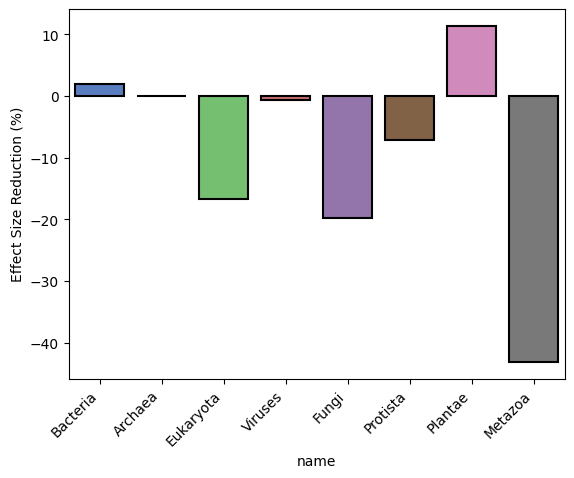

In [105]:
sns.barplot(data=effect_size_reduction.to_pandas(),
                x="name",
                y="effect_size_reduction",
                palette="muted",
                edgecolor="black",
                linewidth=1.5)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Effect Size Reduction (%)")

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_16976/535437701.py:8: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  data = comparison_df_avg.melt(


Bacteria -0.010031813000461137 TtestResult(statistic=np.float64(-0.7479841844435322), pvalue=np.float64(0.45447760837102535), df=np.float64(22234.0))
Eukaryota 0.25998079730462303 TtestResult(statistic=np.float64(3.1346525752185777), pvalue=np.float64(0.0018078743723987146), df=np.float64(578.0))
Archaea 0.0022409264951202975 TtestResult(statistic=np.float64(0.0364366793962886), pvalue=np.float64(0.9709410671091359), df=np.float64(1054.0))
Viruses 0.0025056289808482865 TtestResult(statistic=np.float64(0.3174679877308774), pvalue=np.float64(0.7508895584670069), df=np.float64(64210.0))


/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_16976/535437701.py:80: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  annotator = Annotator(ax, pairs, data=comparison_df_avg.melt(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Archaea_fold_enrichment vs. Archaea_fold_enrichment_corrected: t-test independent samples with Benjamini-Hochberg correction, P_val:9.709e-01 t=3.644e-02
Eukaryota_fold_enrichment vs. Eukaryota_fold_enrichment_corrected: t-test independent samples with Benjamini-Hochberg correction, P_val:1.808e-03 t=3.135e+00
Bacteria_fold_enrichment vs. Bacteria_fold_enrichment_corrected: t-test independent samples with Benjamini-Hochberg correction, P_val:4.545e-01 t=-7.480e-01
Viruses_fold_enrichment vs. Viruses_fold_enrichment_corrected: t-test independent samples with Benjamini-Hochberg correction, P_val:7.509e-01 t=3.175e-01


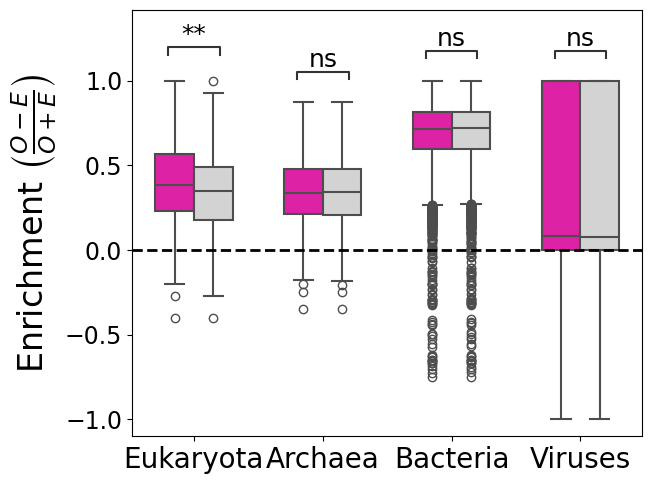

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from pathlib import Path
import numpy as np
from scipy.stats import ttest_ind

data = comparison_df_avg.melt(
        id_vars=["species_taxid", "partition", "domain"],
        value_vars=["fold_enrichment", "fold_enrichment_corrected"],
        value_name="enrichment"
    )


domains = ["Bacteria", "Eukaryota", "Archaea", "Viruses"]
for domain in domains:
    obs = comparison_df_avg.filter(pl.col("domain") == domain)[f"fold_enrichment"].to_pandas()
    ctrl = comparison_df_avg.filter(pl.col("domain") == domain)[f"fold_enrichment_corrected"].to_pandas()

    result = ttest_ind(obs, ctrl)
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)

    # pooled standard deviation
    pooled_denom = (n1 - 1) + (n2 - 1)
    if pooled_denom > 0:
        s_pooled = np.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / pooled_denom)
    else:
        s_pooled = np.nan

    # Cohen's d
    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled if s_pooled and not np.isnan(s_pooled) else np.nan

    # Hedges' correction J
    df = n1 + n2 - 2
    J = 1.0 - (3.0 / (4.0 * df - 1.0)) if df > 0 else 1.0
    g = d * J if not np.isnan(d) else np.nan
    print(domain, g, result)

ax = sns.boxplot(
    data=data,
    x="domain",
    y="enrichment",
    hue="variable",
    palette=["#fc03b1", "lightgray"],
    width=0.6,
    linewidth=1.5,
    order=["Eukaryota", "Archaea", "Bacteria", "Viruses"],
    hue_order=["fold_enrichment", "fold_enrichment_corrected"]
)

plt.axhline(0, color='black', zorder=5, linestyle='--', linewidth=2)
plt.ylabel(r"$\text{Enrichment } \left( \frac{O - E}{O + E} \right)$", fontsize=20)
plt.xlabel("")
plt.tight_layout()
ax = plt.gca()
ax.yaxis.label.set_size(24)
ax.xaxis.label.set_size(30)
ax.tick_params(axis="both", labelsize=17)
ax.tick_params(axis="x", labelsize=20, zorder=0)
ax.legend(handles=[], frameon=False)

pairs = [
    ("Eukaryota", "fold_enrichment"),
    ("Eukaryota", "fold_enrichment_corrected"),
    ("Archaea", "fold_enrichment"),
    ("Archaea", "fold_enrichment_corrected"),
    ("Bacteria", "fold_enrichment"),
    ("Bacteria", "fold_enrichment_corrected"),
    ("Viruses", "fold_enrichment"),
    ("Viruses", "fold_enrichment_corrected")
]
pairs = [
    (("Eukaryota", "fold_enrichment"), ("Eukaryota", "fold_enrichment_corrected")),
    (("Archaea", "fold_enrichment"), ("Archaea", "fold_enrichment_corrected")),
    (("Bacteria", "fold_enrichment"), ("Bacteria", "fold_enrichment_corrected")),
    (("Viruses", "fold_enrichment"), ("Viruses", "fold_enrichment_corrected")),
]

annotator = Annotator(ax, pairs, data=comparison_df_avg.melt(
                id_vars=["species_taxid", "partition", "domain"],
                value_vars=["fold_enrichment", "fold_enrichment_corrected"],
                value_name="enrichment"
            ).to_pandas(), 
            x="domain", 
            y="enrichment", hue="variable", order=["Eukaryota", "Archaea", "Bacteria", "Viruses"],
hue_order=["fold_enrichment", "fold_enrichment_corrected"])

annotator.configure(test='t-test_ind', text_format='star', loc='inside', comparisons_correction='fdr_bh', fontsize=18, text_offset=-0.05)
annotator.apply_and_annotate()

target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
plt.savefig(f"{target}/fold_enrichment_{pattern}_all_domains.pdf", transparent=True, bbox_inches="tight")
plt.show()


In [57]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.io import export_svg
from scipy.stats import gaussian_kde
import numpy as np
from pathlib import Path

data_array = comparison_df_avg.filter(pl.col('partition') == '.')["fold_enrichment"].to_numpy()
kde = gaussian_kde(data_array)
x_kde = np.linspace(min(data_array), max(data_array), 500)
y_kde = kde(x_kde)
hist, edges = np.histogram(data_array, bins=30, density=True)

p = figure(
    width=600, 
    height=400, 
    title="",
    x_axis_label=f"{pattern} Enrichment",
    y_axis_label="Density",
    border_fill_color=None,
    toolbar_location=None,
    output_backend="svg"
)
hist_source = ColumnDataSource(data=dict(top=hist, left=edges[:-1], right=edges[1:]))
p.quad(
    top='top', bottom=0, left='left', right='right',
    source=hist_source,
    fill_color="dimgray",
    line_color="black", alpha=0.6
)

kde_source = ColumnDataSource(data=dict(x=x_kde, y=y_kde))
p.line(
    x='x', y='y',
    source=kde_source,
    line_color="dimgray",
    line_width=3,
    alpha=1.0
)
p.line(
    x=[0.0, 0.0],
    y=[0, max(max(hist), max(y_kde))],
    line_color="black",
    line_dash="dashed",
    line_width=5
)

# Styling
p.title.text_font_size = "22pt"
p.title.align = "center"
p.y_range.start = 0
p.xaxis.axis_label_text_font_size = "30pt"
p.yaxis.axis_label_text_font_size = "30pt"
p.xaxis.major_label_text_font_size = "24pt"
p.yaxis.major_label_text_font_size = "24pt"
p.outline_line_color = "black"
p.outline_line_width = 2
p.title.text_font_style = "normal"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_style = "normal"

target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True, parents=True)
export_svg(p, filename=target / f"domain_generic_hist.svg", webdriver=driver)
show(p)


In [59]:
from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource
from bokeh.io import export_svgs
from scipy.stats import gaussian_kde
import numpy as np
from pathlib import Path

domain_colors = {
                'Viruses': '#229ad6',
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#b2d8b2'
}
domain_colors.update({"Bacteria": "#8eb812"})
superkingdoms = comparison_df_avg.filter(pl.col("partition") == ".")['domain'].unique().to_list()
plots = []

for sk in superkingdoms:
    data = comparison_df.filter(pl.col("partition") == ".")\
                .filter(pl.col('domain') == sk)['fold_enrichment'].to_numpy()
    
    # KDE
    kde = gaussian_kde(data)
    x_kde = np.linspace(min(data), max(data), 500)
    y_kde = kde(x_kde)

    # Histogram as frequencies
    hist, edges = np.histogram(data, bins=30, density=True)

    p = figure(
        width=600, height=400, 
        title=sk,
        border_fill_color=None,
        x_axis_label="STR Enrichment",
        y_axis_label="Density",
        toolbar_location=None,
        output_backend="svg",
    )
    
    # Histogram
    p.quad(
        top=hist, bottom=0, left=edges[:-1], right=edges[1:],
        fill_color=domain_colors.get(sk, "gray"), line_color="black", alpha=0.6
    )

    # KDE Line
    p.line(x_kde, y_kde, 
           line_color=domain_colors.get(sk, "gray"), line_width=3, alpha=1.0,
    )

    p.line(x=[0.0, 0.0], y=[0, max(max(hist), max(y_kde))],
           line_color="black", line_dash="dashed", line_width=5)

    # Styling
    p.title.text_font_size = "26pt"
    p.title.align = "center"
    p.xaxis.axis_label_text_font_size = "30pt"
    p.yaxis.axis_label_text_font_size = "30pt"
    p.xaxis.major_label_text_font_size = "24pt"
    p.yaxis.major_label_text_font_size = "24pt"
    p.outline_line_color = "black"
    p.y_range.start = 0
    p.outline_line_width = 2
    p.title.text_font_style = "normal"
    p.xaxis.axis_label_text_font_style = "normal"
    p.yaxis.axis_label_text_font_style = "normal"
    plots.append(p)
# Save SVGs

for i, p in enumerate(plots):
    show(p)
    domain = superkingdoms[i]
    export_svgs(p, filename=target / f"domain_{domain}_histplot_enrichment_STR_shuffled.svg", webdriver=driver)

## Statistical Comparison

In [60]:
alpha = 0.025
quantiles_df = comparison_df_all.group_by(["domain"]).agg(
                                           pl.col(f"density_{pattern}").quantile(alpha/2).alias("lower_ci"),
                                           pl.col(f"density_{pattern}").quantile(1-alpha/2).alias("upper_ci"),
                                           pl.col(f"density_{pattern}_control").quantile(alpha/2).alias("lower_ci_control"),
                                           pl.col(f"density_{pattern}_control").quantile(1-alpha/2).alias("upper_ci_control")
                                           )
quantiles_df

domain,lower_ci,upper_ci,lower_ci_control,upper_ci_control
str,f64,f64,f64,f64
"""Eukaryota""",0.181,9.797,0.175,2.4105
"""Bacteria""",0.738,8.605667,0.166,1.808
"""Archaea""",0.249,4.453,0.136,1.488
"""Viruses""",0.0,18.235,0.0,2.959


In [61]:
import numpy as np
from scipy.stats import ttest_ind

cohen_d_list = dict()
t_test = dict()
domains = ["Bacteria", "Eukaryota", "Archaea", "Viruses"]
for domain in domains:
    obs = comparison_df_all.filter(pl.col("domain") == domain)[f"density_{pattern}"].to_pandas()
    ctrl = comparison_df_all.filter(pl.col("domain") == domain)[f"density_{pattern}_control"].to_pandas()
    result = ttest_ind(obs, ctrl)
    print(result)
    t_test[domain] = (result.statistic, result.pvalue)
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2)/(n1+n2-2))
    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled
    cohen_d_list[domain] = d
    
cohen_d_list

TtestResult(statistic=np.float64(137.48308558958155), pvalue=np.float64(0.0), df=np.float64(22234.0))
TtestResult(statistic=np.float64(6.063145306207804), pvalue=np.float64(2.4112882043346333e-09), df=np.float64(578.0))
TtestResult(statistic=np.float64(13.561345089821065), pvalue=np.float64(9.817007330133879e-39), df=np.float64(1054.0))
TtestResult(statistic=np.float64(58.852781565503584), pvalue=np.float64(0.0), df=np.float64(64210.0))


{'Bacteria': np.float64(1.8439576125231818),
 'Eukaryota': np.float64(0.5035168113769782),
 'Archaea': np.float64(0.8346430933956639),
 'Viruses': np.float64(0.4645033932647915)}

In [62]:
import numpy as np
from scipy.stats import ttest_ind

hedges_g_list = dict()
t_test = dict()
domains = ["Bacteria", "Eukaryota", "Archaea", "Viruses"]
for domain in domains:
    obs = comparison_df_all.filter(pl.col("domain") == domain)[f"density_{pattern}"].to_pandas()
    ctrl = comparison_df_all.filter(pl.col("domain") == domain)[f"density_{pattern}_control"].to_pandas()

    result = ttest_ind(obs, ctrl)
    t_test[domain] = (result.statistic, result.pvalue)
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)

    pooled_denom = (n1 - 1) + (n2 - 1)
    if pooled_denom > 0:
        s_pooled = np.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / pooled_denom)
    else:
        s_pooled = np.nan

    d = (np.mean(obs) - np.mean(ctrl)) / s_pooled if s_pooled and not np.isnan(s_pooled) else np.nan
    df = n1 + n2 - 2
    J = 1.0 - (3.0 / (4.0 * df - 1.0)) if df > 0 else 1.0
    g = d * J if not np.isnan(d) else np.nan

    hedges_g_list[domain] = g
hedges_g_list

{'Bacteria': np.float64(1.843895411220685),
 'Eukaryota': np.float64(0.5028631763989899),
 'Archaea': np.float64(0.8340490413718947),
 'Viruses': np.float64(0.46449796764726536)}

In [63]:
def map_stars(pval):
    if pval < 0.0001:
        return "*" * 4
    elif pval < 0.001:
        return "*" * 3
    elif pval < 0.01:
        return "*" * 2
    elif pval < 0.05:
        return "*"
    return ""

# Repeating Unit Comparison

In [64]:
def calculate_enrichment(row):
    o, e = None, None
    for key, value in row.items():
        if "control" in key:
            e = value
        else:
            o = value
    if o == e:
        return 0.0
    return (o-e)/(o+e)

comparison_df_general = (
            comparison_df.filter(pl.col("partition") == ".")
                .select([
                        "#assembly_accession", 
                        "species_taxid", 
                        "partition",
                        "organism_name", 
                        "domain", 
                        "phylum",
                        "kingdom",
                        "genome_size",
                        f"density_{pattern}", 
                        f"density_{pattern}_control", 
                        "total_bp",
                        "total_bp_control",
                        "fold_enrichment", 
                        "pvalue", 
                        "significance"
                    ])
)
comparison_df_general

#assembly_accession,species_taxid,partition,organism_name,domain,phylum,kingdom,genome_size,density_IR,density_IR_control,total_bp,total_bp_control,fold_enrichment,pvalue,significance
str,i64,str,str,str,str,str,i64,f64,f64,i64,i64,f64,f64,str
"""GCA_002637055.1""",28875,""".""","""Human rotavirus A""","""Viruses""","""Duplornaviricota""","""Orthornavirae""",17439,1.376,0.0,24,0,1.0,1.1827e-7,"""****"""
"""GCA_031311805.1""",2928988,""".""","""Wenzhou Rattus losea jeilongvi…","""Viruses""","""Negarnaviricota""","""Orthornavirae""",18077,0.0,0.0,0,0,0.0,1.0,"""ns"""
"""GCF_000441655.1""",813,""".""","""Chlamydia trachomatis RC-J/943""","""Bacteria""","""Chlamydiota""","""Pseudomonadati""",1038797,2.665,0.248,2768,258,0.829729,0.0,"""****"""
"""GCA_029720955.1""",562,""".""","""Escherichia coli""","""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",4847823,2.618,0.196,12690,952,0.860697,0.0,"""****"""
"""GCA_003129245.1""",12305,""".""","""Cucumber mosaic virus""","""Viruses""","""Kitrinoviricota""","""Orthornavirae""",8511,0.0,0.0,0,0,0.0,1.0,"""ns"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_003008555.2""",2605946,""".""","""Pukyongiella litopenaei""","""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",4262966,1.566,0.643,6675,2741,0.417836,0.0,"""****"""
"""GCF_016128055.1""",1254,""".""","""Pediococcus acidilactici""","""Bacteria""","""Bacillota""","""Bacillati""",2009583,2.342,0.233,4706,468,0.819029,0.0,"""****"""
"""GCA_902990965.1""",2100421,""".""","""uncultured Caudovirales phage""","""Viruses""","""Uroviricota""","""Heunggongvirae""",15402,0.0,3.181,0,49,-1.0,3.4194e-15,"""****"""


In [65]:
indir = Path("../data").resolve()
# comparison_df = pl.read_csv(indir / "group_comparison_STR_density_accessions.sru.csv.gz")
comparison_df_partition = comparison_df_avg.filter(pl.col("partition") != ".")
viral_kingdoms = set(comparison_df.filter(pl.col("domain") == "Viruses")["kingdom"])
comparison_df_partition = comparison_df.with_columns(kingdom_n=pl.col("kingdom").map_elements(lambda x: "Viruses" if x in viral_kingdoms else x, return_dtype=pl.Utf8))
comparison_df_partition

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment,odds,pvalue,significance,reduced_significance,kingdom_n
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64,f64,f64,str,str,str
"""GCA_002637055.1""",24,""".""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",1.376,17439,0,0.0,1.0,inf,1.1827e-7,"""****""","""*""","""Viruses"""
"""GCA_002637055.1""",0,"""0""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""1""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""2""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""3""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_903993005.2""",4448,"""4""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.787,5654862,174,0.031,0.924205,25.582555,0.0,"""****""","""*""","""Pseudomonadati"""
"""GCF_903993005.2""",2526,"""5""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.447,5654862,331,0.059,0.766798,7.634383,0.0,"""****""","""*""","""Pseudomonadati"""
"""GCF_903993005.2""",1696,"""6""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.3,5654862,160,0.028,0.829268,10.60288,0.0,"""****""","""*""","""Pseudomonadati"""


In [66]:
domains = ["Eukaryota", "Viruses", "Archaea", "Bacteria"]
comparison_df_partition_avg_list = []
comparison_df_avg_partition = comparison_df\
                                .group_by(["species_taxid", "partition"])\
                                .agg(
                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )

for domain in domains:
    comparison_df_sru_avg = calculate_average_density(comparison_df_avg_partition.filter(pl.col("partition") != ".",
                                                                           pl.col("domain") == domain), 
                                                      on="partition", 
                                                      value=f"density_{pattern}")
    comparison_df_sru_avg.loc[:, "domain"] = domain
    comparison_df_partition_avg_list.append(comparison_df_sru_avg)

comparison_df_partition_avg_list = pd.concat(comparison_df_partition_avg_list)
comparison_df_partition_avg_list

,partition,mean,upper_ci,lower_ci,domain
0,0,0.612697,0.925780,0.412689,Eukaryota
8,8,0.252418,0.395544,0.163201,Eukaryota
1,1,0.197458,0.256392,0.159733,Eukaryota
2,2,0.174834,0.240611,0.134224,Eukaryota
4,4,0.170363,0.196094,0.145505,Eukaryota
6,6,0.164608,0.190600,0.144492,Eukaryota
7,7,0.161665,0.191501,0.137183,Eukaryota
5,5,0.149504,0.171761,0.130203,Eukaryota
3,3,0.141666,0.160900,0.124032,Eukaryota
4,4,0.302334,0.321992,0.285131,Viruses


In [67]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Whisker, Legend, LegendItem
from bokeh.transform import dodge

sru_sorted = list(map(str, range(0, 9)))
# comparison_df_partition_avg_list = comparison_df_partition_avg_list.query("partition < 7")
comparison_df_partition_avg_list.loc[:, "partition"] = comparison_df_partition_avg_list["partition"].astype(str)
domain_colors = {
                'Viruses': '#229ad6',
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812'
}

bar_fig = figure(
    x_range=sru_sorted,
    height=600,
    width=800,
    border_fill_color=None,
    output_backend="svg",
    toolbar_location=None,
    tools=""
)

bar_width = 0.2
domains = ["Eukaryota", "Viruses", "Bacteria", "Archaea"]
num_domains = len(domains)
legend_items = []

for i, domain in enumerate(domains):
    color = domain_colors[domain]
    # Subset data for partition
    df_domain = comparison_df_partition_avg_list.query("domain == @domain")
    source = ColumnDataSource(df_domain)
    # Dodge offset for group position
    offset = -bar_width * (num_domains - 1) / 2 + i * bar_width
    # Add bars
    renderer = bar_fig.vbar(
        x=dodge("partition", offset, range=bar_fig.x_range),
        top="mean",
        width=bar_width,
        color=color,
        line_color="black",
        line_width=1.5,
        source=source,
        # legend_label=f""
    )
    # Optional: Add error bars
    whisker = Whisker(
        source=source,
        base=dodge("partition", offset, range=bar_fig.x_range),
        upper="upper_ci",
        lower="lower_ci",
        level="overlay"
    )
    whisker.upper_head.size = 10
    whisker.lower_head.size = 10
    whisker.line_width = 2
    bar_fig.add_layout(whisker)

# Styling
bar_fig.y_range.start = 0
bar_fig.y_range.end = comparison_df_partition_avg_list["upper_ci"].max() * 1.1
bar_fig.xgrid.grid_line_color = None
bar_fig.xaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.axis_label = f"{pattern} Density per kB"
bar_fig.xaxis.axis_label = "Spacer Length"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.axis_label_text_font_size = "22pt"
# bar_fig.legend.label_text_font_size = "12pt"
# bar_fig.legend.location = "top_left"
# bar_fig.legend.orientation = "vertical"
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.major_label_text_font_style = "normal"
bar_fig.yaxis.major_label_text_font_style = "normal"

show(bar_fig)
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
export_svgs(bar_fig, filename=target / f"{pattern}_density_domains_of_life.svg", webdriver=driver)

['/Users/nikolchantzi/biolab/tree_of_life_IR/notebooks/IR_figures/simulation/IR_density_domains_of_life.svg']

In [68]:
comparison_df["kingdom"].unique()
comparison_df_filtered = comparison_df.with_columns(
                    kingdom_n=pl.struct(["kingdom", "domain"]).map_elements(
                                lambda x: "Viruses" if x["domain"] == "Viruses" else x["kingdom"],
                                return_dtype=str
                    )
            ).filter(~pl.col("kingdom_n").is_null())
comparison_df_filtered

#assembly_accession,total_bp,partition,species_taxid,organism_name,genome_size,gc_percent,domain,phylum,kingdom,density_IR,genome_size_control,total_bp_control,density_IR_control,fold_enrichment,odds,pvalue,significance,reduced_significance,kingdom_n
str,i64,str,i64,str,i64,f64,str,str,str,f64,i64,i64,f64,f64,f64,f64,str,str,str
"""GCA_002637055.1""",24,""".""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",1.376,17439,0,0.0,1.0,inf,1.1827e-7,"""****""","""*""","""Viruses"""
"""GCA_002637055.1""",0,"""0""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""1""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""2""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
"""GCA_002637055.1""",0,"""3""",28875,"""Human rotavirus A""",17439,31.5,"""Viruses""","""Duplornaviricota""","""Orthornavirae""",0.0,17439,0,0.0,0.0,NaN,1.0,"""ns""","""ns""","""Viruses"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GCF_903993005.2""",4448,"""4""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.787,5654862,174,0.031,0.924205,25.582555,0.0,"""****""","""*""","""Pseudomonadati"""
"""GCF_903993005.2""",2526,"""5""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.447,5654862,331,0.059,0.766798,7.634383,0.0,"""****""","""*""","""Pseudomonadati"""
"""GCF_903993005.2""",1696,"""6""",573,"""Klebsiella pneumoniae""",5654862,57.0,"""Bacteria""","""Pseudomonadota""","""Pseudomonadati""",0.3,5654862,160,0.028,0.829268,10.60288,0.0,"""****""","""*""","""Pseudomonadati"""


In [69]:
from tqdm import tqdm

kingdoms = comparison_df_filtered["kingdom_n"].unique()
comparison_df_partition_avg_list = []
kingdom_to_domain = dict(zip(comparison_df_filtered["kingdom_n"], comparison_df_filtered["domain"]))
comparison_df_filtered = comparison_df_filtered.group_by(["species_taxid", "partition"])\
                                .agg(
                                    pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                    pl.col("domain").first().alias("domain"),
                                    pl.col("kingdom_n").first().alias("kingdom_n"),
                                    pl.col("kingdom").first().alias("kingdom"),
                                    pl.col("phylum").first().alias("phylum"),
                                    pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                    pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                )
for kingdom in tqdm(kingdoms):
    comparison_df_sru_avg = calculate_average_density(comparison_df_filtered.filter(pl.col("kingdom_n") == kingdom,
                                                                           pl.col("partition") != "."), 
                                                      on="partition", 
                                                      value=f"density_{pattern}")
    comparison_df_sru_avg.loc[:, "kingdom"] = kingdom
    comparison_df_sru_avg.loc[:, "domain"] = kingdom_to_domain[kingdom]
    comparison_df_partition_avg_list.append(comparison_df_sru_avg)

comparison_df_partition_avg_list = pd.concat(comparison_df_partition_avg_list)
comparison_df_partition_avg_list

100%|██████████| 13/13 [00:02<00:00,  6.48it/s]


,partition,mean,upper_ci,lower_ci,kingdom,domain
0,0,0.094600,0.135800,0.061400,Promethearchaeati,Archaea
4,4,0.088400,0.127200,0.061200,Promethearchaeati,Archaea
2,2,0.086600,0.110800,0.071800,Promethearchaeati,Archaea
1,1,0.082800,0.101000,0.067600,Promethearchaeati,Archaea
5,5,0.082600,0.097400,0.067200,Promethearchaeati,Archaea
...,...,...,...,...,...,...
3,3,0.282269,0.287799,0.277062,Pseudomonadati,Bacteria
1,1,0.264303,0.271131,0.257459,Pseudomonadati,Bacteria
7,7,0.244160,0.248311,0.240014,Pseudomonadati,Bacteria
0,0,0.239689,0.247001,0.233165,Pseudomonadati,Bacteria


In [70]:
kingdom_color_palette = {
                     'Viruses':'#229ad6',
                     'Bacteria': '#0fbf2d',
                     'Archaea': '#b2b2ff',
                     'Fungi': '#4d325e',
                     'Plantae': '#b50996',
                     'Eubacteria': '#0fbf2d',
                     'Metazoa': '#9bba2d',
                     'Protista': '#c78f5b',
                     'Thermoproteati': '#380e8c',
                      'Promethearchaeati': '#672fd6',
                      'Nanobdellati': '#8154eb',
                      'Methanobacteriati': '#1fc46a',
                      'Fusobacteriati': '#94cc2d',
                      'Pseudomonadati': '#b2d8b2',
                      'Bacillati': '#bbd61e',
                     'Thermotogati': '#7b7bed'
                     }

In [73]:
sru_sorted = list(map(str, range(0, 9)))
# comparison_df_partition_avg_list = comparison_df_partition_avg_list.query("partition < 7")
comparison_df_partition_avg_list.loc[:, "partition"] = comparison_df_partition_avg_list["partition"].astype(str)
bar_fig = figure(
    x_range=sru_sorted,
    height=600,
    width=900,
    border_fill_color=None,
    output_backend="svg",
    toolbar_location=None,
    tools=""
)
bar_width = 0.2
eukaryotic_kingdoms = comparison_df_partition_avg_list.query("domain == 'Eukaryota'")
kingdoms = eukaryotic_kingdoms["kingdom"].unique().tolist()
num_kingdoms = len(kingdoms)
legend_items = []

for i, kingdom in enumerate(kingdoms):
    color = kingdom_color_palette[kingdom]
    # Subset data for partition
    df_kingdom = eukaryotic_kingdoms.query("kingdom == @kingdom")
    source = ColumnDataSource(df_kingdom)
    # Dodge offset for group position
    offset = -bar_width * (num_kingdoms - 1) / 2 + i * bar_width
    renderer = bar_fig.vbar(
        x=dodge("partition", offset, range=bar_fig.x_range),
        top="mean",
        width=bar_width,
        color=color,
        line_color="black",
        line_width=1.5,
        source=source,
        # legend_label=f""
    )
    whisker = Whisker(
        source=source,
        base=dodge("partition", offset, range=bar_fig.x_range),
        upper="upper_ci",
        lower="lower_ci",
        level="overlay"
    )
    whisker.upper_head.size = 10
    whisker.lower_head.size = 10
    whisker.line_width = 1
    bar_fig.add_layout(whisker)

# Styling
bar_fig.y_range.start = 0
bar_fig.y_range.end = comparison_df_partition_avg_list["upper_ci"].max() * 1.1
bar_fig.xgrid.grid_line_color = None
bar_fig.yaxis.axis_label = f"{pattern} Density per kB"
bar_fig.xaxis.axis_label = "Spacer Length"
bar_fig.xaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.major_label_text_font_size = "18pt"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.axis_label_text_font_size = "22pt"
# bar_fig.legend.label_text_font_size = "12pt"
# bar_fig.legend.location = "top_left"
# bar_fig.legend.orientation = "vertical"
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.major_label_text_font_style = "normal"
bar_fig.yaxis.major_label_text_font_style = "normal"

show(bar_fig)
target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
export_svgs(bar_fig, filename=target / f"{pattern}_density_eukaryotic_kingdoms.svg", webdriver=driver)

['/Users/nikolchantzi/biolab/tree_of_life_IR/notebooks/IR_figures/simulation/IR_density_eukaryotic_kingdoms.svg']

In [74]:
comparison_df_melted  = comparison_df\
        .filter(pl.col("partition") == ".", ~pl.col("kingdom").is_null())\
        .group_by("species_taxid")\
        .agg(
            pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
            pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
            pl.col("kingdom").first().alias("kingdom"),
            pl.col("domain").first().alias("domain"),
            pl.col("phylum").first().alias("phylum"),
            pl.col("organism_name").first().alias("organism_name"),
            pl.col("gc_percent").mean().alias("gc_percent"),
            pl.col("partition").first().alias("partition"),
        )\
    .melt(
        id_vars=["species_taxid", "partition", "organism_name", "domain", "kingdom", "phylum", "gc_percent"],
        value_vars=[f"density_{pattern}", f"density_{pattern}_control"],
        variable_name=f"density_{pattern}"
    )\
        .with_columns(
            pl.col(f"density_{pattern}")
                            .replace(f"density_{pattern}", pattern)
                            .replace(f"density_{pattern}_control", "Control")
        )

order = (
        comparison_df_melted.filter(pl.col(f"density_{pattern}") == pattern)
                        .group_by("kingdom")
                        .agg(pl.col("value").mean().alias("density"))
                        .sort("density", descending=True).select("kingdom").to_series().to_list()
)
comparison_df_melted

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_16976/3748858782.py:14: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(


species_taxid,partition,organism_name,domain,kingdom,phylum,gc_percent,density_IR,value
i64,str,str,str,str,str,f64,str,f64
2954025,""".""","""Wolbachia endosymbiont (group …","""Bacteria""","""Pseudomonadati""","""Pseudomonadota""",35.0,"""IR""",1.682
2575344,""".""","""Flavobacterium phage FPSV-F7""","""Viruses""","""Heunggongvirae""","""Uroviricota""",32.0,"""IR""",6.822
2955487,""".""","""Plasmopara viticola lesion ass…","""Viruses""","""Orthornavirae""","""Lenarviricota""",51.5,"""IR""",0.0
2303750,""".""","""Stenotrophomonas sp. G4""","""Bacteria""","""Pseudomonadati""","""Pseudomonadota""",66.5,"""IR""",3.381
646637,""".""","""Streptomyces sp. M2""","""Bacteria""","""Bacillati""","""Actinomycetota""",70.5,"""IR""",2.83
…,…,…,…,…,…,…,…,…
2785439,""".""","""Streptomyces phage SscP1EGY""","""Viruses""","""Heunggongvirae""","""Uroviricota""",58.0,"""Control""",0.541
1168823,""".""","""environmental Halophage eHP-20""","""Viruses""","""Heunggongvirae""","""Uroviricota""",52.0,"""Control""",0.0
2698922,""".""","""Serratia phage KpHz_2""","""Viruses""","""Heunggongvirae""","""Uroviricota""",45.0,"""Control""",0.192


In [75]:
comparison_df_melted.group_by(["kingdom", f"density_{pattern}"]).agg(pl.col("value").mean()).filter(pl.col("kingdom") == "Fusobacteriati")

kingdom,density_IR,value
str,str,f64
"""Fusobacteriati""","""IR""",3.13165
"""Fusobacteriati""","""Control""",0.92627


## Phylum Level Comparison

In [76]:
from pathlib import Path
import pandas as pd
import polars as pl
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Whisker, LabelSet
from bokeh.transform import jitter

comparison_df_all = comparison_df_all.with_columns(
                kingdom_n=pl.struct(["kingdom", "domain"])
                        .map_elements(lambda x: "Bacteria" if x["domain"] == "Bacteria" else ("Archaea" if x["domain"] == "Archaea" else ("Viruses" if x["domain"] == "Viruses" else x["kingdom"])), 
                                      return_dtype=pl.Utf8)
)
phyla_all = comparison_df_all.filter(~pl.col("phylum").is_null())

valid_phyla = phyla_all.group_by("phylum").agg(
                            pl.col(f"density_{pattern}")
                                .count()
                                .alias("count")
                    )\
                    .filter(pl.col("count") >= 7)["phylum"].to_list()

phyla_all = phyla_all.filter(pl.col("phylum").is_in(valid_phyla))
print(f"Number of phyla with at least 7 species: {len(valid_phyla)}")

top_phyla_df = phyla_all.filter(pl.col("phylum").is_in(top_phyla)) 
bottom_phyla_df = phyla_all.filter(pl.col("phylum").is_in(bottom_phyla)) 
print(len(top_phyla_df), len(bottom_phyla_df))

top_phyla_df_avg = calculate_average_density(top_phyla_df, on="phylum", value=f"density_{pattern}")
top_phyla_df = top_phyla_df.with_columns(
    kingdom_nn=pl.struct(["kingdom_n", "domain"])
    .map_elements(lambda x: x["kingdom_n"] if x["domain"] == "Eukaryota" else x["domain"], return_dtype=str)
)
phylum_to_kingdom_color = dict(zip(top_phyla_df["phylum"], top_phyla_df["kingdom_nn"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
if isinstance(top_phyla_df_avg, pl.DataFrame):
    top_phyla_df_avg = top_phyla_df_avg.to_pandas()
top_phyla_df_avg["kingdom_color"] = top_phyla_df_avg["phylum"].map(phylum_to_kingdom_color)
top_phyla_df_avg = top_phyla_df_avg.sort_values(by=["mean"], ascending=True).reset_index(drop=True)
print(top_phyla_df_avg)

source_bars = ColumnDataSource(top_phyla_df_avg)
phylum_order = list(top_phyla_df_avg["phylum"])

source_scatter = ColumnDataSource(comparison_df_all)

Number of phyla with at least 7 species: 59
15234 24603
                         phylum      mean   upper_ci  lower_ci kingdom_color
0                   Chlorobiota  1.893176   2.057765  1.735293       #0fbf2d
1              Ignavibacteriota  1.970485   2.231165  1.680763       #0fbf2d
2                   Chlamydiota  1.985666   2.157088  1.794637       #0fbf2d
3                Armatimonadota  2.014036   3.109036  1.026184       #0fbf2d
4              Deferribacterota  2.066429   2.731014  1.504239       #0fbf2d
5   Candidatus Saccharimonadota  2.146389   2.552499  1.819196       #0fbf2d
6             Produgelaviricota  2.359833   3.250953  1.569773       #229ad6
7                   Chlorophyta  2.466750   3.648000  1.464617       #b50996
8              Bdellovibrionota  2.545592   2.942069  2.164950       #0fbf2d
9                 Chloroflexota  2.550343   2.825781  2.294465       #0fbf2d
10      Thermodesulfobacteriota  2.576922   2.769621  2.385923       #0fbf2d
11                 D

In [77]:
def calculate_enrichment(row):
    o = row[f"density_{pattern}"]
    e = row[f"density_{pattern}_control"]
    return (o-e)/(o+e) if o + e > 0 else 0.0 

comparison_df_all = comparison_df_all.with_columns(
    enrichment=pl.struct([f"density_{pattern}", 
                          f"density_{pattern}_control"]).map_elements(calculate_enrichment,
                                                                                            return_dtype=pl.Float64),
    classic_fe=pl.col(f"density_{pattern}") / pl.col(f"density_{pattern}_control")
)
comparison_df_all.head()

species_taxid,domain,kingdom,phylum,total_bp,total_bp_control,density_IR,density_IR_control,kingdom_n,enrichment,classic_fe
i64,str,str,str,i64,i64,f64,f64,str,f64,f64
2558695,"""Viruses""",null,null,161,0,11.81,0.0,"""Viruses""",1.0,inf
2843922,"""Viruses""","""Orthornavirae""","""Lenarviricota""",23,0,6.124,0.0,"""Viruses""",1.0,inf
480418,"""Bacteria""","""Bacillati""","""Actinomycetota""",7960,1001,2.433,0.306,"""Bacteria""",0.776561,7.95098
84159,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""",11540,2775,2.323,0.559,"""Bacteria""",0.612075,4.155635
2585038,"""Viruses""","""Shotokuvirae""","""Cressdnaviricota""",0,0,0.0,0.0,"""Viruses""",0.0,NaN


In [78]:

comparison_df_all.group_by("phylum").agg(pl.col("enrichment").count().alias("counts"), 
                                         pl.col("enrichment").mean()).filter(pl.col("enrichment") < 0)

phylum,counts,enrichment
str,u32,f64
"""Candidatus Heimdallarchaeota""",2,-0.021273
"""Candidatus Nanohalarchaeota""",3,-0.016634
"""Promethearchaeota""",2,-0.110781
"""Candidatus Bathyarchaeota""",1,-0.09865
"""Microsporidia""",3,-0.256968


In [79]:
comparison_phylum_avg_enrichment = ( 
    comparison_df_all.group_by("phylum").agg(
        pl.col("kingdom").first().alias("kingdom"), 
        pl.col("enrichment").quantile(0.2).alias("lower_ci"),
        pl.col("enrichment").quantile(0.8).alias("upper_ci"),
        pl.col("enrichment").mean().alias("mean"),
        pl.col("enrichment").count().alias("counts"),
        pl.col("domain").first().alias("domain")
        )
        .sort("mean", descending=True)
)
comparison_phylum_avg_enrichment 

if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

phylum_stat_assessed = phylum_stat_assessed.filter(~pl.col("phylum").is_null())
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    kingdom_n=pl.struct(["kingdom", "domain"])
    .map_elements(lambda x: "Viruses" if x["domain"] == "Viruses" else (x["kingdom"] if (x["kingdom"] and x["domain"] == "Eukaryota") else x["domain"]), return_dtype=pl.Utf8)
)
phylum_to_kingdom_color = dict(zip(phylum_stat_assessed["phylum"], phylum_stat_assessed["kingdom_n"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    pl.col("kingdom_n").replace_strict(kingdom_color_palette).alias("kingdom_color")
)

In [80]:
from collections import defaultdict
from tqdm import tqdm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd
import polars as pl

from scipy.stats import mannwhitneyu

def bootstrap_cles_ci(obs, ctrl, n_boot=1000, alpha=0.05):
    obs = np.asarray(obs)
    ctrl = np.asarray(ctrl)
    n1, n2 = len(obs), len(ctrl)

    cles_samples = np.empty(n_boot)

    for i in range(n_boot):
        obs_b = np.random.choice(obs, size=n1, replace=True)
        ctrl_b = np.random.choice(ctrl, size=n2, replace=True)
        u, _ = mannwhitneyu(obs_b, ctrl_b, alternative="two-sided")
        cles_samples[i] = u / (n1 * n2)

    lower = np.percentile(cles_samples, 100 * alpha / 2)
    upper = np.percentile(cles_samples, 100 * (1 - alpha / 2))
    return lower, upper


phylum_stat_assessed = defaultdict(list)
phyla = (
    comparison_df_all
    .filter(~pl.col("phylum").is_null())
    .select("phylum")
    .unique()
    .to_series()
    .to_list()
)

for phylum in tqdm(phyla):
    df_p = comparison_df_all.filter(pl.col("phylum") == phylum)

    obs = df_p[f"density_{pattern}"].to_pandas().values
    ctrl = df_p[f"density_{pattern}_control"].to_pandas().values

    if len(obs) < 5 or len(ctrl) < 5:
        continue

    u_stat, p_val = mannwhitneyu(obs, ctrl, alternative="two-sided")
    n1, n2 = len(obs), len(ctrl)
    cles = u_stat / (n1 * n2)

    # Bootstrap CI
    # ci_low, ci_high = bootstrap_cles_ci(obs, ctrl)
    # hedges g
    n1, n2 = len(obs), len(ctrl)
    s1, s2 = np.std(obs, ddof=1), np.std(ctrl, ddof=1)
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    g = (np.mean(obs) - np.mean(ctrl)) / s_pooled
    correction = 1 - (3 / (4*(n1+n2)-9))
    g_corrected = g * correction

    phylum_stat_assessed["phylum"].append(phylum)
    phylum_stat_assessed["n_obs"].append(n1)
    phylum_stat_assessed["n_ctrl"].append(n2)
    phylum_stat_assessed["mean_obs"].append(np.mean(obs))
    phylum_stat_assessed["mean_ctrl"].append(np.mean(ctrl))
    phylum_stat_assessed["cles"].append(cles)
    phylum_stat_assessed["pvalue_raw"].append(p_val)
    phylum_stat_assessed["hedges_g"].append(g_corrected)
    # phylum_stat_assessed["ci_lower"].append(ci_low)
    # phylum_stat_assessed["ci_higher"].append(ci_high)

pvals = np.array(phylum_stat_assessed["pvalue_raw"])
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

phylum_stat_assessed["pvalue_fdr"] = pvals_fdr
phylum_stat_assessed["significant"] = reject
phylum_stat_assessed["pvalue_fdr_stars"] = [map_stars(p) for p in phylum_stat_assessed["pvalue_fdr"]]

phylum_stat_assessed = (
    pd.DataFrame(phylum_stat_assessed)
    .merge(
        mean_density_phyla[["phylum", "domain", "kingdom", "total_species"]],
        how="left",
        on="phylum"
    )
)

phylum_stat_assessed.to_csv(
    f"{target}/{pattern}_phylum_statistical_assessment.csv",
    index=False
)

pl.from_pandas(phylum_stat_assessed) \
  .sort("cles", descending=True) \
  .head(50) \
  .to_pandas()

100%|██████████| 128/128 [00:00<00:00, 2233.94it/s]


,phylum,n_obs,n_ctrl,mean_obs,mean_ctrl,cles,pvalue_raw,hedges_g,pvalue_fdr,significant,pvalue_fdr_stars,domain,kingdom,total_species
0,Fusobacteriota,36,36,3.131650,0.926270,1.000000,3.046341e-13,2.185995,6.407821e-13,True,****,Bacteria,Fusobacteriati,36
1,Nitrospirota,20,20,1.305408,0.290538,1.000000,6.795615e-08,4.687591,1.184379e-07,True,****,Bacteria,Pseudomonadati,20
2,Synergistota,15,15,3.618267,0.332633,1.000000,3.383339e-06,3.813286,5.031264e-06,True,****,Bacteria,Thermotogati,15
3,Elusimicrobiota,5,5,3.078100,0.662300,1.000000,7.936508e-03,1.646379,9.134471e-03,True,**,Bacteria,Pseudomonadati,5
4,Chlorobiota,17,17,1.893176,0.296059,1.000000,7.026615e-07,5.411186,1.099035e-06,True,****,Bacteria,Pseudomonadati,17
5,Euglenozoa,9,9,1.408222,0.341111,1.000000,4.122948e-04,2.568510,5.467388e-04,True,***,Eukaryota,Protista,9
6,Lentisphaerota,7,7,1.824886,0.385514,1.000000,2.140710e-03,2.928074,2.664965e-03,True,**,Bacteria,Pseudomonadati,7
7,Ignavibacteriota,7,7,1.970485,0.536000,1.000000,5.827506e-04,3.936420,7.563359e-04,True,***,Bacteria,Pseudomonadati,7
8,Chlamydiota,28,28,1.985666,0.333034,1.000000,1.404101e-10,4.539040,2.676568e-10,True,****,Bacteria,Pseudomonadati,28
9,Chordata,13,13,3.327577,0.499538,1.000000,1.649667e-05,1.459151,2.287038e-05,True,****,Eukaryota,Metazoa,13


In [81]:
comparison_phylum_avg_enrichment = ( 
    comparison_df_all.group_by("phylum").agg(
        pl.col("kingdom").first().alias("kingdom"), 
        pl.col("enrichment").quantile(0.2).alias("lower_ci"),
        pl.col("enrichment").quantile(0.8).alias("upper_ci"),
        pl.col("enrichment").mean().alias("mean"),
        pl.col("enrichment").count().alias("counts"),
        pl.col("domain").first().alias("domain")
        )
        .sort("mean", descending=True)
)

domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#8eb812',
                'Viruses': '#229ad6',
} 
kingdom_color_palette = {
                'Viruses': '#229ad6',
                "Bacteria": "#0fbf2d",
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Eubacteria": "#0fbf2d",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                "Archaeabacteria": "#7b7bed",
                } 

if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

phylum_stat_assessed = phylum_stat_assessed.filter(~pl.col("phylum").is_null())
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    kingdom_n=pl.struct(["kingdom", "domain"])
    .map_elements(lambda x: "Viruses" if x["domain"] == "Viruses" else (x["kingdom"] if (x["kingdom"] and x["domain"] == "Eukaryota") else x["domain"]), return_dtype=pl.Utf8)
)
phylum_to_kingdom_color = dict(zip(phylum_stat_assessed["phylum"], phylum_stat_assessed["kingdom_n"]))
phylum_to_kingdom_color = {p: kingdom_color_palette[c] for p, c in phylum_to_kingdom_color.items()}
phylum_stat_assessed = phylum_stat_assessed.with_columns(
    pl.col("kingdom_n").replace_strict(kingdom_color_palette).alias("kingdom_color")
)

## Mann-Whitney U Test Results Visualization

In [82]:
from bokeh.models import Whisker, LabelSet, Span

if isinstance(phylum_stat_assessed, pd.DataFrame):
    phylum_stat_assessed = pl.from_pandas(phylum_stat_assessed)

# phylum_stat_assessed = phylum_stat_assessed.with_columns(
#             pl.col("ci_lower").map_elements(lambda x: round(x, 2)).alias("ci_lower"),
#             pl.col("ci_higher").map_elements(lambda x: round(x, 2)).alias("ci_higher")
#         )\
phylum_stat_assessed = phylum_stat_assessed\
       .with_columns(
            # pl.struct(["ci_lower", "ci_higher"]).map_elements(lambda x: f"[{x['ci_lower']}, {x['ci_higher']}]", return_dtype=str)
            pl.col("pvalue_fdr_stars").alias("representation")
        ).sort(["hedges_g"])

phylum_stat_assessed = phylum_stat_assessed.with_columns(
    pl.when(pl.col("hedges_g") < 0.5)
    .then(20)   # below the bar if hedges_g < 1
    .otherwise(5)  # above the bar if hedges_g >= 1
    .alias("label_y_offset")
)

phylum_stat_assessed = phylum_stat_assessed.with_columns(
    pl.when(pl.col("hedges_g") < 0.5)
    .then(0.5)                   # place at 1 if bar < 1
    .otherwise(pl.col("hedges_g"))  # otherwise at bar end
    .alias("label_x_pos")
)
source = ColumnDataSource(phylum_stat_assessed)
# Figure
bar_fig = figure(
    y_range=list(phylum_stat_assessed['phylum']),
    height=2000,
    width=1200,
    output_backend="svg",
    toolbar_location=None,
    tools=""
)
bar_fig.border_fill_color = None
bar_fig.x_range.end = phylum_stat_assessed["hedges_g"].max() * 1.1

span = Span(location=0.5, line_width=5, line_dash='dashed', line_color='black', dimension='height')
bar_fig.add_layout(span)

bar_fig.hbar(
    y='phylum',
    right='hedges_g',
    height=0.7,
    line_color='black',
    line_width=1.8,
    color='kingdom_color',
    source=source
)


sig_labels = LabelSet(
    x='label_x_pos',
    y='phylum',
    text='representation',
    source=source,
    # x_offset='label_y_offset',
    x_offset=6,
    y_offset=-26,
    text_font_size="26pt",
    text_color="black",
    text_align="left",
)
bar_fig.add_layout(sig_labels)

# Axes and style
bar_fig.ygrid.grid_line_color = None
bar_fig.xaxis.axis_label = "Effect Size (g)"
bar_fig.ygrid.grid_line_color = None
bar_fig.x_range.start = 0
bar_fig.yaxis.axis_label = ""
bar_fig.xaxis.axis_label_text_font_style = "normal"
bar_fig.yaxis.axis_label_text_font_style = "normal"
bar_fig.xaxis.axis_label_text_font_size = "32pt"
bar_fig.yaxis.axis_label_text_font_size = "22pt"
bar_fig.xaxis.major_label_text_font_size = "26pt"
bar_fig.yaxis.major_label_text_font_size = "22pt"
bar_fig.title.text_font_size = '16pt'
bar_fig.title.align = 'center'

target = Path(f"{pattern}_figures/simulation").resolve()
target.mkdir(exist_ok=True)
export_svg(bar_fig, filename=f"{target}/phylum_{pattern}_hedges_g_with_mann_whitney_pval_FDR.svg", webdriver=driver)
show(bar_fig)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KernelDensity
from bokeh.plotting import figure, show
from bokeh.models import Span

phylum_order = (
    comparison_phylum_avg_enrichment
    .filter( # ((pl.col("counts") >= 7) | (pl.col("domain") == "Eukaryota") & (pl.col("counts") >= 4)), 
            ~pl.col("phylum").is_null())

    .sort("mean", descending=True).select("phylum").to_series().to_list()
)
# print(phylum_order)
# max_ = len(phylum_order) - 20

# phylum_data = comparison_df_all.filter(pl.col("phylum").is_in(phylum_order[:max_]))
effect_size_phyla = list(phylum_stat_assessed.sort("hedges_g")["phylum"])
phylum_data = comparison_df_all.filter(~pl.col("phylum").is_null(), 
                                       pl.col("phylum").is_in(effect_size_phyla))

p = figure(
    height=2000,
    width=900,
    toolbar_location=None,
    output_backend="svg",
    # y_range=phylum_order[:max_][::-1],
    y_range=effect_size_phyla,
    x_axis_label="",
    y_axis_label=""
)

def offset(category, data, scale=6):
    return list(zip([category] * len(data), scale * data))

bw = 3
for phylum in effect_size_phyla:
    phylum_df = phylum_data.filter(pl.col("phylum") == phylum).to_pandas()
    tavg = phylum_df["enrichment"].values * 1e2
    temps = np.linspace(tavg.min(), tavg.max(), 50)
    kde = KernelDensity(kernel="gaussian", bandwidth=bw).fit(tavg[:, np.newaxis])
    density = np.exp(kde.score_samples(temps[:, np.newaxis]))
    x1, x2 = offset(phylum, density), offset(phylum, -density)
    p.varea(y1=x1, y2=x2, x=temps, alpha=0.8, color="#E0E0E0")
    tavg_density = np.exp(kde.score_samples(tavg[:, np.newaxis]))
    jitter = (np.random.random(len(tavg)) * 2 - 1) * tavg_density
    # jitter = np.random.random(len(tavg)) * 0.1 * tavg_density
    p.scatter(y=offset(phylum, jitter), 
              x=phylum_df["enrichment"].values * 1e2, 
              size=3,
              alpha=0.3,
              color="black")
vlin = Span(location=0, dimension='height', line_color='crimson', line_dash='dashed', line_width=4)
p.add_layout(vlin)

# p.grid.grid_line_color = None
p.x_range.end = 100
p.x_range.start = -100
p.xgrid.visible = True
p.ygrid.visible = False
p.xaxis.axis_label = f"{pattern} Enrichment" + r"$$\left( 100\frac{O-E}{O+E} \right)$$"
p.yaxis.axis_label = ""
p.xaxis.axis_label_text_font_size = "22pt"
p.xaxis.axis_label_text_font_style = "normal"
p.yaxis.axis_label_text_font_size = "22pt"
p.xaxis.major_label_text_font_size = "26pt"
p.yaxis.major_label_text_font_size = "22pt"
p.title.text_font_size = '16pt'
p.title.align = 'center'
target = Path(f"{pattern}_figures/simulation").resolve()
export_svgs(p, filename=target / f"{pattern}_enrichment_across_top_phyla.svg", webdriver=driver)
show(p)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Nanobdellati_IR vs. Nanobdellati_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:2.221e-01 t=1.251e+00
Orthornavirae_IR vs. Orthornavirae_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:4.277e-118 t=2.333e+01
Fungi_IR vs. Fungi_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:2.625e-16 t=8.531e+00
Trapavirae_IR vs. Trapavirae_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:9.636e-03 t=2.719e+00
Loebvirae_IR vs. Loebvirae_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:1.029e-13 t=7.664e+00
Pseudomonadati_IR vs. Pseudomonadati_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:0.000e+00 t=1.000e+02
Heunggongvirae_IR vs. Heung

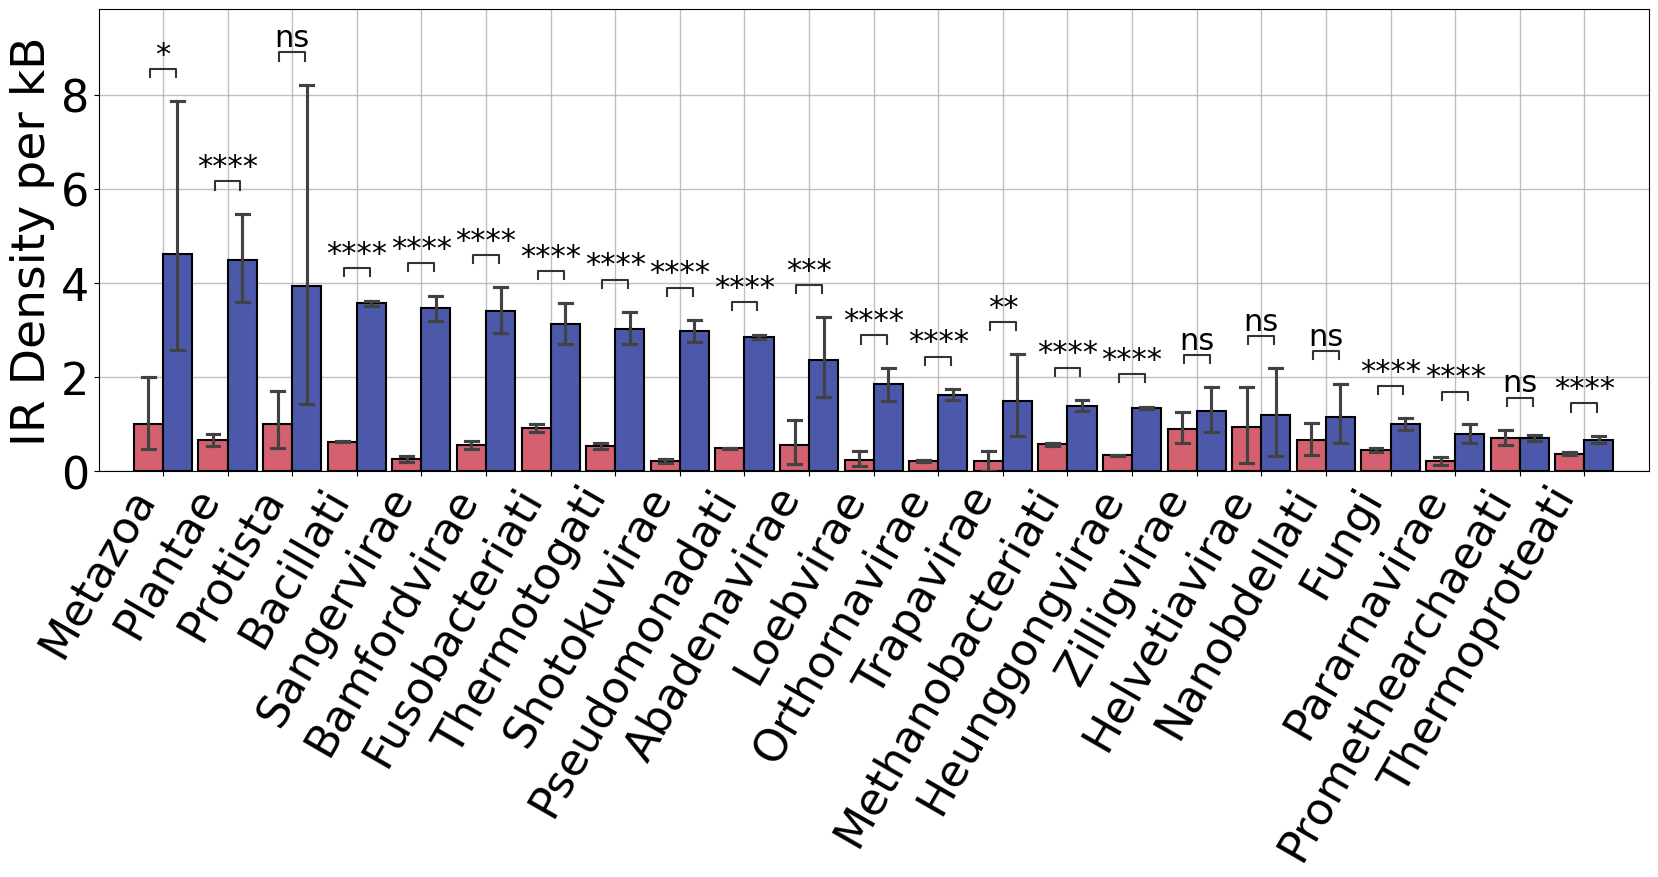

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patches as mpatches
from statannotations.Annotator import Annotator
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['ps.fonttype'] = 42

pattern = "IR"
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 6))
expected_color = "#e84d60"
observed_color = "#3c4cba"
palette = {
           "Control": expected_color,
           pattern: observed_color
          }

sns.barplot(data=comparison_df_melted.to_pandas(),
            x="kingdom",
            y="value",
            hue=f"density_{pattern}",
            palette=palette,
            width=0.9,
            linewidth=1.5,
            edgecolor="black",
            # showfliers=False,
            order=order,
            hue_order=["Control", pattern],
            ax=ax,
            capsize=0.4,
            # boxprops=dict(linewidth=2, edgecolor='black'),
            # medianprops=dict(color='crimson', linewidth=3), 
            # whiskerprops=dict(linewidth=2, color='gray'),
            # capprops=dict(linewidth=2, color='black'),
            # saturation=0.8,
            # flierprops=dict(marker='o', color='orange', markersize=5)
           )
ax.grid(lw=1.0, alpha=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=60, pad=2)
ax.set_xlabel('')
ax.set_ylabel(f"{pattern} Density per kB")
ax.yaxis.label.set_size(34)
ax.tick_params(axis="both", 
               labelsize=32, 
               zorder=0)
ax.tick_params(axis="x", labelsize=32, 
               zorder=0)
ax.legend(handles=[], frameon=False)
ranks = comparison_df_melted["kingdom"].unique()
pairs=[((q, "Control"), (q, pattern)) for q in ranks]

annotator = Annotator(ax, 
                      pairs, 
                      data=comparison_df_melted.to_pandas(), 
                      x="kingdom", 
                      hue=f"density_{pattern}",
                      y="value", 
                      order=order
                     )
annotator.configure(test='t-test_ind',  
                    comparisons_correction="fdr_bh",
                    text_format='star',
                    fontsize=22,
                    text_offset=-0.05,
                    loc='inside')
annotator.apply_and_annotate()
for tick in ax.get_xticklabels():
    tick.set_ha('right')
    # tick.set_x(tick.get_position()[0] - 0.006) 
x0, x1 = ax.get_xlim()
ax.set_xlim(x0 + 0.6, x1 - 0.6) 
fig.savefig(f"{target}/{pattern}_density_kingdom_vs_controls_boxplot.pdf", transparent=True, bbox_inches="tight")

In [84]:
comparison_df_melted  = comparison_df\
        .filter(pl.col("partition") != ".")\
        .group_by(["species_taxid", "partition"], maintain_order=True)\
        .agg(
            pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
            pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
            pl.col("kingdom").first().alias("kingdom"),
            pl.col("domain").first().alias("domain"),
            pl.col("phylum").first().alias("phylum"),
            pl.col("organism_name").first().alias("organism_name"),
            pl.col("gc_percent").mean().alias("gc_percent"),
        )\
    .melt(
        id_vars=["species_taxid", "partition", "organism_name", "domain", "kingdom", "phylum", "gc_percent"],
        value_vars=[f"density_{pattern}", f"density_{pattern}_control"],
        variable_name=f"density_{pattern}"
    )\
        .with_columns(
            pl.col(f"density_{pattern}")
            .replace(f"density_{pattern}", pattern)
            .replace(f"density_{pattern}_control", "Control")
        )\
        .with_columns(
            partition=pl.col("partition").cast(pl.Int16)
        )

comparison_df_melted["partition"].unique()

/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_16976/4165053796.py:13: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(


partition
i16
0
1
2
3
4
5
6
7
8


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

8_IR vs. 8_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:2.777e-24 t=1.042e+01
1_IR vs. 1_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:2.181e-24 t=1.045e+01
0_IR vs. 0_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:1.674e-25 t=1.072e+01
2_IR vs. 2_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:2.550e-18 t=8.892e+00
3_IR vs. 3_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:1.527e-25 t=1.073e+01
4_IR vs. 4_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:1.328e-29 t=1.165e+01
5_IR vs. 5_Control: t-test independent samples with Benjamini-Hochberg correction, P_val:6.331e-31 t=1.194e+01
6_IR vs. 6_Control: t-test inde

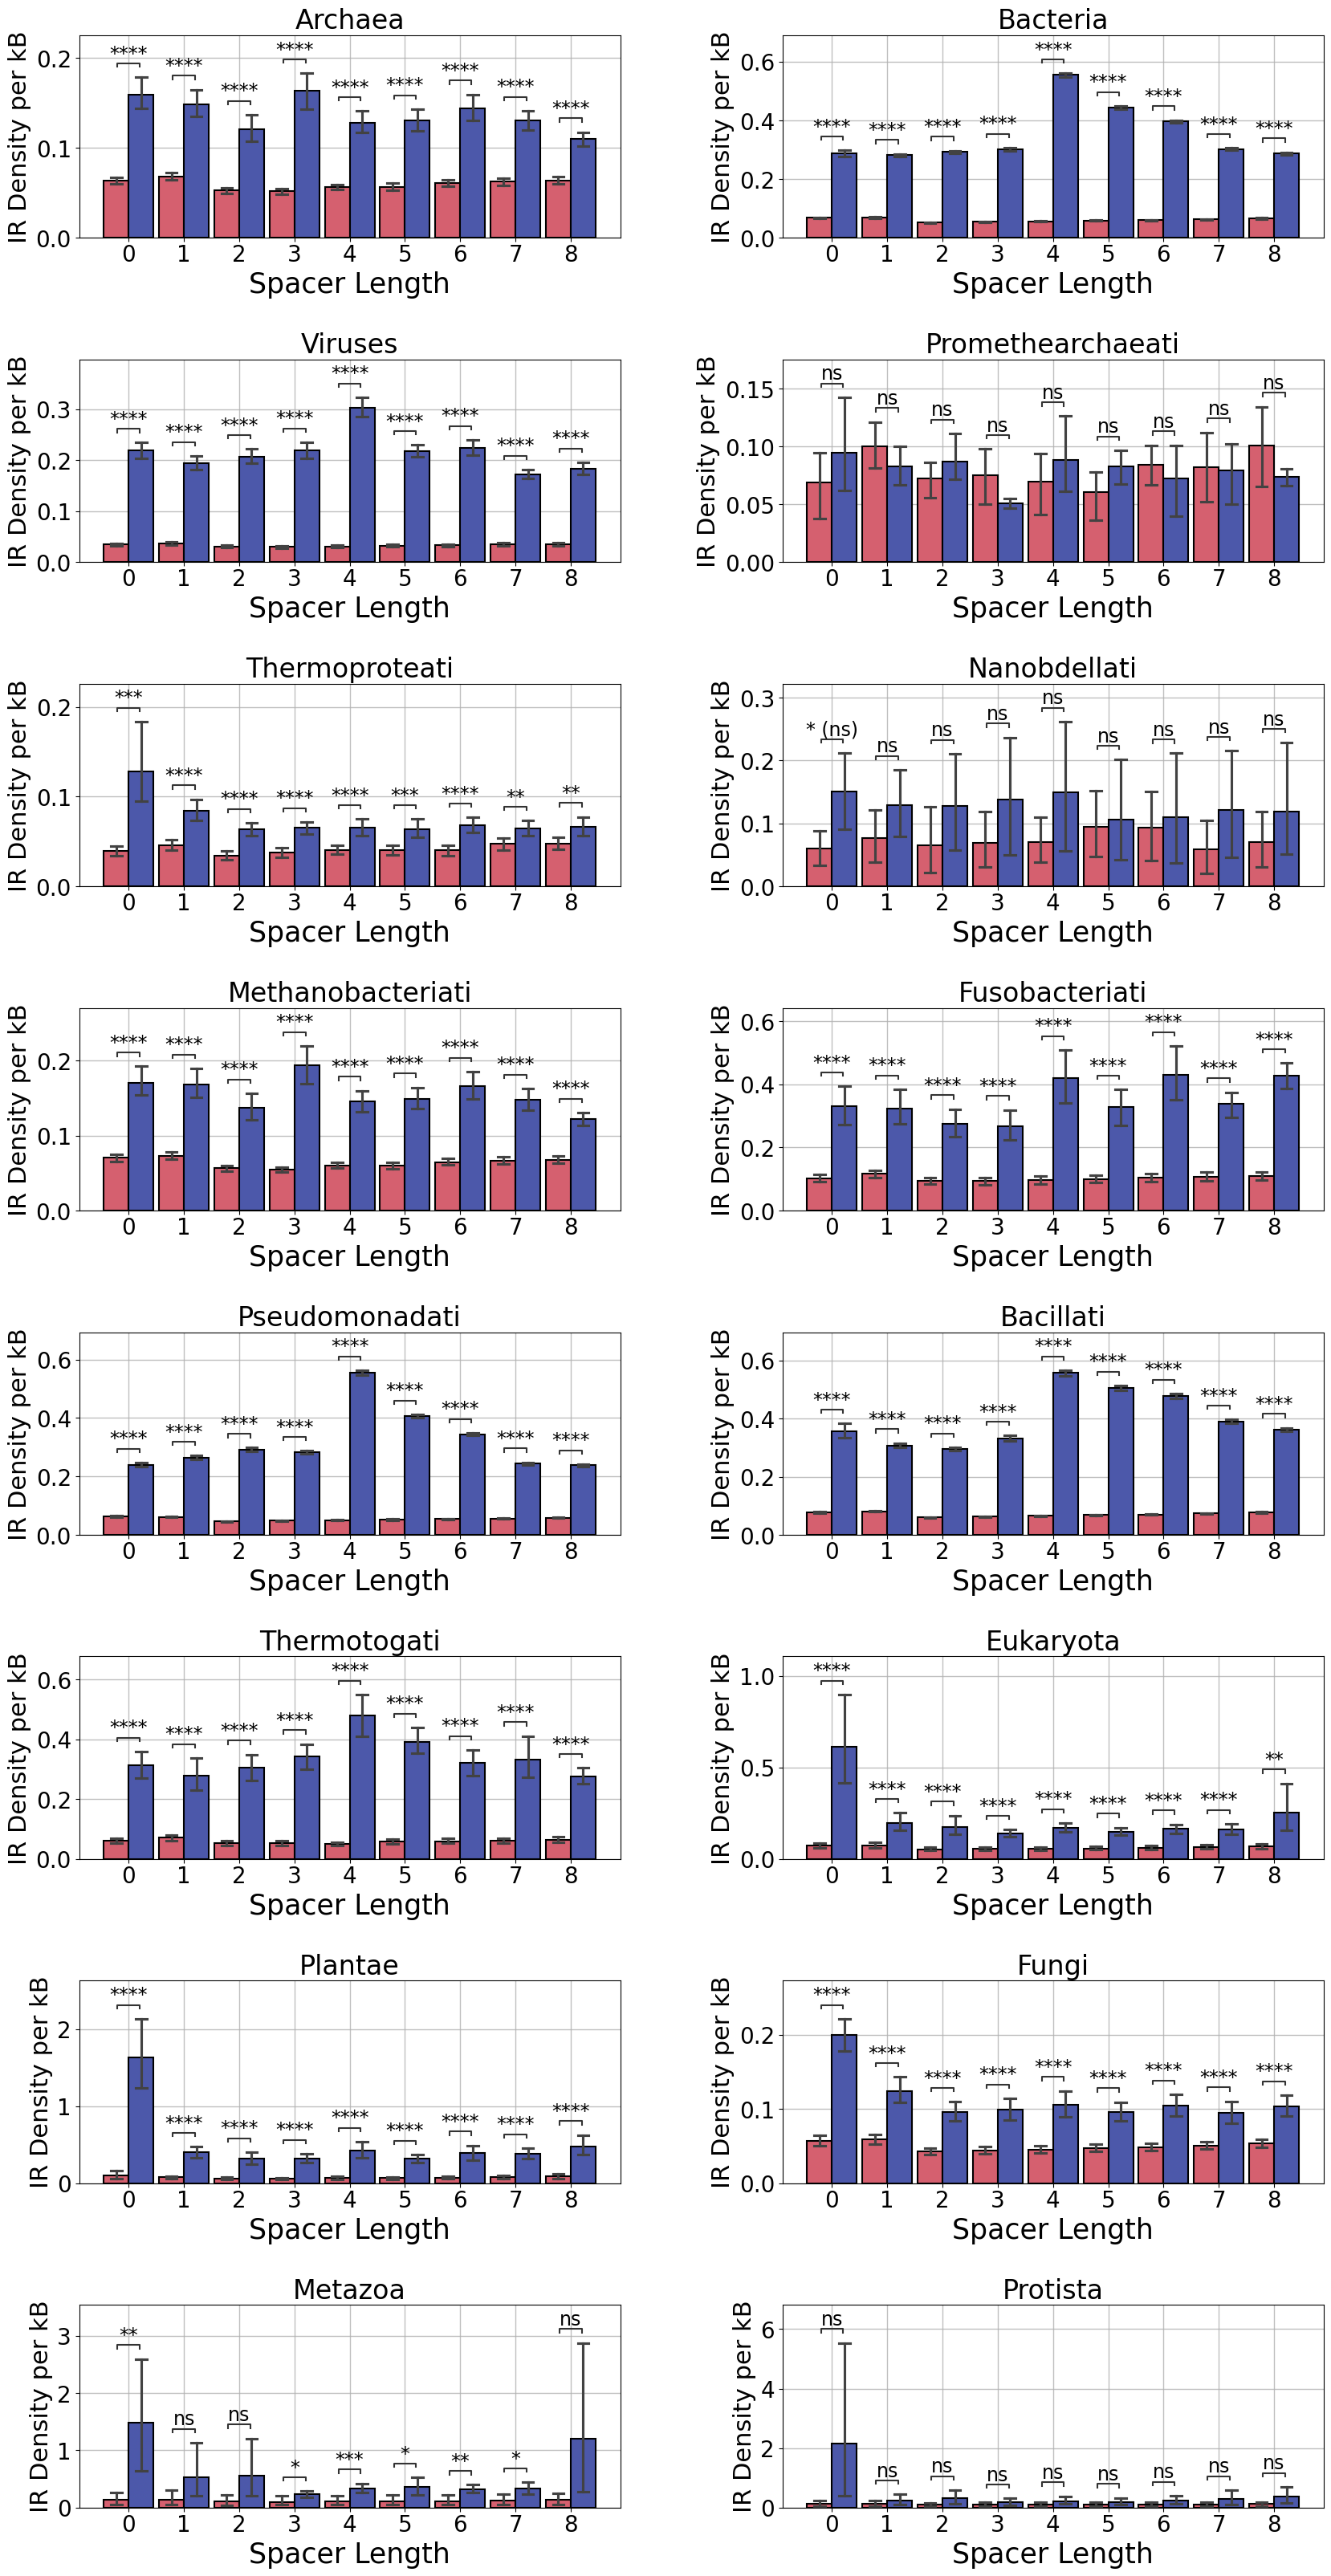

In [85]:
from statannotations.Annotator import Annotator

fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(20, 40))
axes = axes.flatten()
fig.subplots_adjust(hspace=0.6, wspace=0.3)
expected_color = "#e84d60"
observed_color = "#3c4cba"
palette = {
           "Control": expected_color,
           pattern: observed_color
          }

combinations = [("Archaea", "domain"),
                ("Bacteria", "domain"),
                ("Viruses", "domain"),
                ("Promethearchaeati", "kingdom"),
                ("Thermoproteati", "kingdom"),
                ("Nanobdellati", "kingdom"),
                ("Methanobacteriati", "kingdom"),
                ("Fusobacteriati", "kingdom"),
                ("Pseudomonadati", "kingdom"),
                ("Bacillati", "kingdom"),
                ("Thermotogati", "kingdom"),
                ("Eukaryota", "domain"),
                ("Plantae", "kingdom"),
                ("Fungi", "kingdom"),
                ("Metazoa", "kingdom"),
                ("Protista", "kingdom"),
                ]
for i, combination in enumerate(combinations):
    ax = axes[i]
    kingdom, ranking = combination 
    sns.barplot(data=comparison_df_melted.filter(pl.col(ranking) == kingdom).to_pandas(),
                x="partition",
                y="value",
                hue=f"density_{pattern}",
                # showfliers=False,
                palette=palette,
                width=0.9,
                linewidth=1.5,
                edgecolor="black",
                order=list(range(0, 9, 1)),
                hue_order=["Control", pattern],
                ax=ax,
                    # boxprops=dict(linewidth=2, edgecolor='black'),
                    # medianprops=dict(color='crimson', linewidth=3), 
                    # whiskerprops=dict(linewidth=2, color='gray'),
                    # capprops=dict(linewidth=2, color='black'),
                # saturation=0.8,
                    capsize=0.4,
                    # flierprops=dict(marker='o', color='orange', markersize=5)
               )
    ax.grid(lw=1.0, alpha=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=0, pad=2)
    ax.set_xlabel('Spacer Length')
    ax.xaxis.label.set_size(25)
    ax.set_ylabel(f"{pattern} Density per kB")
    ax.yaxis.label.set_size(22)
    ax.tick_params(axis="both", 
                   labelsize=20, 
                   zorder=0)
    # ax.legend(handles=[], frameon=False)
    ax.legend(frameon=True, fancybox=True, prop={"size": 16}, title="")
    ax.legend(handles=[], frameon=False)
    pairs=[((q, "Control"), (q, pattern)) for q in range(0, 9, 1)]

    ax.set_title(kingdom, fontsize=24)
    annotator = Annotator(ax, 
                          pairs, 
                          data=comparison_df_melted.filter(pl.col(ranking) == kingdom).to_pandas(), 
                          x="partition", 
                          hue=f"density_{pattern}",
                          y="value", 
                          order=list(range(0, 9, 1))
                         )
    annotator.configure(test='t-test_ind',
                        comparisons_correction="fdr_bh",
                        text_format='star',
                        fontsize=17,
                        text_offset=-0.05,
                        loc='inside')
    annotator.apply_and_annotate()
    # for tick in ax.get_xticklabels():
    #    tick.set_ha('right')
    #    tick.set_x(tick.get_position()[0] - 0.006) 
    # x0, x1 = ax.get_xlim()
    # ax.set_xlim(x0 + 0.6, x1 - 0.6) 
fig.savefig(f"{target}/{pattern}_density_kingdom_vs_controls_sru_comparison.pdf", transparent=True, pad_inches=0, bbox_inches="tight")

## Phylum Level Comparisons

In [86]:
from scipy.stats import ttest_ind
from collections import defaultdict 
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict
import numpy as np
from statsmodels.stats.multitest import multipletests

# Parameters
pattern = "IR"
partition_col = "partition"
stats = defaultdict(list)
phylums = comparison_df["phylum"]
N_iterations = 1000 
partition = range(0, 9, 1)

def assign_stars(pval: float) -> str:
    # if pval < 0.0001:
    #    return "****"
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

comparison_df_avged = comparison_df.group_by(["species_taxid", partition_col, "phylum"])\
                            .agg(
                                pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                                pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                                pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                                pl.col("domain").first().alias("domain"),
                                pl.col("kingdom").first().alias("kingdom"),
                            )

for phylum in tqdm(phylums.unique(), 
                   desc="Processing phylums", 
                   total=phylums.n_unique()):
    df = comparison_df_avged.filter(pl.col("phylum") == phylum).with_columns(partition_col=pl.col(partition_col).cast(pl.Utf8))
    for partitioning_element in partition:
        df_sru = df.filter(pl.col(partition_col) == str(partitioning_element))
        densities = list(df_sru.select([f"density_{pattern}"])[f"density_{pattern}"])
        densities_controls = list(df_sru.select([f"density_{pattern}_control"])[f"density_{pattern}_control"])
        group_A = densities
        group_B = densities_controls
        if len(group_A) < 2 or len(group_B) < 2:
            continue
        # group = group_A + group_B
        # observed_diff = np.mean(group_A) - np.mean(group_B)
        # mean_values = []
        # # permutations test 
        # group_array = np.array(group)
        # mean_values = [
        #     np.mean(np.random.permutation(group_array)[:len(group_A)]) -
        #     np.mean(np.random.permutation(group_array)[len(group_A):])
        #         for _ in range(N_iterations)
        # ]
        # # for _ in range(N_iterations):
        # #    np.random.shuffle(group)
        # #    group_A_perm = group[:len(group_A)]
        # #    group_B_perm = group[len(group_A):]
        # #    mean_values.append(np.mean(group_A_perm) - np.mean(group_B_perm))
        # pvalue_permutation = np.sum(np.abs(mean_values) >= np.abs(observed_diff)) / N_iterations

        stats["phylum"].append(phylum)
        stats[partition_col].append(partitioning_element)
        stats["counts"].append(df_sru.shape[0])
        stats["enrichment"].append(
            df_sru.select(pl.col("fold_enrichment")).to_numpy().mean()
        )
        # stats["pval_permutation"].append(pvalue_permutation)
        stats[f"density_{pattern}"].append(
            df_sru.select(pl.col(f"density_{pattern}")).to_numpy().mean()
        )
        stats[f"density_{pattern}_control"].append(
            df_sru.select(pl.col(f"density_{pattern}_control")).to_numpy().mean()
        )
        stats["pval"].append(
            mannwhitneyu(densities, densities_controls).pvalue
        )

stats_df = pl.DataFrame(stats)
# FDR correction
rejected, pvals_corrected, _, _ = multipletests(stats_df["pval"].to_numpy(), method='fdr_bh')
# rejected, pvals_corrected_permutation, _, _ = multipletests(stats_df["pval_permutation"].to_numpy(), method='fdr_bh')

Processing phylums:  47%|████▋     | 60/129 [00:00<00:00, 92.45it/s]/var/folders/k2/0c_5sk9n30x2t3srxrtbbp2c0000gr/T/ipykernel_16976/784601685.py:41: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  df = comparison_df_avged.filter(pl.col("phylum") == phylum).with_columns(partition_col=pl.col(partition_col).cast(pl.Utf8))
Processing phylums: 100%|██████████| 129/129 [00:01<00:00, 94.03it/s]


In [87]:
stats_df = stats_df.with_columns(pval_adjusted=pl.Series(pvals_corrected))
stats_df

phylum,partition,counts,enrichment,density_IR,density_IR_control,pval,pval_adjusted
str,i64,i64,f64,f64,f64,f64,f64
"""Rhodothermota""",0,5,0.343761,0.142375,0.067905,0.007937,0.01625
"""Rhodothermota""",1,5,0.162006,0.091295,0.06555,0.116074,0.186767
"""Rhodothermota""",2,5,0.229644,0.08723,0.04423,0.309524,0.393939
"""Rhodothermota""",3,5,0.152891,0.08265,0.050655,0.249153,0.378583
"""Rhodothermota""",4,5,0.317562,0.133025,0.05059,0.055556,0.099129
…,…,…,…,…,…,…,…
"""Taleaviricota""",4,30,-0.083333,0.066,0.143933,0.394899,0.457457
"""Taleaviricota""",5,30,0.028905,0.1488,0.082133,0.890538,0.929109
"""Taleaviricota""",6,30,-0.15,0.0,0.111433,0.011035,0.022172


In [88]:
stats_df.filter(pl.col("pval_adjusted").is_null())

phylum,partition,counts,enrichment,density_IR,density_IR_control,pval,pval_adjusted
str,i64,i64,f64,f64,f64,f64,f64


In [89]:
stats_df = stats_df.with_columns(
    pl.col("pval_adjusted").map_elements(assign_stars, return_dtype=pl.Utf8).alias("pval_adjusted_stars")
)
# stats_df = stats_df.sort("phylum").sort("partition")
stats_df

phylum,partition,counts,enrichment,density_IR,density_IR_control,pval,pval_adjusted,pval_adjusted_stars
str,i64,i64,f64,f64,f64,f64,f64,str
"""Rhodothermota""",0,5,0.343761,0.142375,0.067905,0.007937,0.01625,"""*"""
"""Rhodothermota""",1,5,0.162006,0.091295,0.06555,0.116074,0.186767,"""ns"""
"""Rhodothermota""",2,5,0.229644,0.08723,0.04423,0.309524,0.393939,"""ns"""
"""Rhodothermota""",3,5,0.152891,0.08265,0.050655,0.249153,0.378583,"""ns"""
"""Rhodothermota""",4,5,0.317562,0.133025,0.05059,0.055556,0.099129,"""ns"""
…,…,…,…,…,…,…,…,…
"""Taleaviricota""",4,30,-0.083333,0.066,0.143933,0.394899,0.457457,"""ns"""
"""Taleaviricota""",5,30,0.028905,0.1488,0.082133,0.890538,0.929109,"""ns"""
"""Taleaviricota""",6,30,-0.15,0.0,0.111433,0.011035,0.022172,"""*"""


In [90]:
stats_df["pval_adjusted_stars"].value_counts()

pval_adjusted_stars,count
str,u32
"""***""",344
"""**""",49
"""*""",42
"""ns""",384


In [91]:
MIN_COUNT_THRESHOLD =9
comparison_df_avg = comparison_df.filter(~pl.col("phylum").is_null())\
                    .group_by(["species_taxid", "partition"])\
                    .agg(
                        pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
                        pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
                        pl.col("domain").first().alias("domain"),
                        pl.col("kingdom").first().alias("kingdom"),
                        pl.col("phylum").first().alias("phylum"),
                        pl.col("fold_enrichment").mean().alias("fold_enrichment"),
                    ).group_by(["partition", "phylum"])\
    .agg(
         pl.col(f"density_{pattern}").mean().alias(f"density_{pattern}"),
         pl.col(f"density_{pattern}_control").mean().alias(f"density_{pattern}_control"),
         pl.col("domain").first().alias("domain"),
         pl.col("kingdom").first().alias("kingdom"),
         pl.col("fold_enrichment").mean().alias("fold_enrichment"),
         pl.col("fold_enrichment").count().alias("counts"),
         )\
        .filter(pl.col("counts") >= MIN_COUNT_THRESHOLD)\
        .sort(f"density_{pattern}", descending=True)\
        .pivot(
            index="phylum",
            on="partition",
            values="fold_enrichment",
            aggregate_function="mean"
        )\
        .select(["phylum"] + [str(partition) for partition in range(0, 9, 1)])
# \ #.filter(pl.col("partition") != ".").with_columns(partition=pl.col("partition").cast(pl.Int32)).sort(["partition"]) 
comparison_df_avg

phylum,0,1,2,3,4,5,6,7,8
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Apicomplexa""",0.616345,0.247692,0.339334,0.140595,0.269826,0.344458,0.332878,0.284461,0.382128
"""Mycoplasmatota""",0.55307,0.4958,0.55252,0.537533,0.643157,0.644929,0.633677,0.526822,0.525182
"""Nucleocytoviricota""",0.555261,0.4227,0.50363,0.4461,0.471803,0.534193,0.470795,0.500995,0.51989
"""Streptophyta""",0.90862,0.683812,0.692988,0.705313,0.72583,0.671712,0.696383,0.680338,0.723006
"""Lenarviricota""",0.048337,0.06938,0.066366,0.078533,0.098008,0.06728,0.037069,0.021433,0.022166
…,…,…,…,…,…,…,…,…,…
"""Thermoplasmatota""",0.408156,0.258437,0.421084,0.355567,0.439339,0.373831,0.380146,0.280701,0.352404
"""Basidiomycota""",0.470925,0.266419,0.182152,0.171023,0.159132,0.225243,0.219257,0.226586,0.214496
"""Duplornaviricota""",0.028134,0.020687,0.003562,0.01407,0.0124,0.014845,0.015677,0.019594,0.010211


In [92]:
stats_pivot_df = stats_df.pivot(on="partition", 
                                index="phylum", 
                                values="pval_adjusted_stars", 
                                aggregate_function="first"
                                ) #.select(["phylum"] + [str(partition) for partition in range(0, 9, 1)])
stats_pivot_df

phylum,0,1,2,3,4,5,6,7,8
str,str,str,str,str,str,str,str,str,str
"""Rhodothermota""","""*""","""ns""","""ns""","""ns""","""ns""","""*""","""*""","""ns""","""ns"""
"""Cossaviricota""","""***""","""***""","""ns""","""***""","""**""","""ns""","""ns""","""ns""","""ns"""
"""Candidatus Altimarinota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Microsporidia""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Chloroflexota""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***"""
…,…,…,…,…,…,…,…,…,…
"""Candidatus Peregrinibacteriota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""
"""Pisuviricota""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***""","""***"""
"""Fibrobacterota""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns""","""ns"""


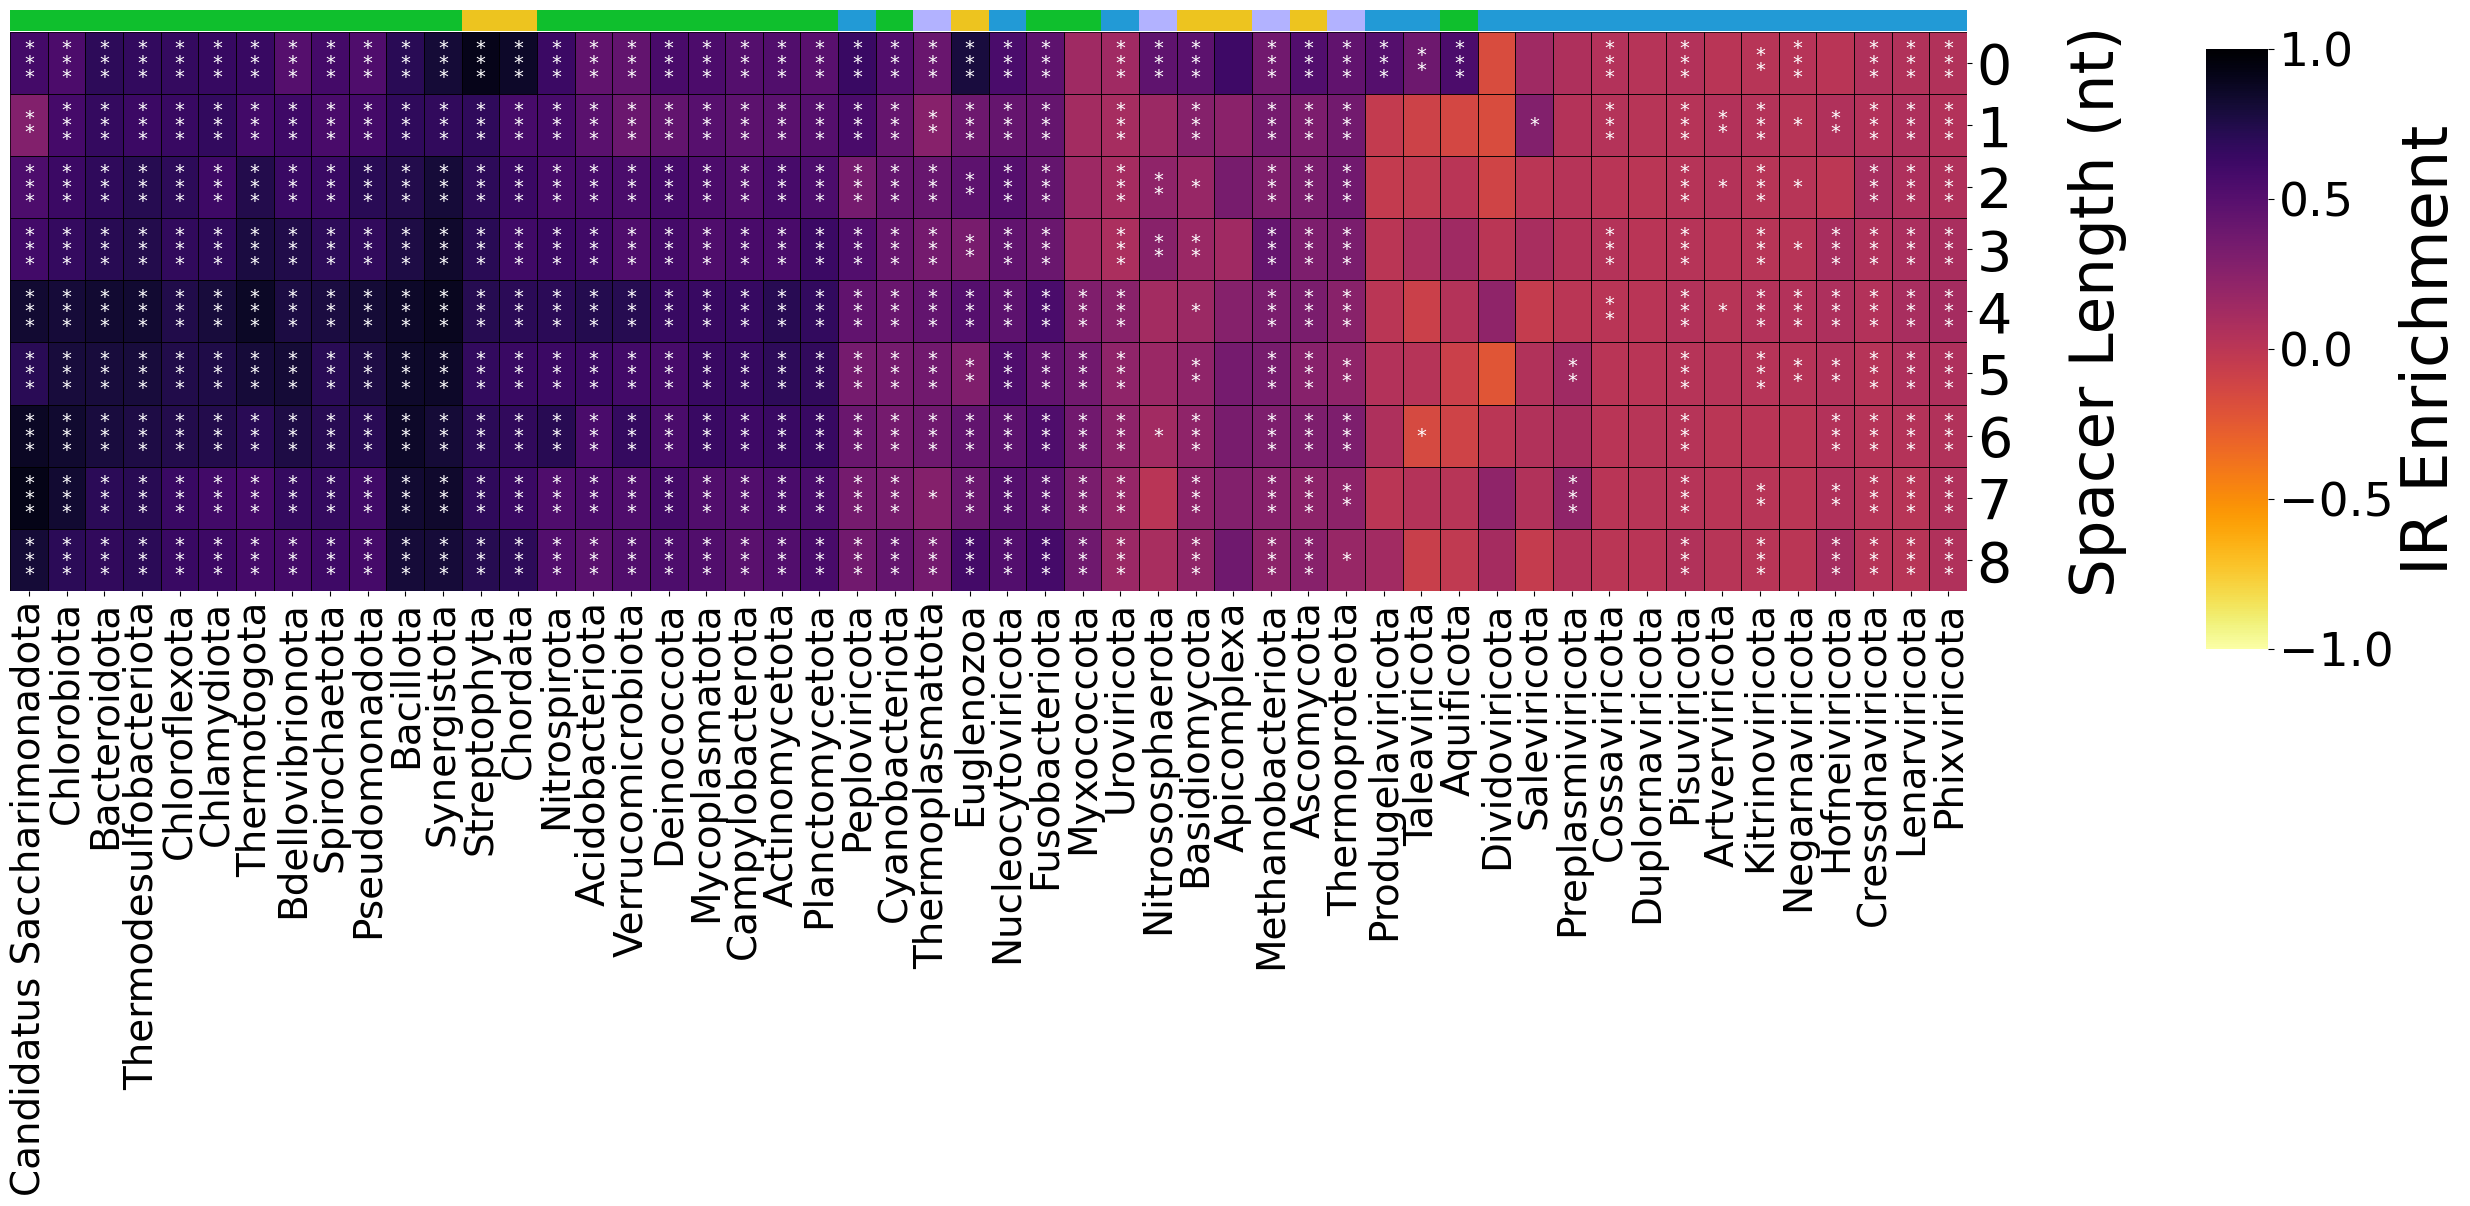

In [93]:
import matplotlib.patches as patches
kws = dict(cbar_kws=dict(location="top", shrink=0.2))
figsize=(15, 36)
kingdom_color_palette = {
                'Viruses': '#229ad6',
                "Bacteria": "#0fbf2d",
                "Archaea": "#b2b2ff",
                "Fungi": "#4d325e",
                "Plantae": "#b50996",
                "Eubacteria": "#0fbf2d",
                "Metazoa": "#9bba2d",
                "Protista": "#c78f5b",
                "Archaeabacteria": "#7b7bed",
                } 
domain_colors = {
                'Eukaryota': '#edc41f',
                'Archaea': '#b2b2ff',
                'Bacteria': '#0fbf2d',
                'Viruses': '#229ad6',
}

# kingdom_to_domain = dict(zip(comparison_df["kingdom"], comparison_df["domain"]))
phylum_to_domain = dict(zip(comparison_df["phylum"], comparison_df["domain"]))
phylum_to_kingdom= dict(zip(comparison_df["phylum"], comparison_df["kingdom"]))
# phylum_to_kingdom = {phylum: kingdom if kingdom_to_domain[kingdom] != "Viruses" else "Viruses" for phylum, kingdom in phylum_to_kingdom.items()}
domains = list(comparison_df_avg.with_columns(pl.col("phylum").replace_strict(phylum_to_domain).alias("domain"))["domain"])
# domains = [phylum_to_domain[col] for col in comparison_df_avg.columns if col != "partition"]
# kingdoms = list(comparison_df_avg.with_columns(pl.col("phylum").replace_strict(phylum_to_kingdom).alias("kingdom"))["kingdom"])
domain_colors = [domain_colors[domain] for domain in domains]

# kingdom_colors = [kingdom_color_palette[kingdom] for kingdom in kingdoms]
cg = sns.clustermap(
                  # comparison_df_avg.to_pandas().set_index("phylum"),
                  comparison_df_avg.to_pandas().set_index("phylum").T,
                   col_colors=[domain_colors], # kingdom_colors],
                   row_cluster=False, 
                   col_cluster=True,
                    method="ward",
                    figsize=(25, 10),
                    vmax=1.0,
                    center=0.0,
                    vmin=-1.0,
                    cmap="inferno_r",
                   robust=True,
                   yticklabels=True, 
                   xticklabels=True,
                   cbar_kws={"shrink": 0.1, 
                             "orientation": "vertical"}
                   )
ax = cg.ax_heatmap
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
ax = cg.ax_heatmap
ax.set_ylabel("")
t = ax.xaxis.get_majorticklocs()
ax.xaxis.label.set_size(52)
ax.yaxis.label.set_size(30)
ax.tick_params(axis="both", 
               which="major", 
               labelsize=38,
               rotation=0
              )
ax.tick_params(axis="x", 
               which="major", 
               labelsize=28,
               rotation=90
              )
ax.tick_params(axis="y", 
               which="major", 
               labelsize=40,
               rotation=0
              )

x0, _y0, _w, _h = cg.cbar_pos
cg.ax_cbar.set_position([1.08, 0.2, 0.025, 0.6])
cg.ax_cbar.tick_params(axis='both', length=4, labelsize=34)
cg.cax.set_ylabel(f'{pattern} Enrichment', size=46) #, labelpad=15, size=12)
for spine in cg.ax_cbar.spines:
    cg.ax_cbar.spines[spine].set_color('black')
    # cg.ax_cbar.spines[spine].set_linewidth(2)

ax.set_ylabel("Spacer Length (nt)", size=44, labelpad=40)
ax.set_xlabel("")
data = comparison_df_avg.to_pandas().loc[cg.dendrogram_col.reordered_ind].set_index("phylum")
n_rows, n_cols = data.T.shape
for i in range(n_rows):
    for j in range(n_cols):
        rect = patches.Rectangle((j, i), 1, 1, linewidth=0.5, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

stars_df = stats_pivot_df.to_pandas().set_index("phylum").loc[data.index, data.columns]  # reorder to match clustered heatmap
stats_df_temp = stats_df.to_pandas().set_index(["phylum", "partition"])["pval_adjusted_stars"]
for i, phylum in enumerate(data.index):
   for j, col in enumerate(data.columns):
       star = stats_df_temp.loc[phylum, int(col)]
       if star != "ns":
            vertical_star = "\n".join(star)   # "***" -> "*\n*\n*"

            ax.text(i + 0.5, j + 0.5, vertical_star,
                    ha='center', 
                    va='center',
                    fontsize=14, 
                    linespacing=0.7,
                    color='white')
fig = plt.gcf()
fig.savefig(target.joinpath(f"{pattern}_clustermap_enrichment_simie_phylum.pdf"), 
            transparent=True,
            bbox_inches='tight', 
            dpi=600)
plt.show()